# Bias Analysis: What Surface Features Drive the Period Classifier?

**Context**: A 1-layer MLP trained on TF-IDF char n-grams achieved 99.3% accuracy at classifying OB / NA / LB periods — a clear FAIL on the Pre-Track A bias check.  
This notebook investigates *why* — mapping the specific features driving trivial separability so we can decide how to clean/report the bias.

**Sections**:
1. Setup & data overview
2. Metadata leaks (corpus source, fragment IDs, place discovery)
3. Text length distributions
4. Top discriminative char n-grams (from fitted TF-IDF vectorizer)
5. Diacritic & special character frequencies
6. Number suffix conventions (sign2 / sign3 reading markers)
7. Vocabulary & token overlap across periods
8. Fragment ID series patterns
9. Summary: ranked bias sources

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
import re
import scipy.sparse as sp
from collections import Counter
from pathlib import Path
from sklearn.model_selection import train_test_split

# ── Paths ────────────────────────────────────────────────────────────────────
REPO_ROOT = Path("../../..")  # adjust if running from a different location
DATA_DIR  = REPO_ROOT / "v_1/data/evaluation"
PARQUET   = DATA_DIR / "corpora/texts_for_evaluation.parquet"
FEAT_DIR  = DATA_DIR / "bias_check/features"
PLOT_DIR  = DATA_DIR / "bias_check/plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# ── Plot style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
})
PERIOD_COLORS = {
    "Old Babylonian":  "#2196F3",
    "Neo-Assyrian":    "#9C27B0",
    "Late Babylonian": "#F44336",
}
PERIODS = list(PERIOD_COLORS.keys())
SHORT   = {"Old Babylonian": "OB", "Neo-Assyrian": "NA", "Late Babylonian": "LB"}

print("Imports OK")

Imports OK


## 1. Setup & Data Overview

In [2]:
# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_parquet(PARQUET)
print(f"Total rows: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print()

# Recreate the same train/val/test split used in the bias check
# (stratified, random_state=42, 70/15/15)
train_val, test = train_test_split(df, test_size=0.15, stratify=df["period"], random_state=42)
train, val      = train_test_split(train_val, test_size=0.15/0.85, stratify=train_val["period"], random_state=42)

print("Split sizes:")
for name, split in [("train", train), ("val", val), ("test", test)]:
    print(f"  {name}: {len(split)} rows")
    print("  ", split["period"].value_counts().to_dict())

print()
print("All columns:")
df.dtypes

Total rows: 4957
Columns: ['fragment_id', 'full_text', 'word_count', 'line_count', 'char_count', 'temporal_group', 'period', 'domain_standard', 'domain_finegrained', 'place_discovery', 'corpus_source']

Split sizes:
  train: 3469 rows
   {'Neo-Assyrian': 1705, 'Old Babylonian': 1047, 'Late Babylonian': 717}
  val: 744 rows
   {'Neo-Assyrian': 365, 'Old Babylonian': 225, 'Late Babylonian': 154}
  test: 744 rows
   {'Neo-Assyrian': 365, 'Old Babylonian': 225, 'Late Babylonian': 154}

All columns:


fragment_id           object
full_text             object
word_count             int64
line_count             int64
char_count             int64
temporal_group        object
period                object
domain_standard       object
domain_finegrained    object
place_discovery       object
corpus_source         object
dtype: object

In [3]:
# Quick sample of one text per period
for p in PERIODS:
    sample = df[df.period == p].iloc[0]
    print(f"{'='*60}")
    print(f"Period: {p}  |  corpus: {sample.corpus_source}  |  id: {sample.fragment_id}")
    print(sample.full_text[:300])
    print()

Period: Old Babylonian  |  corpus: archibab  |  id: ARM 10 33
a-na be-li2 u3 ka-ka-bi
a-nu-um-ma I-ia-ri-im-d-da-gan
ka-la-šu a-na be-li2
bu-ub
u2 a-na-ku
ar LUGAL
at-ta ma-an-nu
u2 GEME2 mu-uš-ke-ni-im
a-wa-tim
tim ik-ta-ru na-pa2-aš-ti
bi li-iš-pu-ra-am-ma
qi2-bi2-ma
ma-ri-ki li-it-ru-ni-in-ni
ib-bi E2-ta-am
ta-am u2-ul ha-aš-ha-ku
ma a-ia-ši lu ba-al-ṭa3-ta

Period: Neo-Assyrian  |  corpus: oracc  |  id: P224378
ARAD-ka
lu2-um-man-ni LUGAL iq-ta-ba-aš2-šu2 um-ma
LUGAL-u2-tu e-pu-uš LUGAL il-tap-raš-šu2
LUGAL iš-pur-an-ni
ša2 ul-tu
en-na
UR2
ina URU
a-na di-na-an LUGAL be-li2-ia lul-lik
um-ma-a a-na LUGAL be-li2-ia-a-ma
a-na LUGAL be-li2-ia2 al-tap-ra
um-ma mi-nam-ma ep-pu-uš
ša2 a-na LUGAL aq-bu-u2 um-ma d-

Period: Late Babylonian  |  corpus: lbl  |  id: 79.B.32
IM I-d-AG-NIG2-DU-URU3
u4-mu IM ta-mu-ru
nu-bat-ti la ta-ba-a-tu2
tug2-mu-ṣip-pe-e-ti
tug2-šir-a-am-me
ṣu-up-pe-e-tu2
tug2-šir-a-am-me
šu-pa-le-e-tu2
u3 tug2-SAGŠU-me
la-pa-ni lu2-GAL-meš iš-kar-me
hi-i-ṭu u i-šam-ma
a-na I

## 2. Metadata Leaks

Columns other than `full_text` that could trivially encode period — if these patterns bleed into the text itself, even a char n-gram classifier sees them.

In [4]:
# ── 2a. corpus_source ─────────────────────────────────────────────────────────
print("=== corpus_source × period ===")
ct = pd.crosstab(df["period"], df["corpus_source"])
print(ct)
print()
print("Each period comes from EXACTLY ONE corpus source. This is the primary bias vector.")
print("Different corpora use different transliteration conventions that the char n-gram model exploits.")

=== corpus_source × period ===
corpus_source    archibab   lbl  oracc
period                                
Late Babylonian         0  1025      0
Neo-Assyrian            0     0   2435
Old Babylonian       1497     0      0

Each period comes from EXACTLY ONE corpus source. This is the primary bias vector.
Different corpora use different transliteration conventions that the char n-gram model exploits.


In [5]:
# ── 2b. temporal_group ────────────────────────────────────────────────────────
print("=== temporal_group × period ===")
print(pd.crosstab(df["period"], df["temporal_group"]))
print()
print("temporal_group is a perfect proxy for period — never use it as a feature.")

=== temporal_group × period ===
temporal_group   Group 1  Group 2  Group 3
period                                    
Late Babylonian        0        0     1025
Neo-Assyrian           0     2435        0
Old Babylonian      1497        0        0

temporal_group is a perfect proxy for period — never use it as a feature.


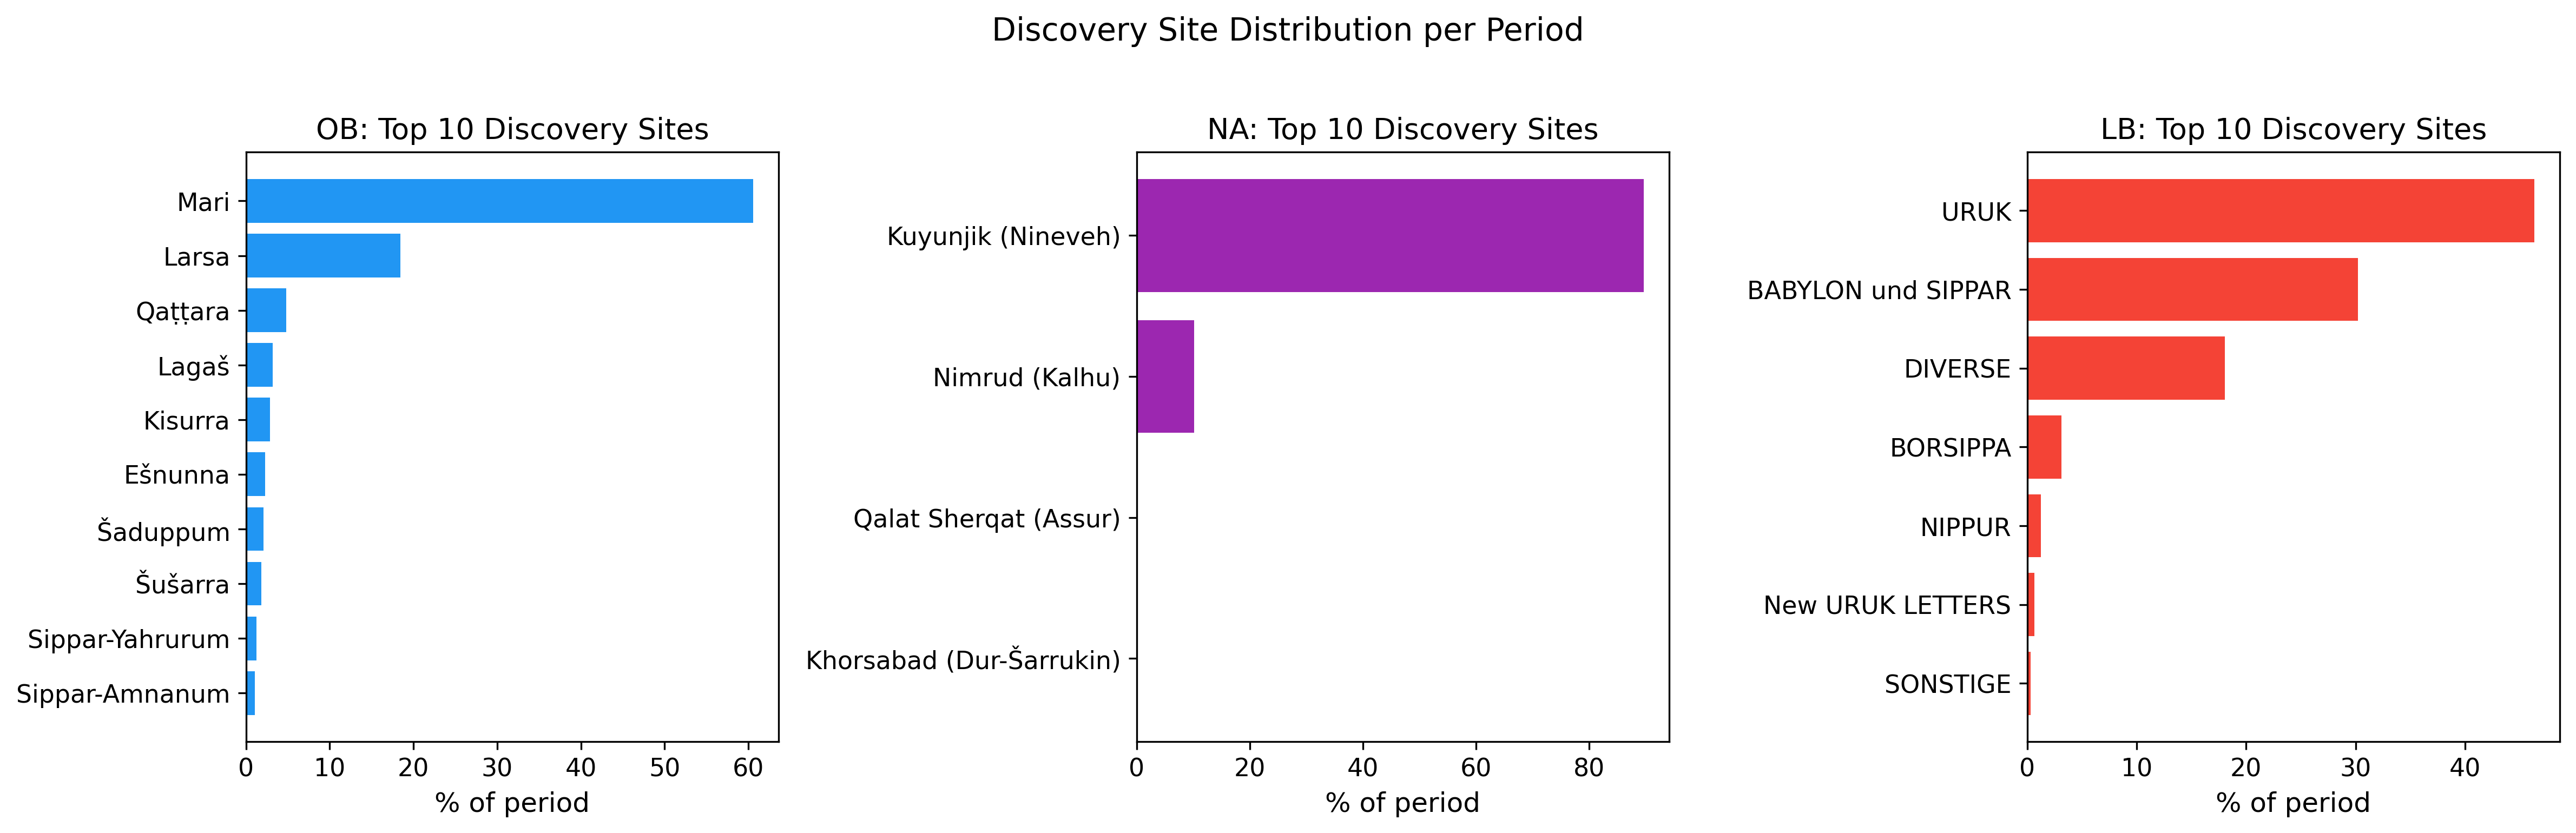

Note: sites are completely period-exclusive (no OB site has NA texts, etc.)


In [6]:
# ── 2c. place_discovery ───────────────────────────────────────────────────────
place_period = df.groupby(["period", "place_discovery"]).size().reset_index(name="count")
place_period["pct_of_period"] = place_period.groupby("period")["count"].transform(lambda x: x / x.sum() * 100)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, p in zip(axes, PERIODS):
    sub = place_period[place_period.period == p].nlargest(10, "count")
    ax.barh(sub["place_discovery"], sub["pct_of_period"], color=PERIOD_COLORS[p])
    ax.set_title(f"{SHORT[p]}: Top 10 Discovery Sites")
    ax.set_xlabel("% of period")
    ax.invert_yaxis()

plt.suptitle("Discovery Site Distribution per Period", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(PLOT_DIR / "bias_place_discovery.png", bbox_inches="tight", dpi=300)
plt.show()
print("Note: sites are completely period-exclusive (no OB site has NA texts, etc.)")

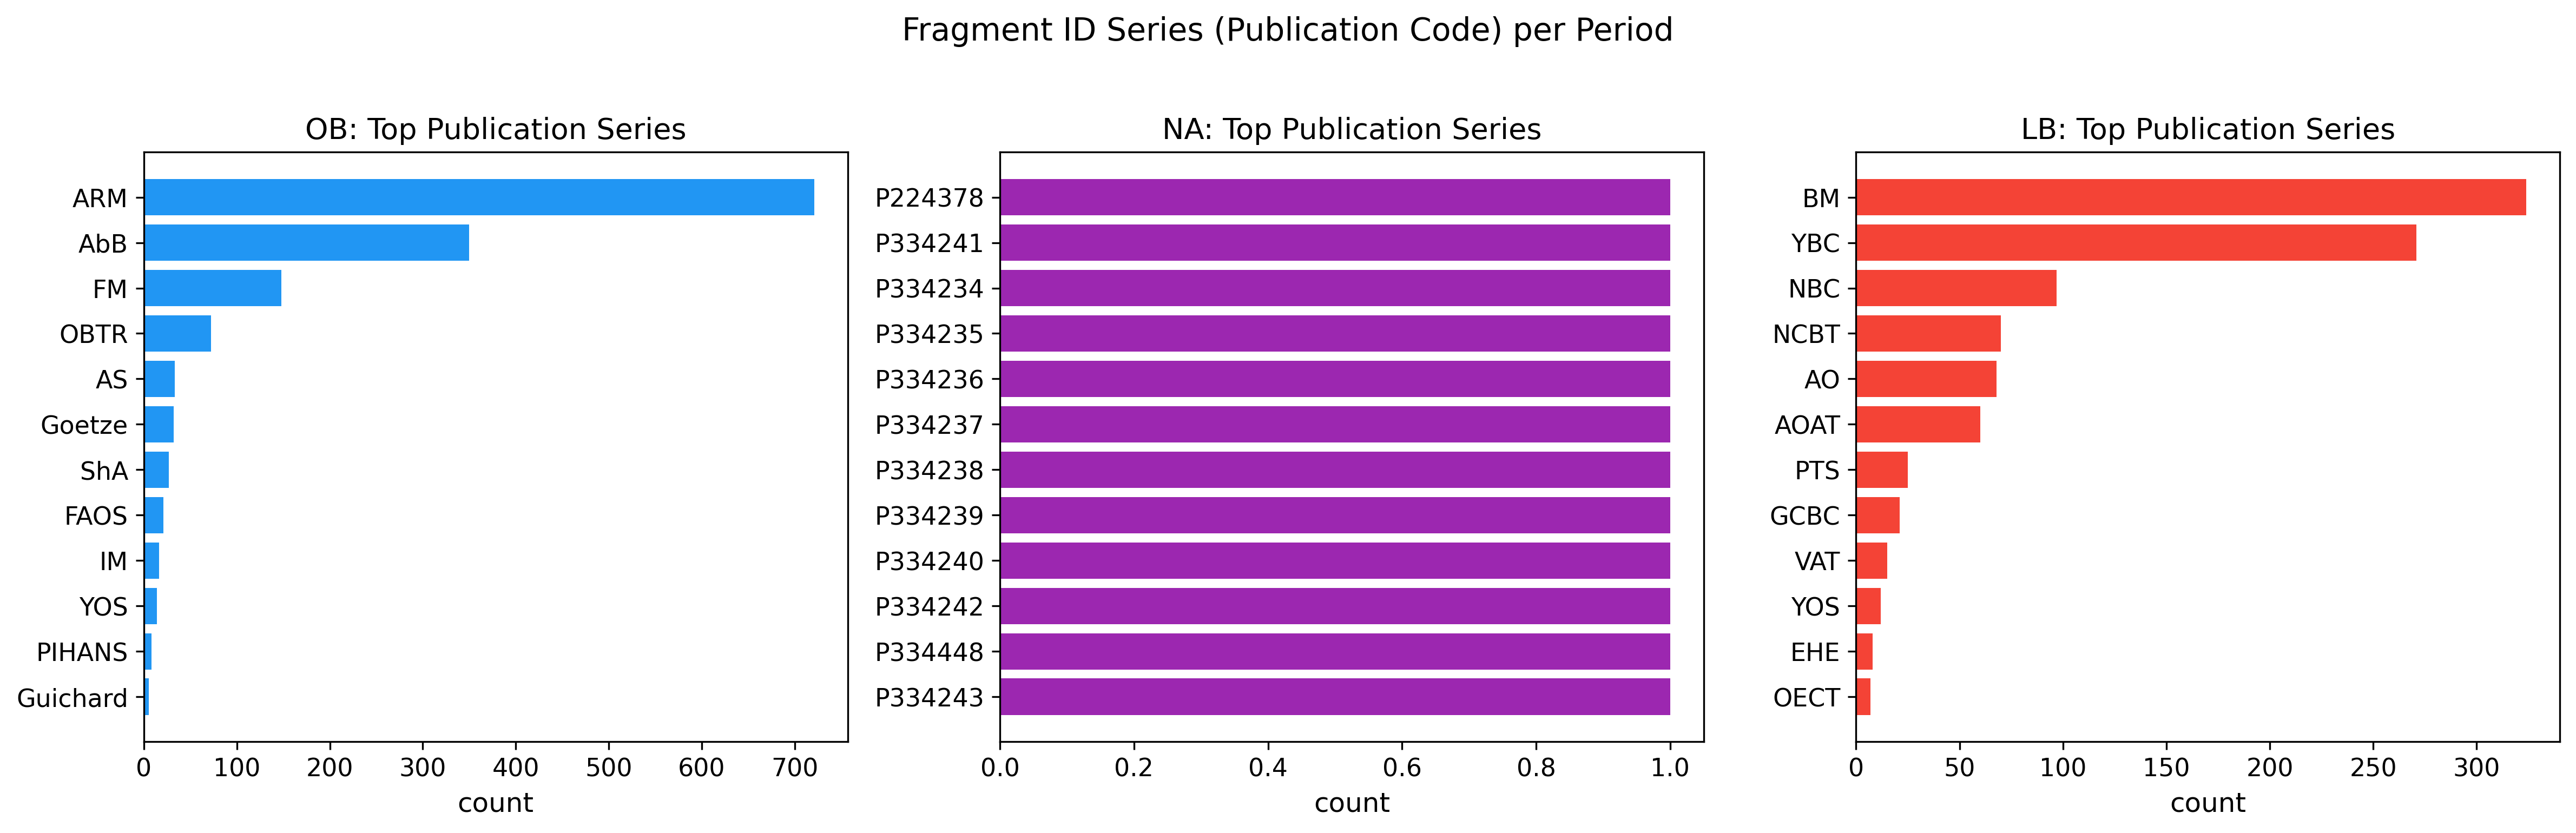

ARM, AbB, FM = OB. Every series maps to a single period.


In [7]:
# ── 2d. fragment_id prefix patterns ───────────────────────────────────────────
df["id_series"] = df["fragment_id"].str.split().str[0]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, p in zip(axes, PERIODS):
    sub = df[df.period == p]["id_series"].value_counts().head(12)
    ax.barh(sub.index, sub.values, color=PERIOD_COLORS[p])
    ax.set_title(f"{SHORT[p]}: Top Publication Series")
    ax.set_xlabel("count")
    ax.invert_yaxis()

plt.suptitle("Fragment ID Series (Publication Code) per Period", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(PLOT_DIR / "bias_fragment_series.png", bbox_inches="tight", dpi=300)
plt.show()
print("ARM, AbB, FM = OB. Every series maps to a single period.")

## 3. Text Length Distributions

In [8]:
# Compute length features
df["n_chars"]  = df["full_text"].str.len()
df["n_words"]  = df["full_text"].str.split().str.len()
df["n_lines"]  = df["full_text"].str.count("\n") + 1
df["avg_word_len"] = df["n_chars"] / df["n_words"].clip(lower=1)

print("Length stats per period:")
print(df.groupby("period")[["n_chars", "n_words", "n_lines", "avg_word_len"]].describe().round(1).to_string())

Length stats per period:
                n_chars                                                  n_words                                           n_lines                                           avg_word_len                                    
                  count   mean    std   min    25%    50%    75%     max   count  mean   std  min   25%   50%   75%    max   count  mean   std  min   25%   50%   75%    max        count mean  std  min  25%  50%  75%   max
period                                                                                                                                                                                                                       
Late Babylonian  1025.0  469.5  269.8   8.0  278.0  414.0  588.0  2476.0  1025.0  61.1  34.9  1.0  36.0  53.0  76.0  304.0  1025.0  21.8   9.3  1.0  14.0  21.0  28.0   52.0       1025.0  7.7  0.7  5.8  7.3  7.7  8.1  11.0
Neo-Assyrian     2435.0  441.6  428.5   6.0  168.5  313.0  582.5  5226.0  2435.0  56.0 

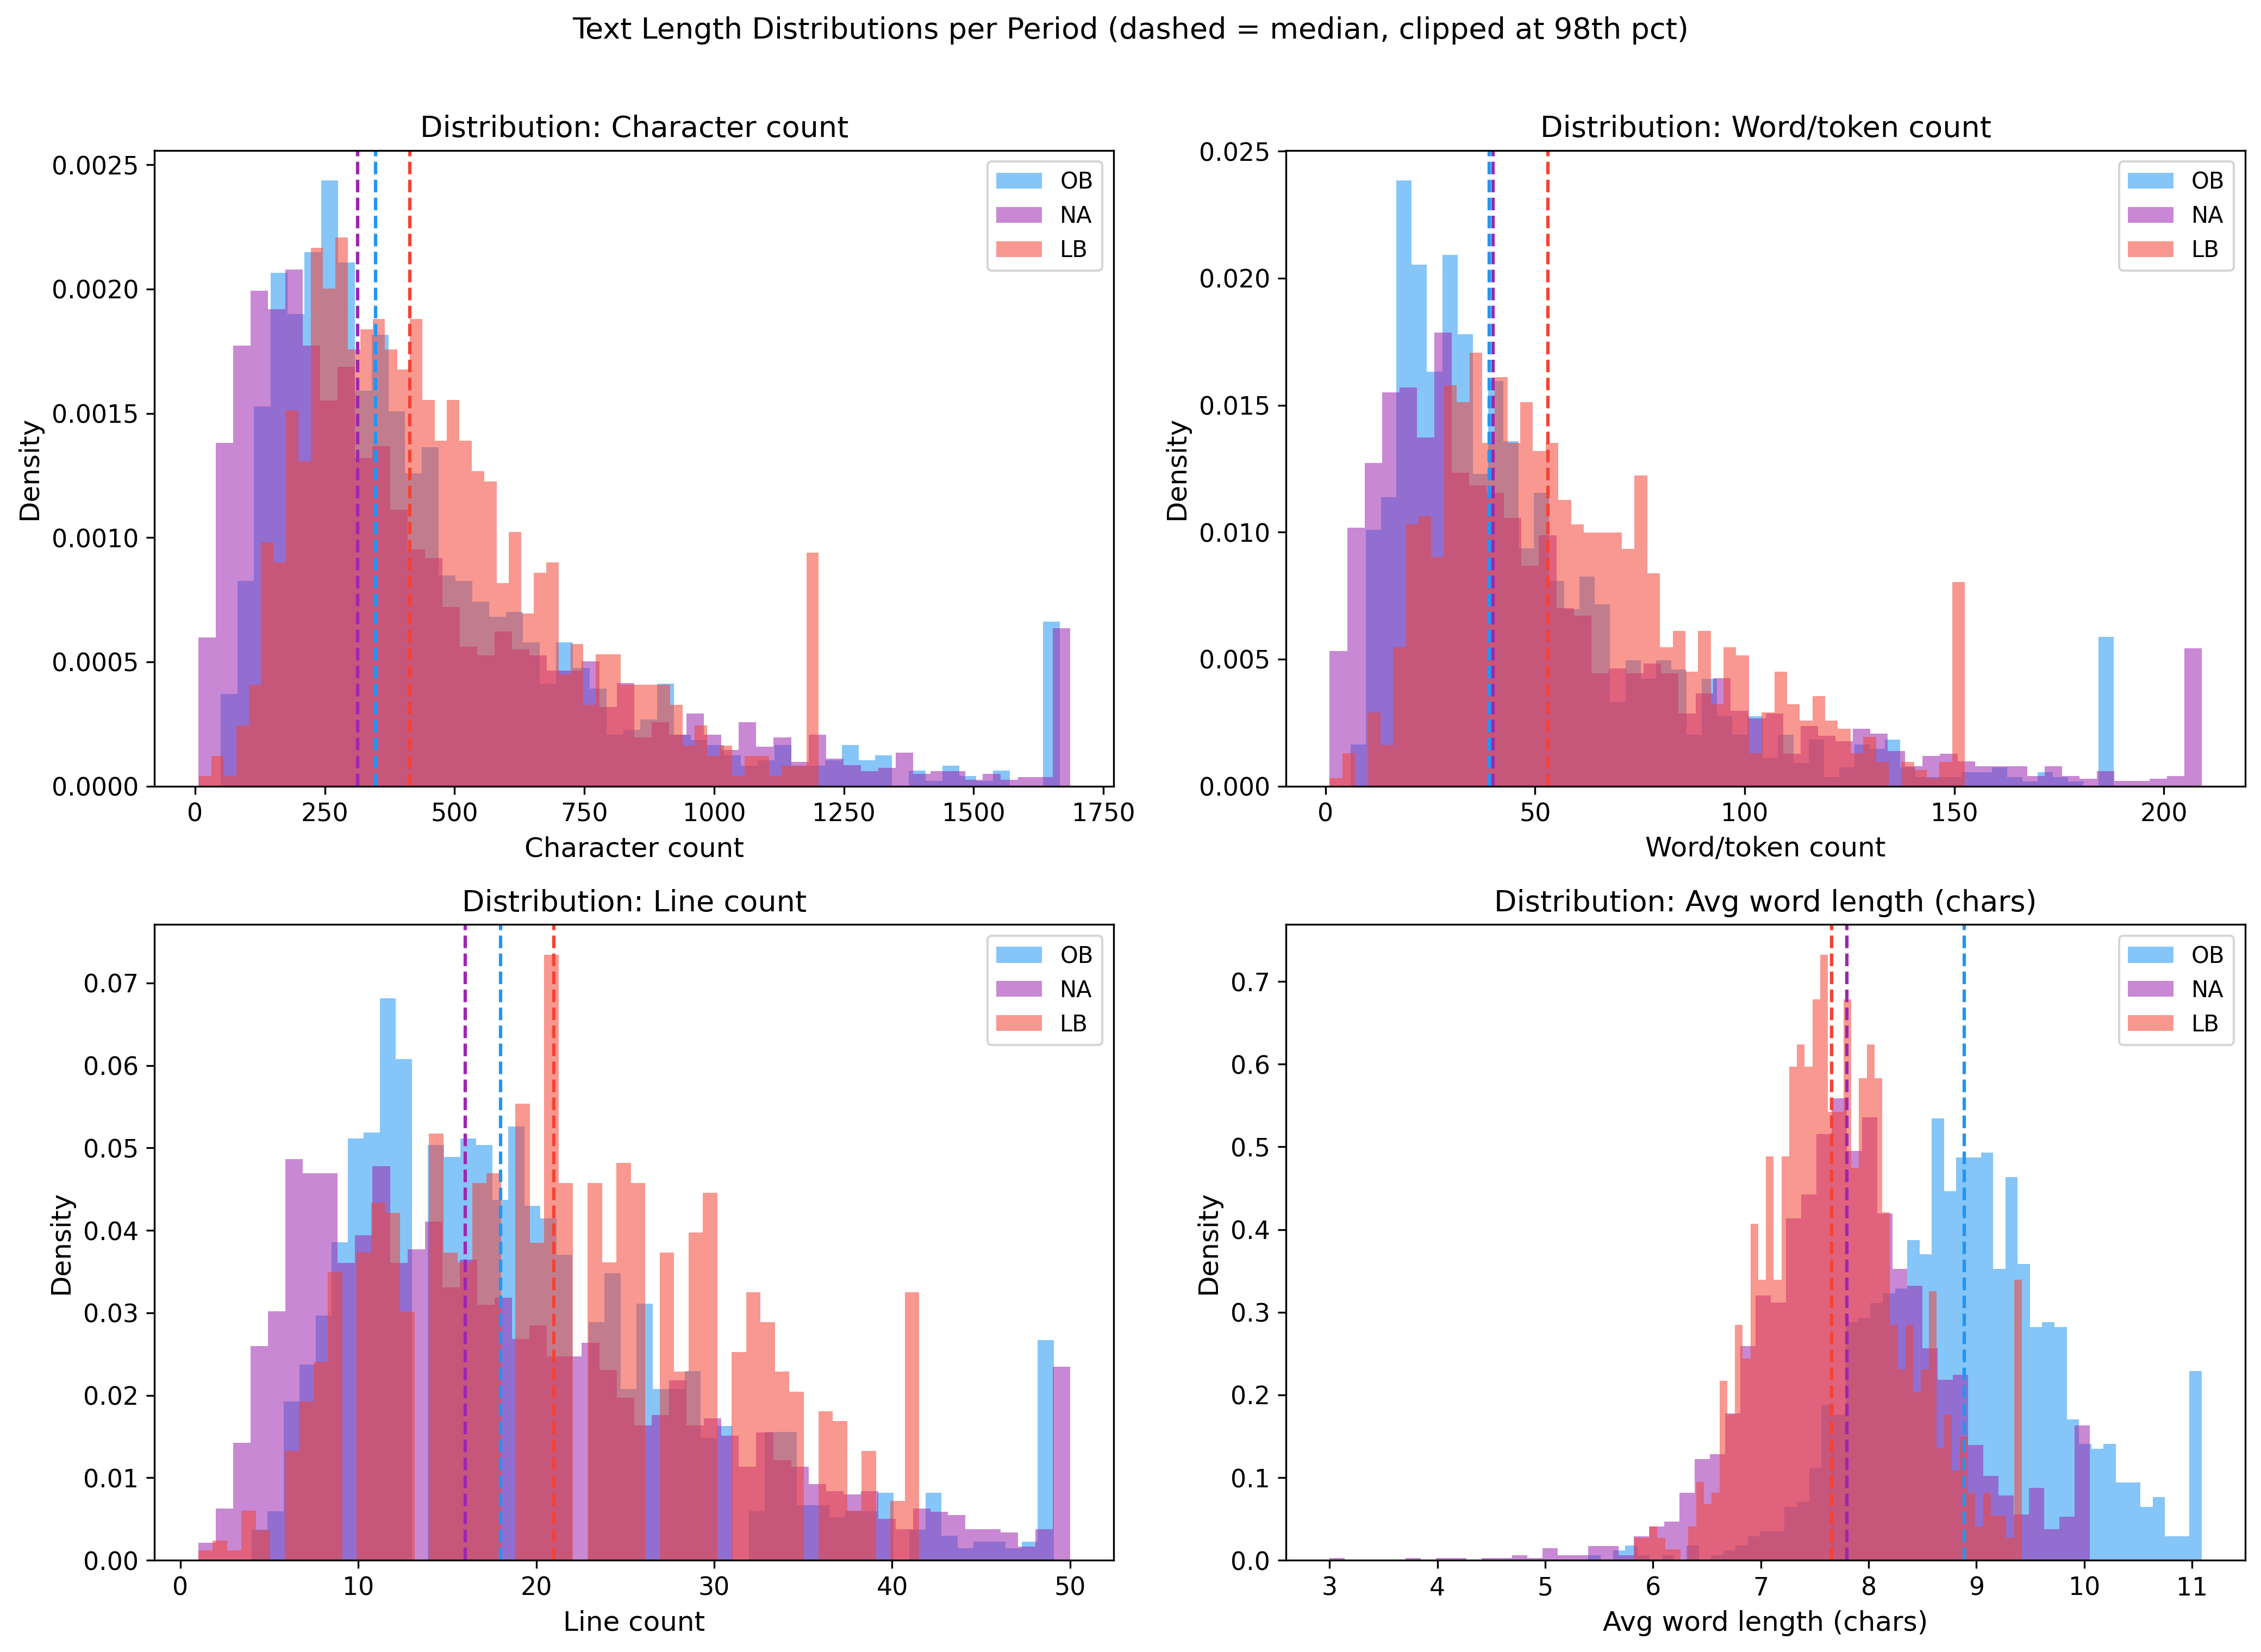

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = [
    ("n_chars",      "Character count"),
    ("n_words",      "Word/token count"),
    ("n_lines",      "Line count"),
    ("avg_word_len", "Avg word length (chars)"),
]

for ax, (col, label) in zip(axes.flat, metrics):
    for p in PERIODS:
        vals = df[df.period == p][col]
        vals_clipped = vals.clip(upper=vals.quantile(0.98))  # clip outliers for visibility
        ax.hist(vals_clipped, bins=50, alpha=0.55, label=SHORT[p],
                color=PERIOD_COLORS[p], density=True)
        ax.axvline(vals.median(), color=PERIOD_COLORS[p], linestyle="--", linewidth=1.5)
    ax.set_xlabel(label)
    ax.set_ylabel("Density")
    ax.set_title(f"Distribution: {label}")
    ax.legend()

plt.suptitle("Text Length Distributions per Period (dashed = median, clipped at 98th pct)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PLOT_DIR / "bias_length_distributions.png", bbox_inches="tight", dpi=300)
plt.show()

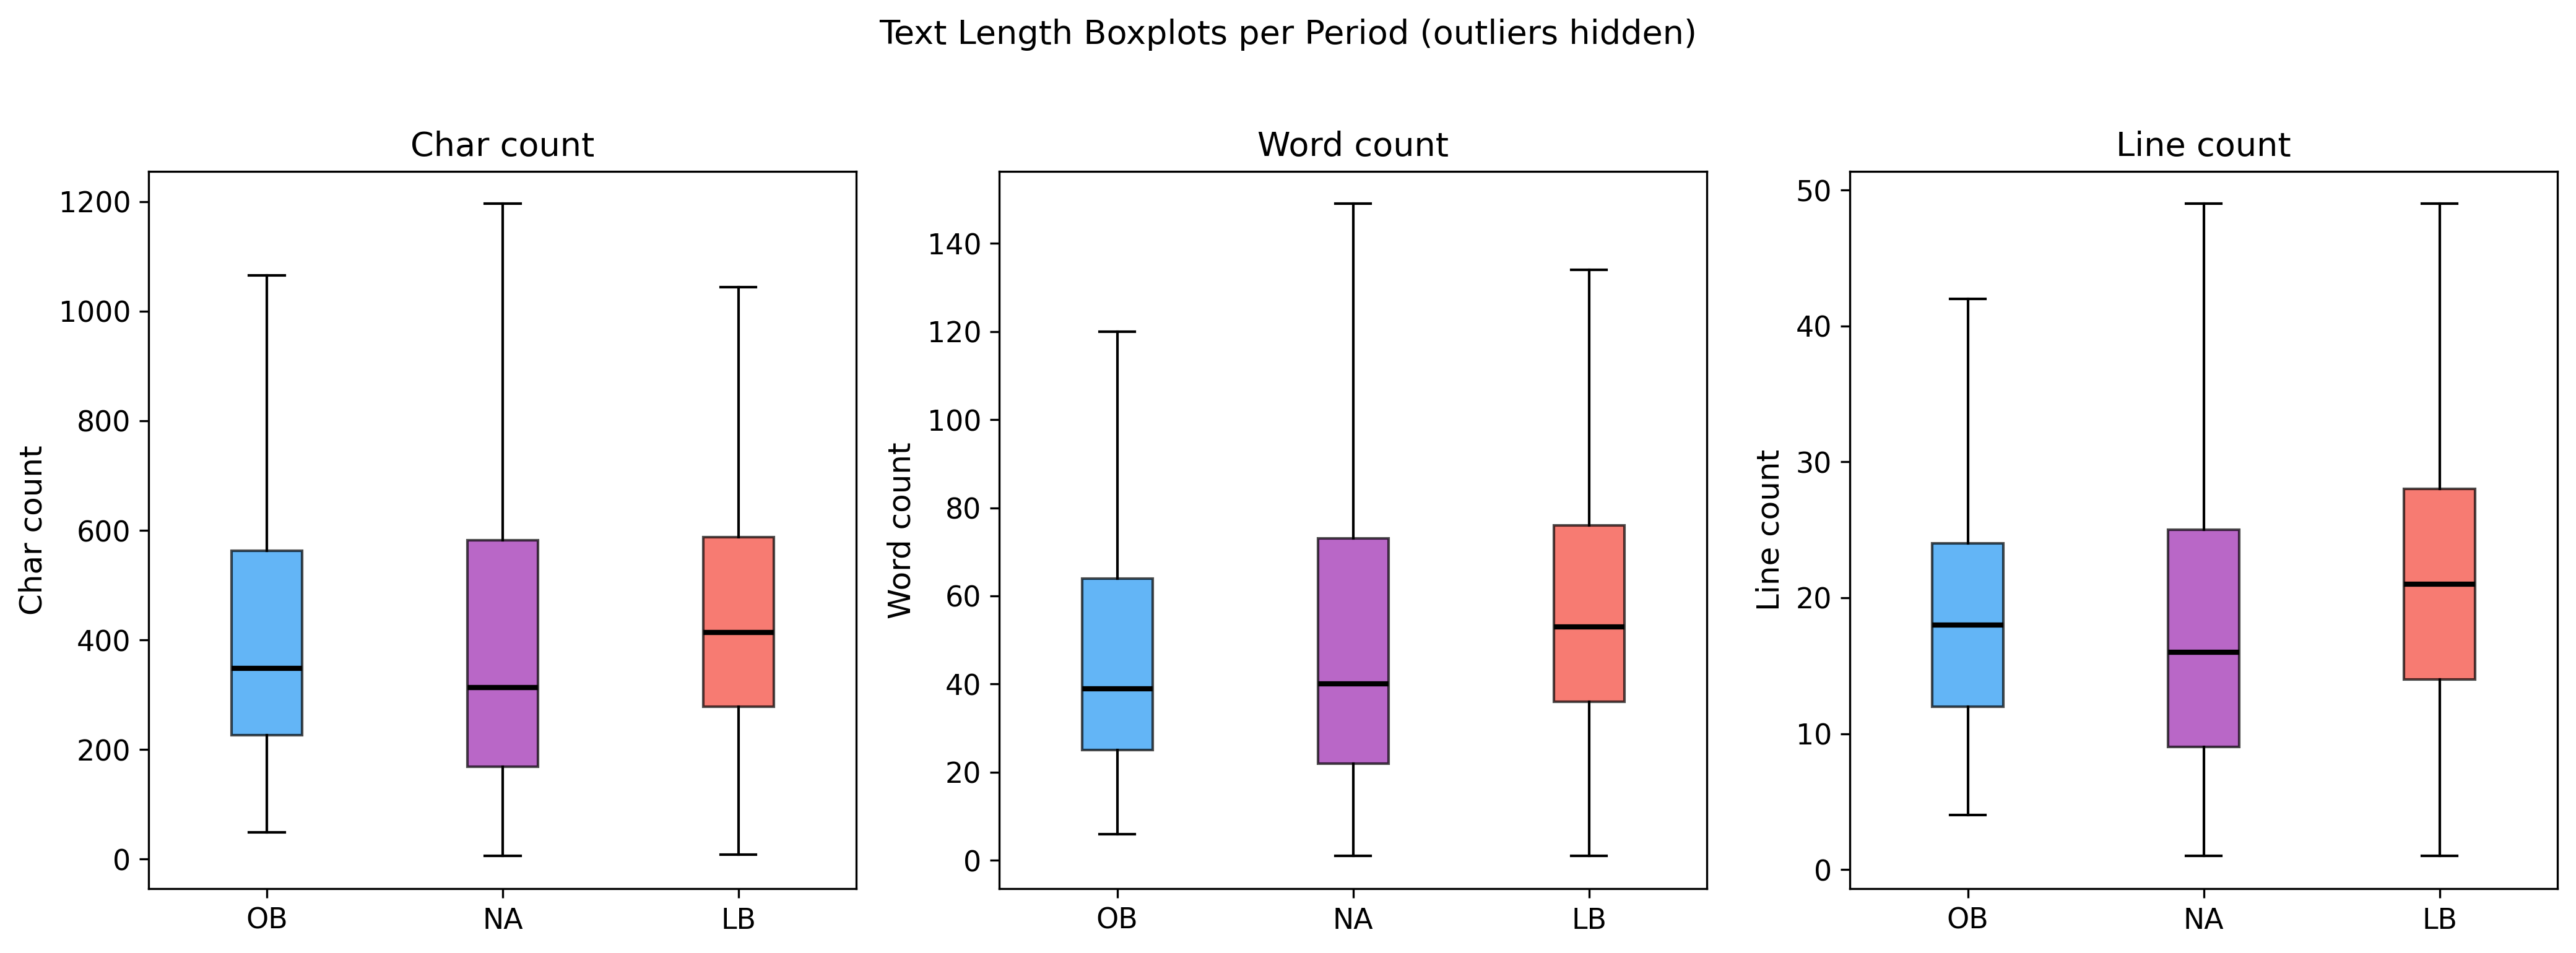

In [10]:
# Boxplots side by side for cleaner comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, (col, label) in zip(axes, [("n_chars","Char count"),("n_words","Word count"),("n_lines","Line count")]):
    data = [df[df.period == p][col].values for p in PERIODS]
    bp = ax.boxplot(data, patch_artist=True, showfliers=False,
                    medianprops={"color": "black", "linewidth": 2})
    for patch, p in zip(bp["boxes"], PERIODS):
        patch.set_facecolor(PERIOD_COLORS[p])
        patch.set_alpha(0.7)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels([SHORT[p] for p in PERIODS])
    ax.set_ylabel(label)
    ax.set_title(label)

plt.suptitle("Text Length Boxplots per Period (outliers hidden)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(PLOT_DIR / "bias_length_boxplots.png", bbox_inches="tight", dpi=300)
plt.show()

## 4. Top Discriminative Char N-Grams

Load the pre-fitted TF-IDF vectorizer and the feature matrices. Use per-period mean TF-IDF score to find the most "characteristic" n-grams for each period, and a log-odds ratio to find the most *discriminative* ones.

In [11]:
# ── Load vectorizer and feature matrices ─────────────────────────────────────
with open(FEAT_DIR / "vectorizer.pkl", "rb") as f:
    vec = pickle.load(f)

X_train = sp.load_npz(FEAT_DIR / "train.npz")
X_val   = sp.load_npz(FEAT_DIR / "val.npz")
X_test  = sp.load_npz(FEAT_DIR / "test.npz")
y_train = np.load(FEAT_DIR / "y_train.npy", allow_pickle=True)
y_val   = np.load(FEAT_DIR / "y_val.npy",   allow_pickle=True)
y_test  = np.load(FEAT_DIR / "y_test.npy",  allow_pickle=True)

feature_names = vec.get_feature_names_out()
print(f"Vocabulary size: {len(feature_names)}")
print(f"N-gram range: {vec.ngram_range}")
print(f"Analyzer: {vec.analyzer}")
print(f"Train shape: {X_train.shape}")

Vocabulary size: 10000
N-gram range: (2, 5)
Analyzer: char_wb
Train shape: (3469, 10000)


/opt/miniconda3/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.8.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/miniconda3/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.8.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Label distribution: {'Old Babylonian': 1497, 'Neo-Assyrian': 2435, 'Late Babylonian': 1025}


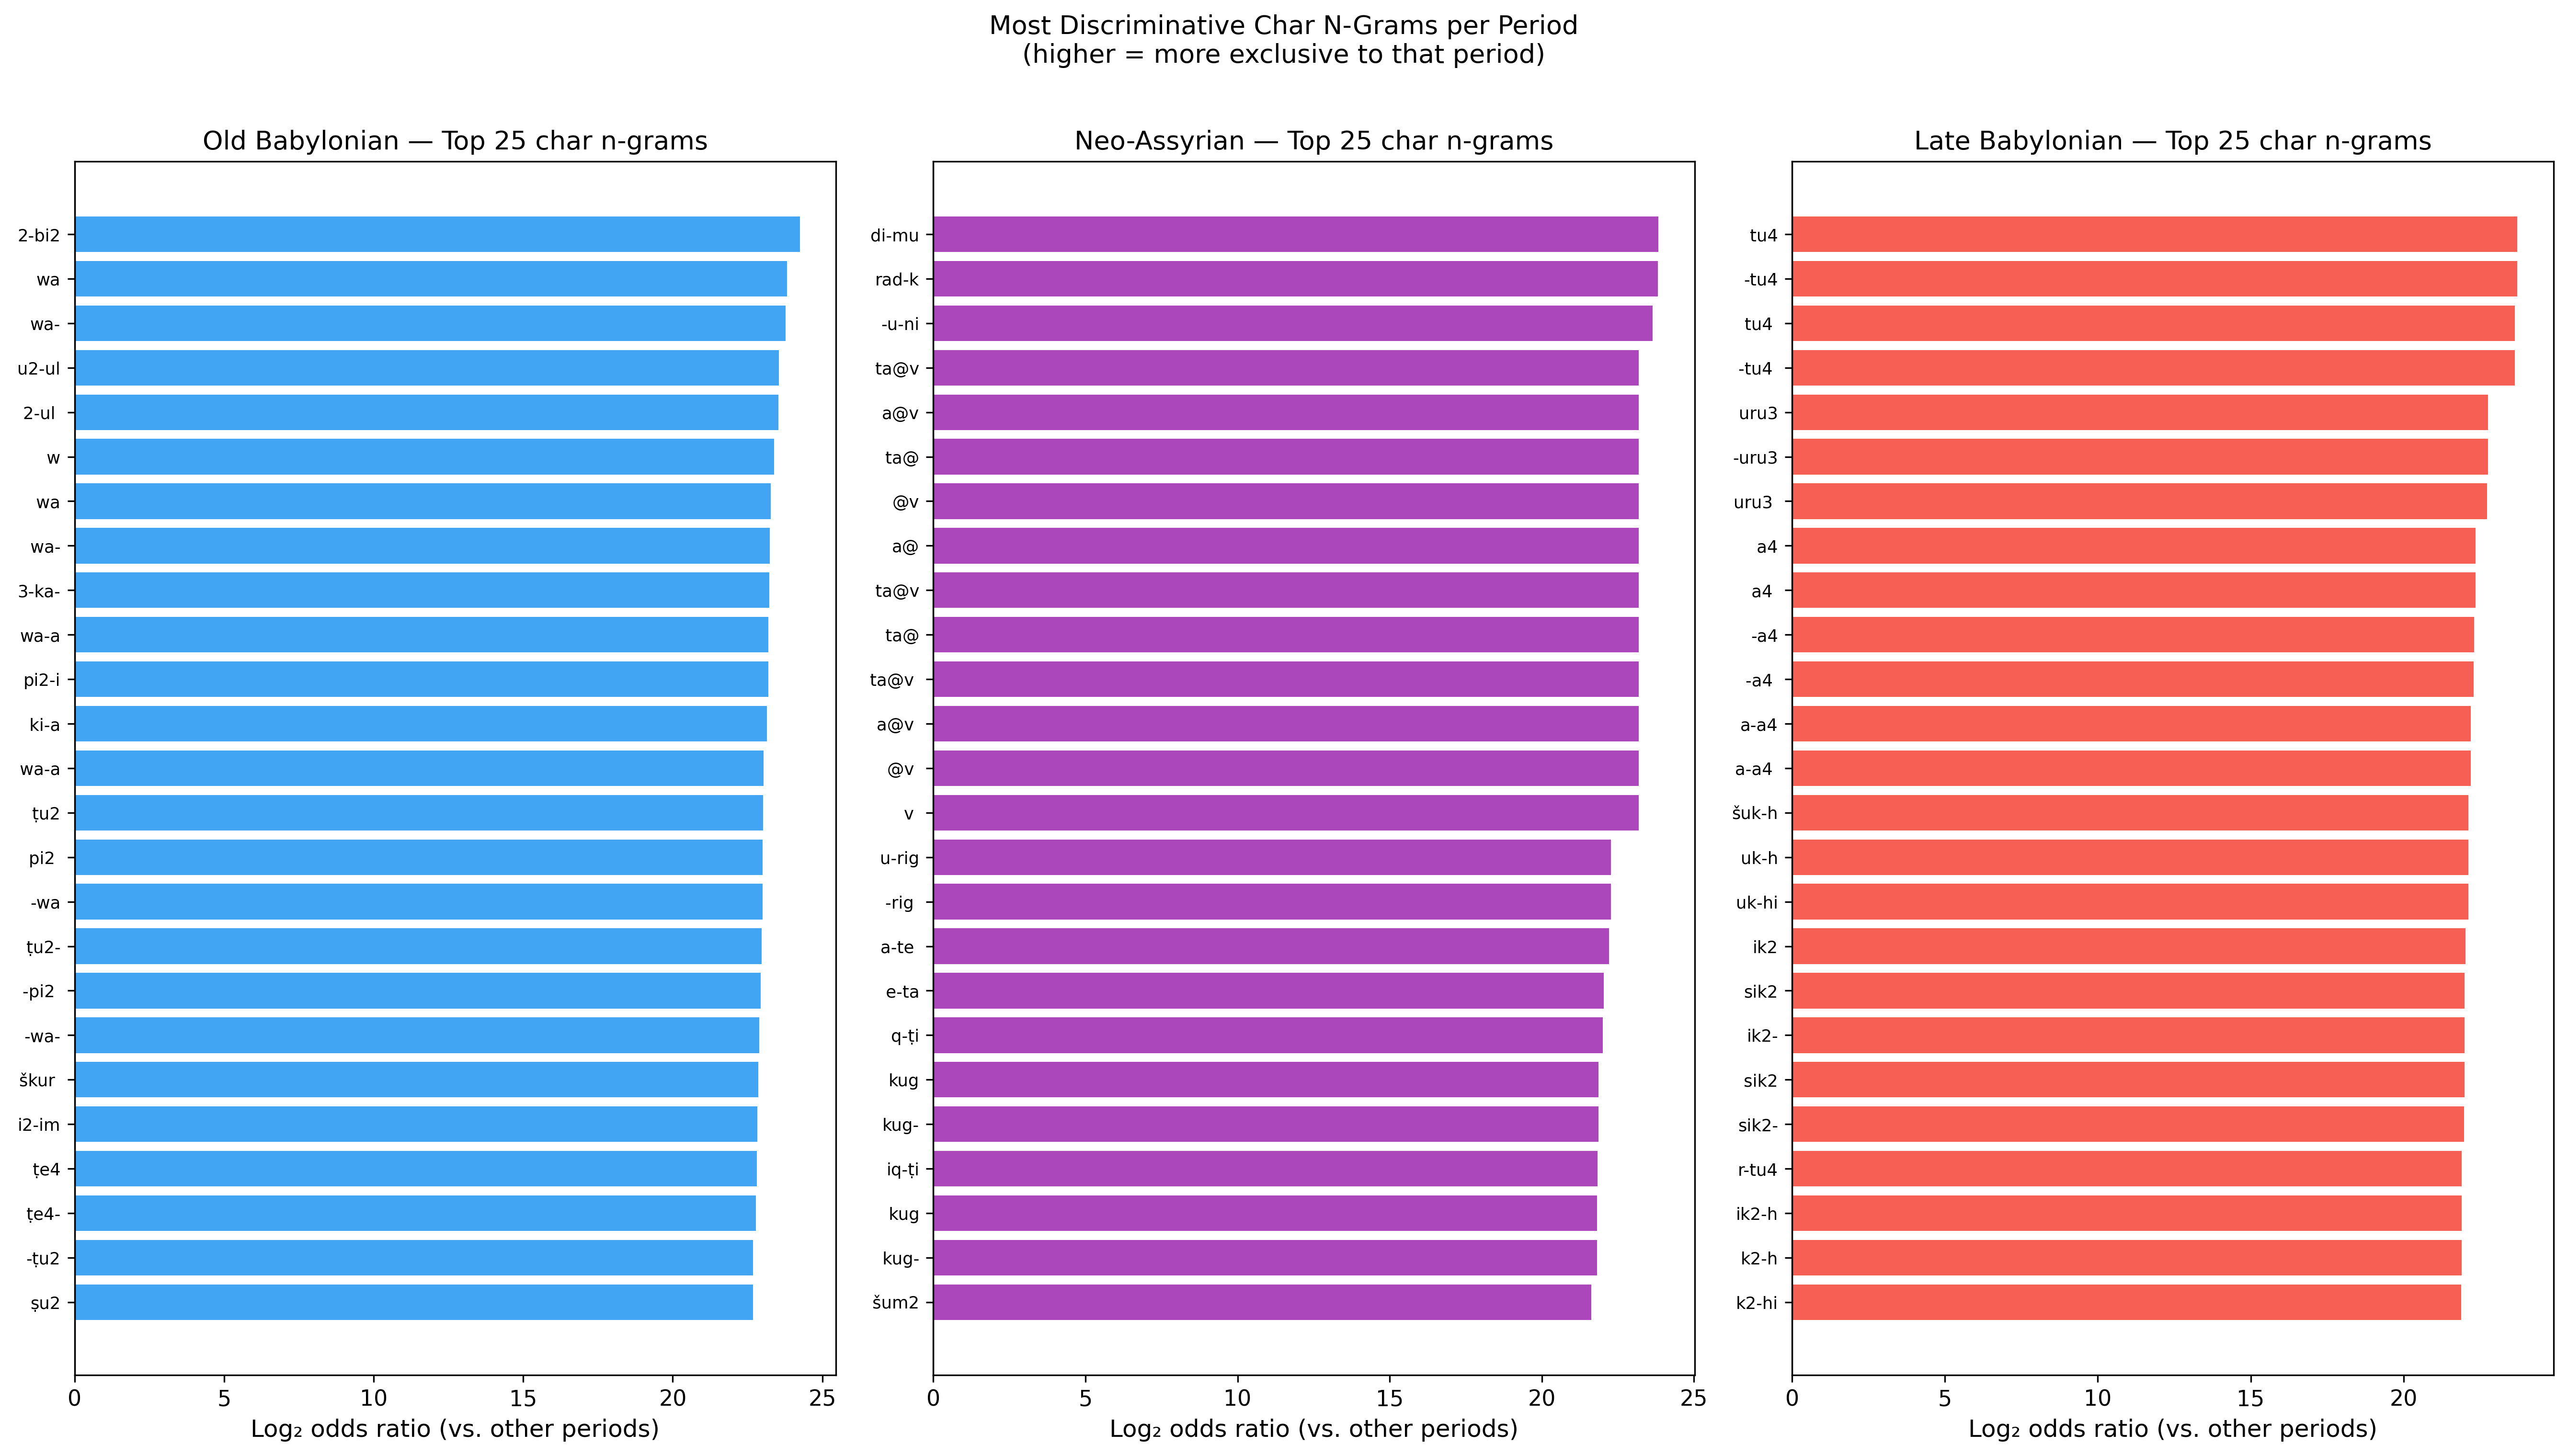

Look for: corpus markup patterns, specific orthographic conventions, sign-reading suffixes


In [12]:
# ── Per-period mean TF-IDF on train set ───────────────────────────────────────
X_all = sp.vstack([X_train, X_val, X_test])
y_all = np.concatenate([y_train, y_val, y_test])

# y files store integer labels: 0=Old Babylonian, 1=Neo-Assyrian, 2=Late Babylonian
LABEL_MAP = {0: "Old Babylonian", 1: "Neo-Assyrian", 2: "Late Babylonian"}
print("Label distribution:", {LABEL_MAP[k]: int((y_all == k).sum()) for k in LABEL_MAP})

period_means = {}
for label_int, p in LABEL_MAP.items():
    mask = y_all == label_int
    period_means[p] = np.asarray(X_all[mask].mean(axis=0)).flatten()

# Log-odds ratio: how much more does period P use this n-gram vs. the others?
eps = 1e-9
top_n = 25

fig, axes = plt.subplots(1, 3, figsize=(18, 10))
for ax, p in zip(axes, PERIODS):
    this   = period_means[p] + eps
    others = np.mean([period_means[q] for q in PERIODS if q != p], axis=0) + eps
    log_odds = np.log2(this / others)
    top_idx  = np.argsort(log_odds)[::-1][:top_n]
    top_ngrams = feature_names[top_idx]
    top_scores = log_odds[top_idx]

    ax.barh(range(top_n), top_scores[::-1], color=PERIOD_COLORS[p], alpha=0.85)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([repr(ng)[1:-1] for ng in top_ngrams[::-1]], fontsize=8.5)
    ax.set_xlabel("Log₂ odds ratio (vs. other periods)")
    ax.set_title(f"{p} — Top {top_n} char n-grams")
    ax.axvline(0, color="black", linewidth=0.8)

plt.suptitle("Most Discriminative Char N-Grams per Period\n(higher = more exclusive to that period)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PLOT_DIR / "bias_top_ngrams.png", bbox_inches="tight", dpi=300)
plt.show()
print("Look for: corpus markup patterns, specific orthographic conventions, sign-reading suffixes")

In [13]:
# Print the top 40 discriminative n-grams per period in plain text for inspection
for p in PERIODS:
    this   = period_means[p] + eps
    others = np.mean([period_means[q] for q in PERIODS if q != p], axis=0) + eps
    log_odds = np.log2(this / others)
    top_idx  = np.argsort(log_odds)[::-1][:40]
    print(f"\n{'='*50}")
    print(f"{p} — top 40 discriminative n-grams:")
    for i, idx in enumerate(top_idx):
        print(f"  {i+1:2d}. {repr(feature_names[idx]):<20s}  log-odds={log_odds[idx]:.2f}")


Old Babylonian — top 40 discriminative n-grams:
   1. '2-bi2'               log-odds=24.25
   2. 'wa'                  log-odds=23.83
   3. 'wa-'                 log-odds=23.76
   4. 'u2-ul'               log-odds=23.54
   5. '2-ul '               log-odds=23.53
   6. ' w'                  log-odds=23.38
   7. ' wa'                 log-odds=23.27
   8. ' wa-'                log-odds=23.25
   9. '3-ka-'               log-odds=23.23
  10. 'wa-a'                log-odds=23.20
  11. 'pi2-i'               log-odds=23.19
  12. ' ki-a'               log-odds=23.15
  13. ' wa-a'               log-odds=23.03
  14. 'ṭu2'                 log-odds=23.02
  15. 'pi2 '                log-odds=23.01
  16. '-wa'                 log-odds=23.00
  17. 'ṭu2-'                log-odds=22.97
  18. '-pi2 '               log-odds=22.95
  19. '-wa-'                log-odds=22.89
  20. 'škur '               log-odds=22.85
  21. 'i2-im'               log-odds=22.82
  22. ' ṭe4'                log-odds=22.80
  23.

## 5. Diacritic & Special Character Frequencies

Akkadian transliteration uses diacritics (ā, ī, ū, ē, š, ṣ, ṭ, ḫ) whose usage varies across corpora and periods. Also check numbers used as reading subscripts (sign2, sign3, etc.).

In [14]:
# Characters to track — diacritics, macrons, subscripts
SPECIAL_CHARS = {
    # Emphatic/fricative consonants
    "š": "š (shin)",
    "ṣ": "ṣ (tsade)",
    "ṭ": "ṭ (tet)",
    "ḫ": "ḫ (heth)",
    # Long vowels
    "ā": "ā (long a)",
    "ī": "ī (long i)",
    "ū": "ū (long u)",
    "ē": "ē (long e)",
    # Reading subscript numbers (appear in transliteration as suffix digits)
    "2": "2 (reading subscript)",
    "3": "3 (reading subscript)",
    "4": "4 (reading subscript)",
    # Uppercase (logograms/Sumerian words)
    # We'll measure uppercase ratio separately
}

def char_rate(text, char):
    """Rate of char per 100 characters."""
    if len(text) == 0:
        return 0
    return text.count(char) / len(text) * 100

for char in SPECIAL_CHARS:
    df[f"rate_{char}"] = df["full_text"].apply(lambda t: char_rate(t, char))

# Also: uppercase letter ratio (logograms are uppercase in transliteration)
df["rate_upper"] = df["full_text"].apply(
    lambda t: sum(1 for c in t if c.isupper()) / max(len(t), 1) * 100
)

# Hyphen rate (word-internal morpheme separator in transliteration)
df["rate_hyphen"] = df["full_text"].apply(lambda t: char_rate(t, "-"))

print("Computed character rate features.")
char_cols = [f"rate_{c}" for c in SPECIAL_CHARS] + ["rate_upper", "rate_hyphen"]
print(df.groupby("period")[char_cols].mean().round(3).to_string())

Computed character rate features.
                 rate_š  rate_ṣ  rate_ṭ  rate_ḫ  rate_ā  rate_ī  rate_ū  rate_ē  rate_2  rate_3  rate_4  rate_upper  rate_hyphen
period                                                                                                                          
Late Babylonian   3.168   0.237   0.244     0.0     0.0     0.0     0.0     0.0   3.463   0.742   0.301      19.512       18.197
Neo-Assyrian      3.224   0.246   0.200     0.0     0.0     0.0     0.0     0.0   2.904   0.535   0.034      18.246       17.676
Old Babylonian    3.085   0.431   0.388     0.0     0.0     0.0     0.0     0.0   2.993   0.968   0.152       8.333       20.788


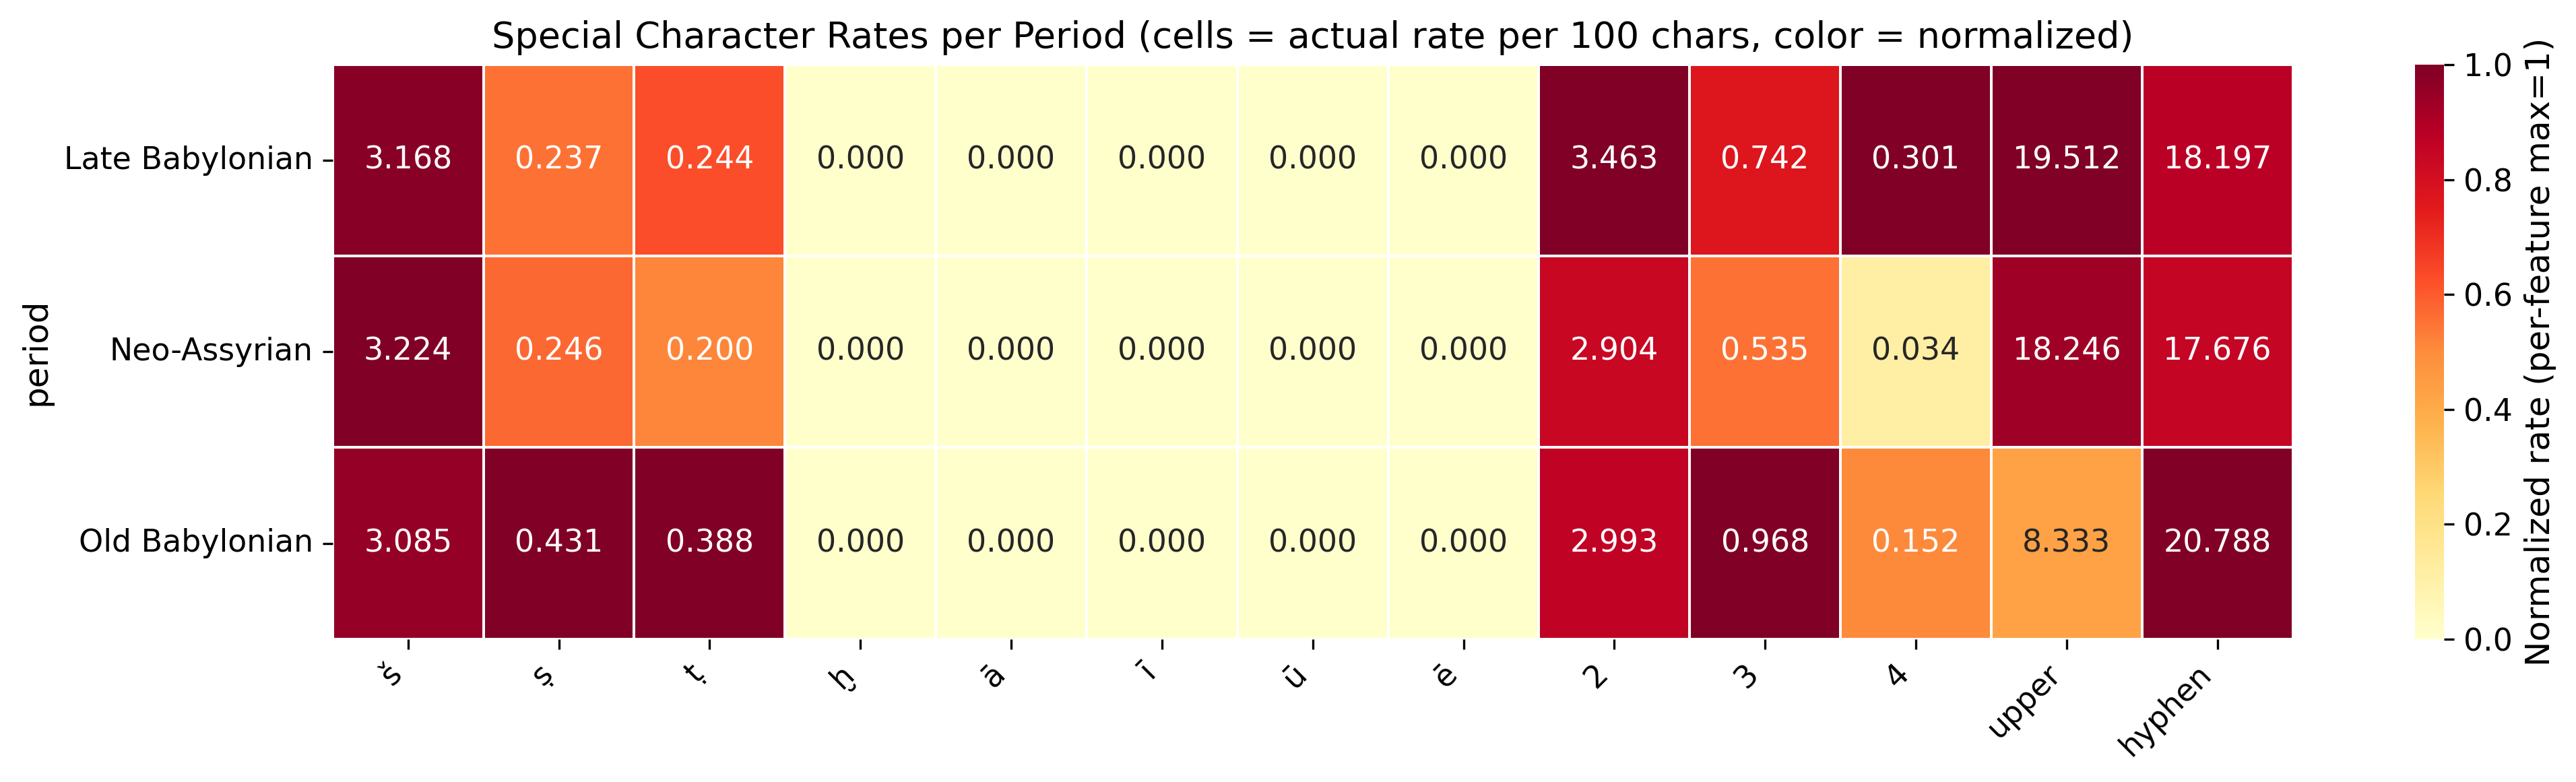

In [15]:
# Plot char frequency heatmap
mean_rates = df.groupby("period")[char_cols].mean()
# Normalize each column by its max so all features are on same scale
mean_rates_norm = mean_rates.div(mean_rates.max(axis=0) + 1e-9)

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    mean_rates_norm,
    annot=mean_rates.round(3),
    fmt=".3f",
    cmap="YlOrRd",
    ax=ax,
    linewidths=0.5,
    cbar_kws={"label": "Normalized rate (per-feature max=1)"},
)
ax.set_xticklabels(
    [c.replace("rate_", "") for c in char_cols],
    rotation=45, ha="right"
)
ax.set_title("Special Character Rates per Period (cells = actual rate per 100 chars, color = normalized)")
plt.tight_layout()
plt.savefig(PLOT_DIR / "bias_char_rates_heatmap.png", bbox_inches="tight", dpi=300)
plt.show()

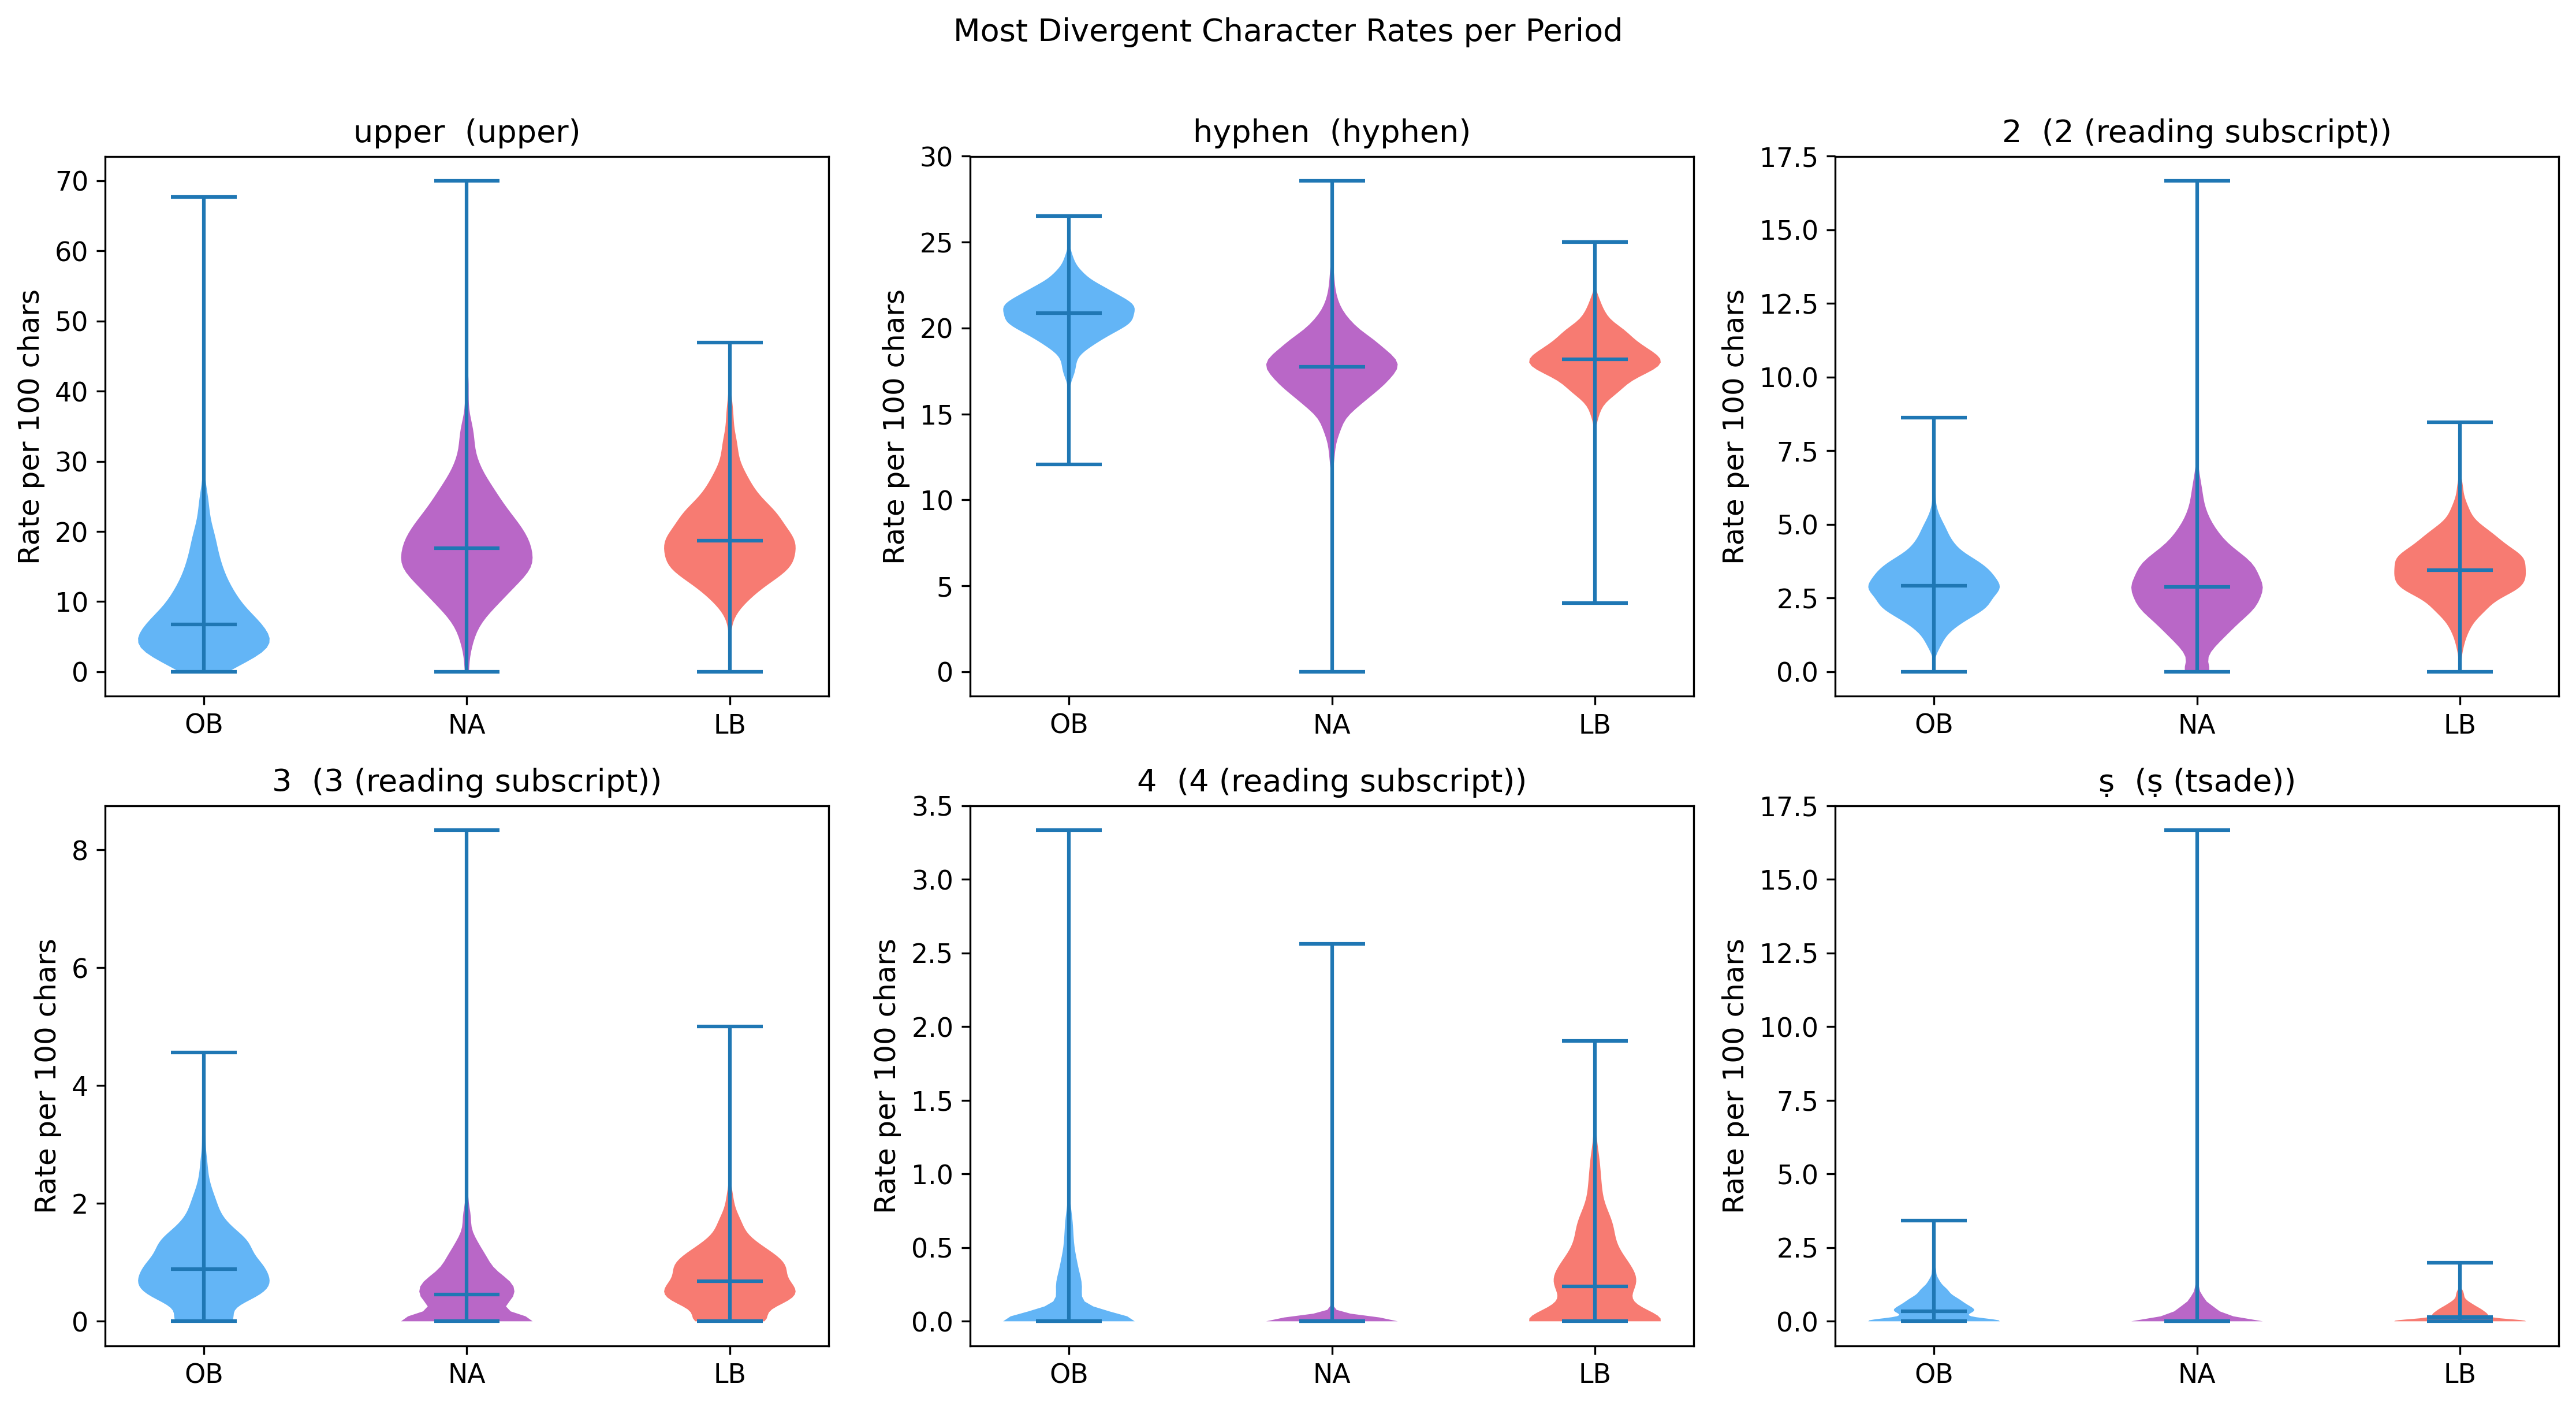

In [16]:
# Violin plots for the most divergent chars
divergent = mean_rates.std(axis=0).nlargest(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, divergent):
    data = [df[df.period == p][col].values for p in PERIODS]
    vp = ax.violinplot(data, positions=[1, 2, 3], showmedians=True)
    for pc, p in zip(vp["bodies"], PERIODS):
        pc.set_facecolor(PERIOD_COLORS[p])
        pc.set_alpha(0.7)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels([SHORT[p] for p in PERIODS])
    ax.set_ylabel("Rate per 100 chars")
    char_label = col.replace("rate_", "")
    desc = SPECIAL_CHARS.get(char_label, char_label)
    ax.set_title(f"{char_label}  ({desc})")

plt.suptitle("Most Divergent Character Rates per Period", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PLOT_DIR / "bias_char_rates_violin.png", bbox_inches="tight", dpi=300)
plt.show()

## 6. Number Suffix Conventions

In cuneiform transliteration, digits after a sign word (e.g. `be2`, `li3`, `ga4`) indicate *homophone subscripts* — different sign readings. The conventions (which number appears with which word) are partly corpus-tradition-specific.

In [17]:
# Extract all tokens that end with a digit suffix (e.g. 'li2', 'ga3', 'bu4')
def extract_subscript_tokens(text):
    """Return list of word-tokens that end with a digit subscript."""
    tokens = re.findall(r'[a-zA-ZšṣṭḫāīūēŠṢṬḪĀĪŪĒ]+[2-9]', text)
    return tokens

df["subscript_tokens"] = df["full_text"].apply(extract_subscript_tokens)
df["n_subscript_tokens"] = df["subscript_tokens"].apply(len)
df["subscript_rate"] = df["n_subscript_tokens"] / df["n_words"].clip(lower=1)

print("Subscript token rate per period:")
print(df.groupby("period")["subscript_rate"].describe().round(3))
print()

# Top subscript tokens per period
for p in PERIODS:
    all_tokens = []
    for tlist in df[df.period == p]["subscript_tokens"]:
        all_tokens.extend([t.lower() for t in tlist])
    top = Counter(all_tokens).most_common(20)
    print(f"\n{p} — top 20 subscript tokens:")
    print("  ", [(t, c) for t, c in top])

Subscript token rate per period:
                  count   mean    std    min    25%    50%    75%    max
period                                                                  
Late Babylonian  1025.0  0.344  0.099  0.000  0.280  0.342  0.408  0.833
Neo-Assyrian     2435.0  0.275  0.135  0.000  0.189  0.268  0.350  2.000
Old Babylonian   1497.0  0.373  0.110  0.062  0.300  0.366  0.436  1.000


Old Babylonian — top 20 subscript tokens:
   [('u2', 4008), ('u3', 3049), ('li2', 2902), ('lu2', 1847), ('qi2', 1612), ('bi2', 1216), ('pi2', 1126), ('ša3', 833), ('e2', 710), ('ir3', 706), ('ṭe4', 497), ('ṭu2', 418), ('ne2', 416), ('qu2', 381), ('ṣi2', 347), ('ṣu2', 339), ('su2', 301), ('i3', 295), ('ku3', 289), ('kal2', 282)]

Neo-Assyrian — top 20 subscript tokens:
   [('u2', 5538), ('šu2', 4782), ('lu2', 4405), ('li2', 4064), ('ša2', 3678), ('ša3', 2021), ('e2', 1845), ('ia2', 1691), ('u3', 1492), ('aš2', 1299), ('tu2', 1098), ('erin2', 601), ('ṭe3', 520), ('ne2', 418), ('dug3', 329), ('ba

In [18]:
# Which subscript tokens are period-exclusive (only appear in one period)?
from collections import defaultdict

token_period_counts = defaultdict(Counter)
for _, row in df.iterrows():
    for tok in set(t.lower() for t in row["subscript_tokens"]):
        token_period_counts[tok][row["period"]] += 1

exclusive = {"Old Babylonian": [], "Neo-Assyrian": [], "Late Babylonian": []}
for tok, period_counts in token_period_counts.items():
    if len(period_counts) == 1:  # only appears in one period
        p = list(period_counts.keys())[0]
        exclusive[p].append((tok, period_counts[p]))

print("Period-exclusive subscript tokens (appear in only 1 period):")
for p in PERIODS:
    excl = sorted(exclusive[p], key=lambda x: -x[1])
    print(f"\n{p}: {len(excl)} exclusive tokens")
    print("  Top 20:", excl[:20])

Period-exclusive subscript tokens (appear in only 1 period):

Old Babylonian: 108 exclusive tokens
  Top 20: [('ṭu2', 311), ('ṣu2', 253), ('ṭa3', 188), ('kal2', 178), ('pe2', 173), ('di2', 162), ('si2', 107), ('is3', 82), ('tar2', 67), ('iš8', 65), ('ṣe2', 60), ('ni3', 55), ('ṭa2', 40), ('ia3', 30), ('sa6', 28), ('as3', 27), ('uh2', 26), ('tur2', 26), ('se2', 23), ('ra2', 21)]

Neo-Assyrian: 76 exclusive tokens
  Top 20: [('ṭi2', 110), ('gur2', 46), ('dul6', 29), ('rem2', 27), ('bur2', 25), ('bil2', 22), ('nigir2', 20), ('kal3', 18), ('qal3', 15), ('ku2', 11), ('sa5', 9), ('ṭe2', 8), ('bir4', 6), ('mar2', 6), ('zah2', 6), ('kat3', 6), ('mud2', 5), ('in6', 5), ('kaṣ3', 4), ('lih3', 4)]

Late Babylonian: 114 exclusive tokens
  Top 20: [('tu4', 285), ('uru3', 160), ('ti3', 71), ('sik2', 70), ('em4', 21), ('ep2', 17), ('ku4', 12), ('rig7', 9), ('šul3', 9), ('tiq2', 8), ('lib3', 7), ('ila2', 6), ('kad2', 6), ('peš3', 5), ('had2', 5), ('kin3', 5), ('pet2', 3), ('sizkur2', 3), ('qid2', 3), ('

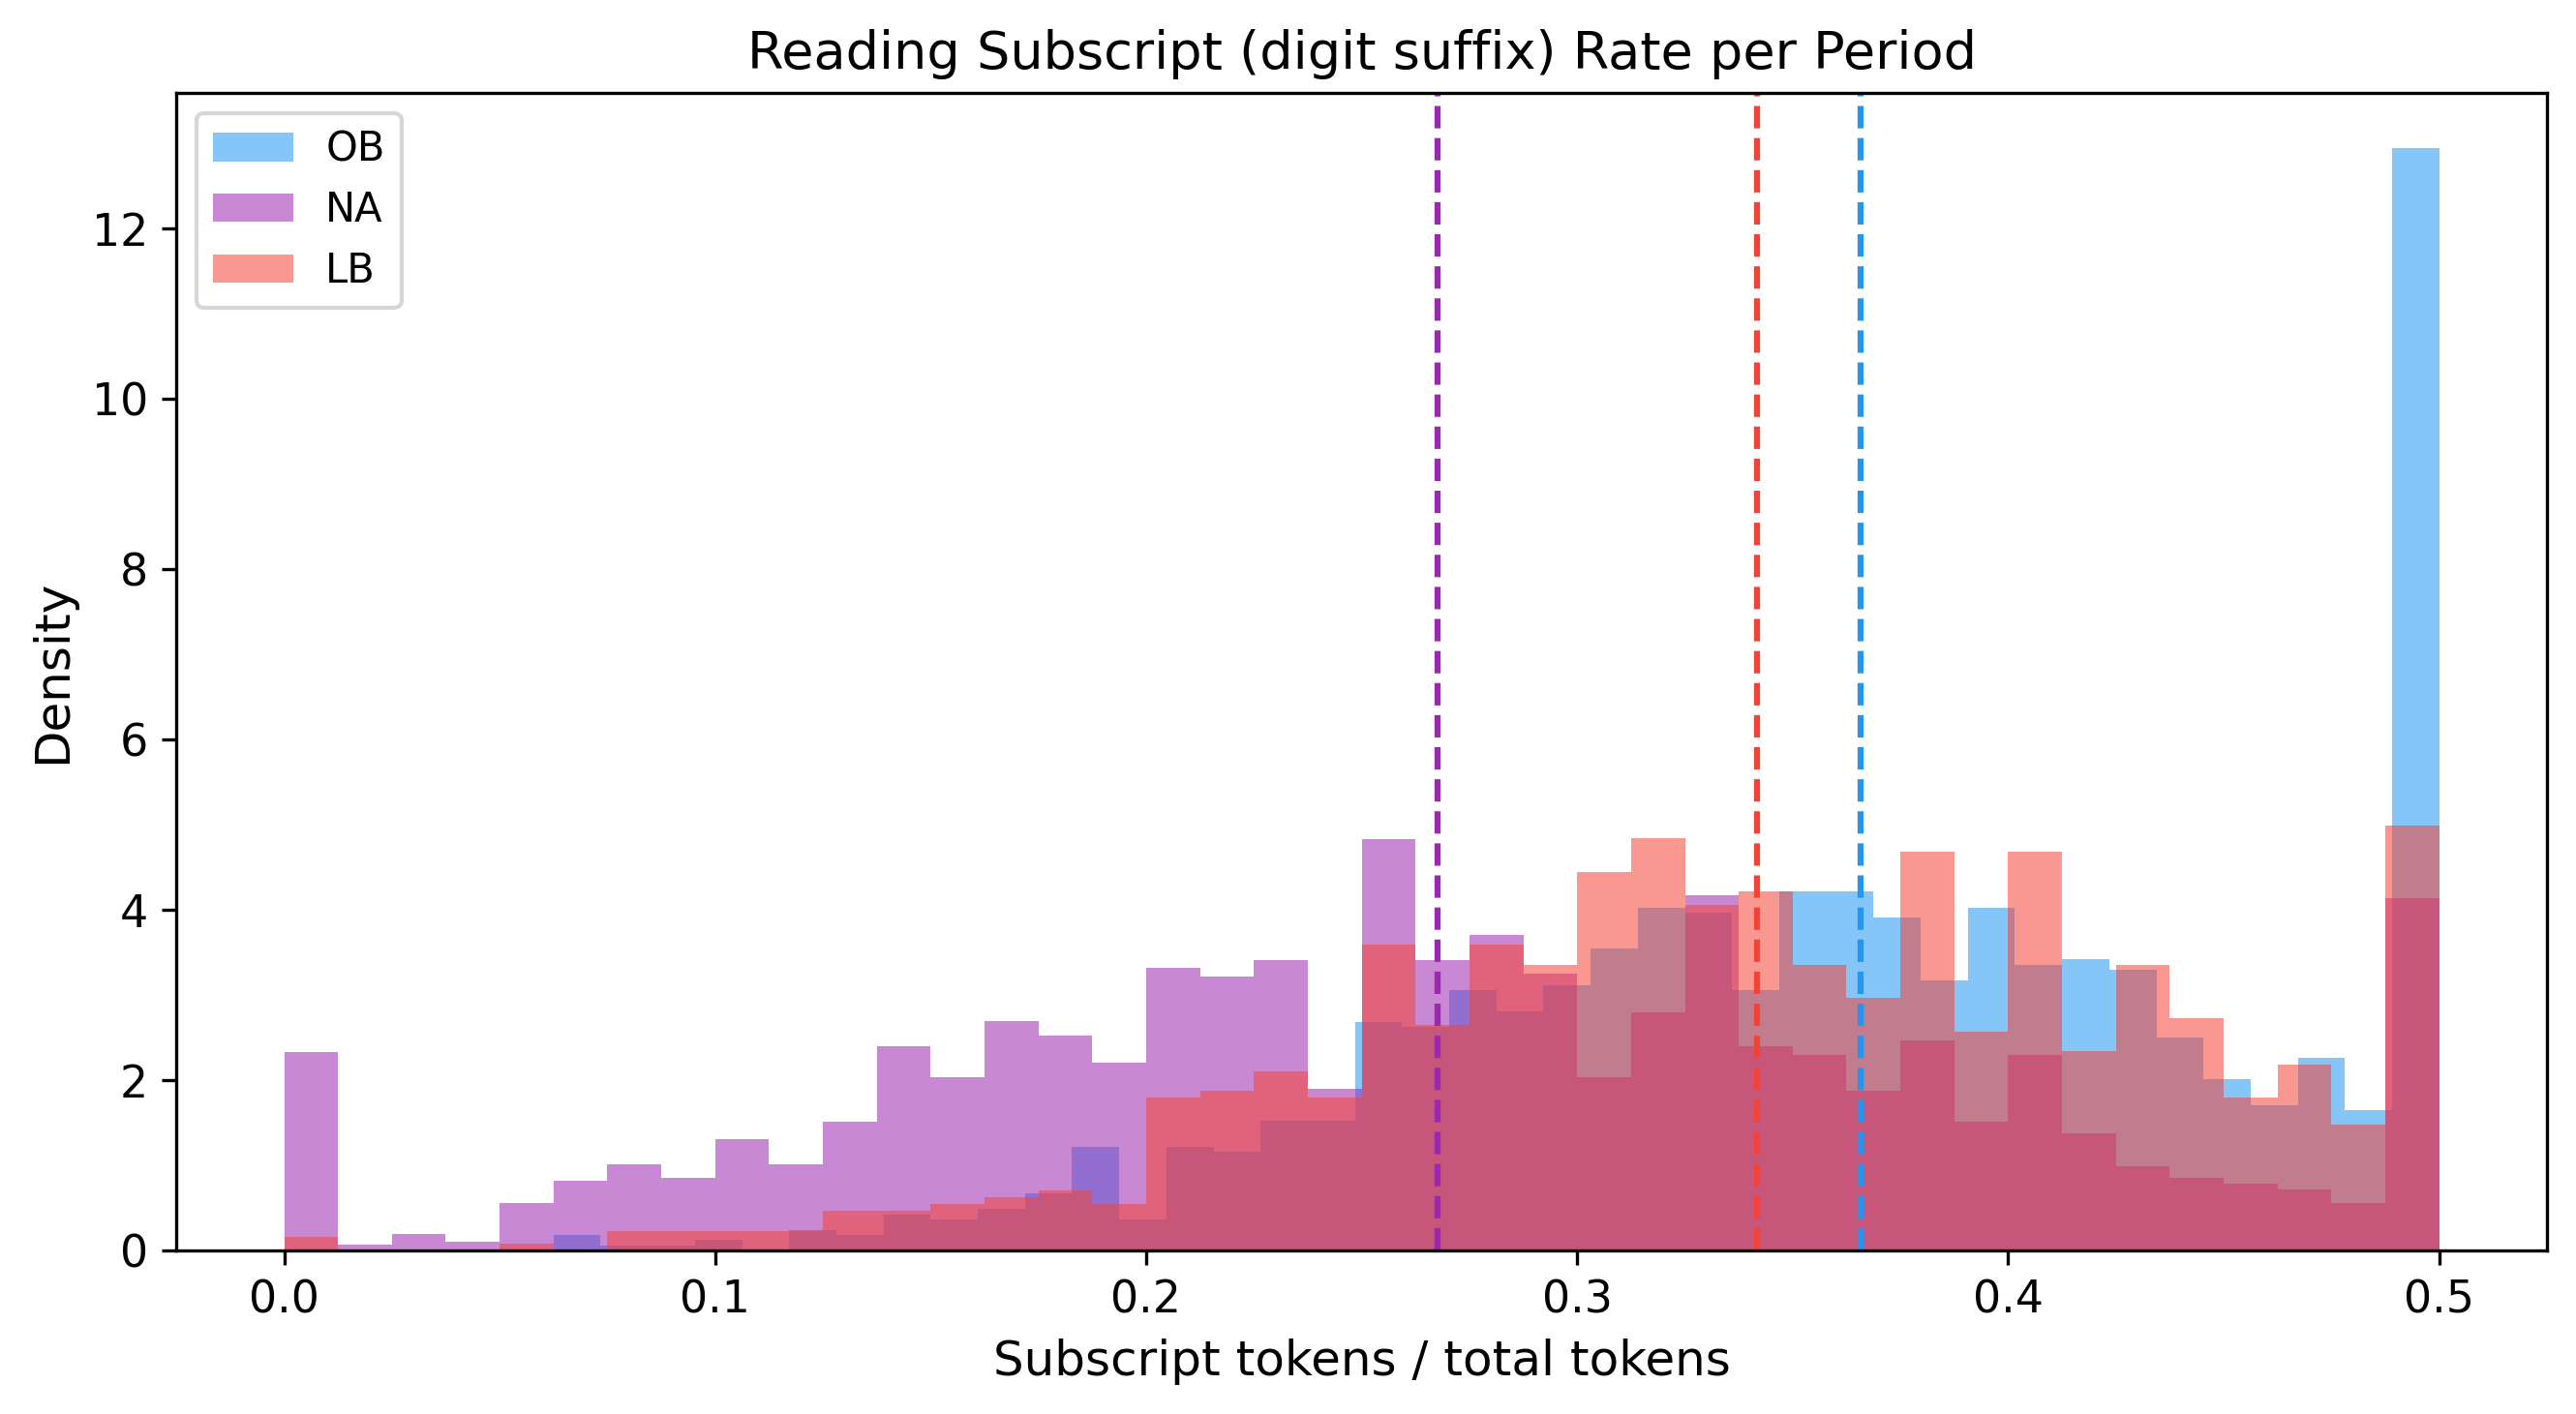

In [19]:
# Plot subscript rate distribution
fig, ax = plt.subplots(figsize=(9, 5))
for p in PERIODS:
    vals = df[df.period == p]["subscript_rate"].clip(upper=0.5)
    ax.hist(vals, bins=40, alpha=0.55, density=True,
            label=SHORT[p], color=PERIOD_COLORS[p])
    ax.axvline(vals.median(), color=PERIOD_COLORS[p], linestyle="--", lw=1.5)

ax.set_xlabel("Subscript tokens / total tokens")
ax.set_ylabel("Density")
ax.set_title("Reading Subscript (digit suffix) Rate per Period")
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "bias_subscript_rate.png", bbox_inches="tight", dpi=300)
plt.show()

## 7. Vocabulary & Token Overlap

How much of the vocabulary (word-level tokens) is shared across periods vs. period-exclusive?

In [20]:
# Build per-period token vocabularies (lowercase)
def get_vocab(texts):
    tokens = set()
    for t in texts:
        tokens.update(re.findall(r'[a-zA-ZšṣṭḫāīūēŠṢṬḪĀĪŪĒ0-9]+', t.lower()))
    return tokens

vocabs = {p: get_vocab(df[df.period == p]["full_text"]) for p in PERIODS}

print("Vocabulary sizes:")
for p in PERIODS:
    print(f"  {SHORT[p]}: {len(vocabs[p]):,} unique tokens")

# Pairwise overlap
print("\nPairwise Jaccard similarity:")
for i, p1 in enumerate(PERIODS):
    for p2 in PERIODS[i+1:]:
        inter = len(vocabs[p1] & vocabs[p2])
        union = len(vocabs[p1] | vocabs[p2])
        print(f"  {SHORT[p1]} ∩ {SHORT[p2]}: {inter:,} shared tokens  |  Jaccard={inter/union:.3f}")

# Triple overlap
triple = vocabs[PERIODS[0]] & vocabs[PERIODS[1]] & vocabs[PERIODS[2]]
print(f"\nTokens in ALL 3 periods: {len(triple):,}")

# Exclusive tokens
print("\nPeriod-exclusive tokens (not in any other period):")
for p in PERIODS:
    others = set.union(*[vocabs[q] for q in PERIODS if q != p])
    exclusive_v = vocabs[p] - others
    print(f"  {SHORT[p]}: {len(exclusive_v):,} exclusive tokens")
    print("    Examples:", list(sorted(exclusive_v))[:30])

Vocabulary sizes:
  OB: 648 unique tokens
  NA: 934 unique tokens
  LB: 1,070 unique tokens

Pairwise Jaccard similarity:
  OB ∩ NA: 442 shared tokens  |  Jaccard=0.388
  OB ∩ LB: 429 shared tokens  |  Jaccard=0.333
  NA ∩ LB: 676 shared tokens  |  Jaccard=0.509

Tokens in ALL 3 periods: 383

Period-exclusive tokens (not in any other period):
  OB: 160 exclusive tokens
    Examples: ['agrig', 'akšak', 'am7', 'as3', 'aw', 'az2', 'aš5', 'ba2', 'banda', 'banda3', 'bara3', 'da10', 'da2', 'dab5', 'dam2', 'de4', 'di2', 'di3', 'didli', 'dilmun', 'dim4', 'du10', 'du2', 'duru5', 'elam', 'eme5', 'ensi2', 'eri11', 'es3', 'esi']
  NA: 199 exclusive tokens
    Examples: ['150', '600', 'ad2', 'alad', 'ana3', 'ap2', 'arba', 'arrap', 'aṭ2', 'bah3', 'bala', 'barag', 'bet', 'bid', 'bil2', 'bir4', 'bit2', 'bur2', 'buš', 'dab2', 'dagal', 'dak3', 'dal3', 'daq3', 'del', 'dip', 'du9', 'dugud', 'dul6', 'dun']
  LB: 348 exclusive tokens
    Examples: ['11', '12', '13', '14', '16', '17', '18', '19', '21', '22',

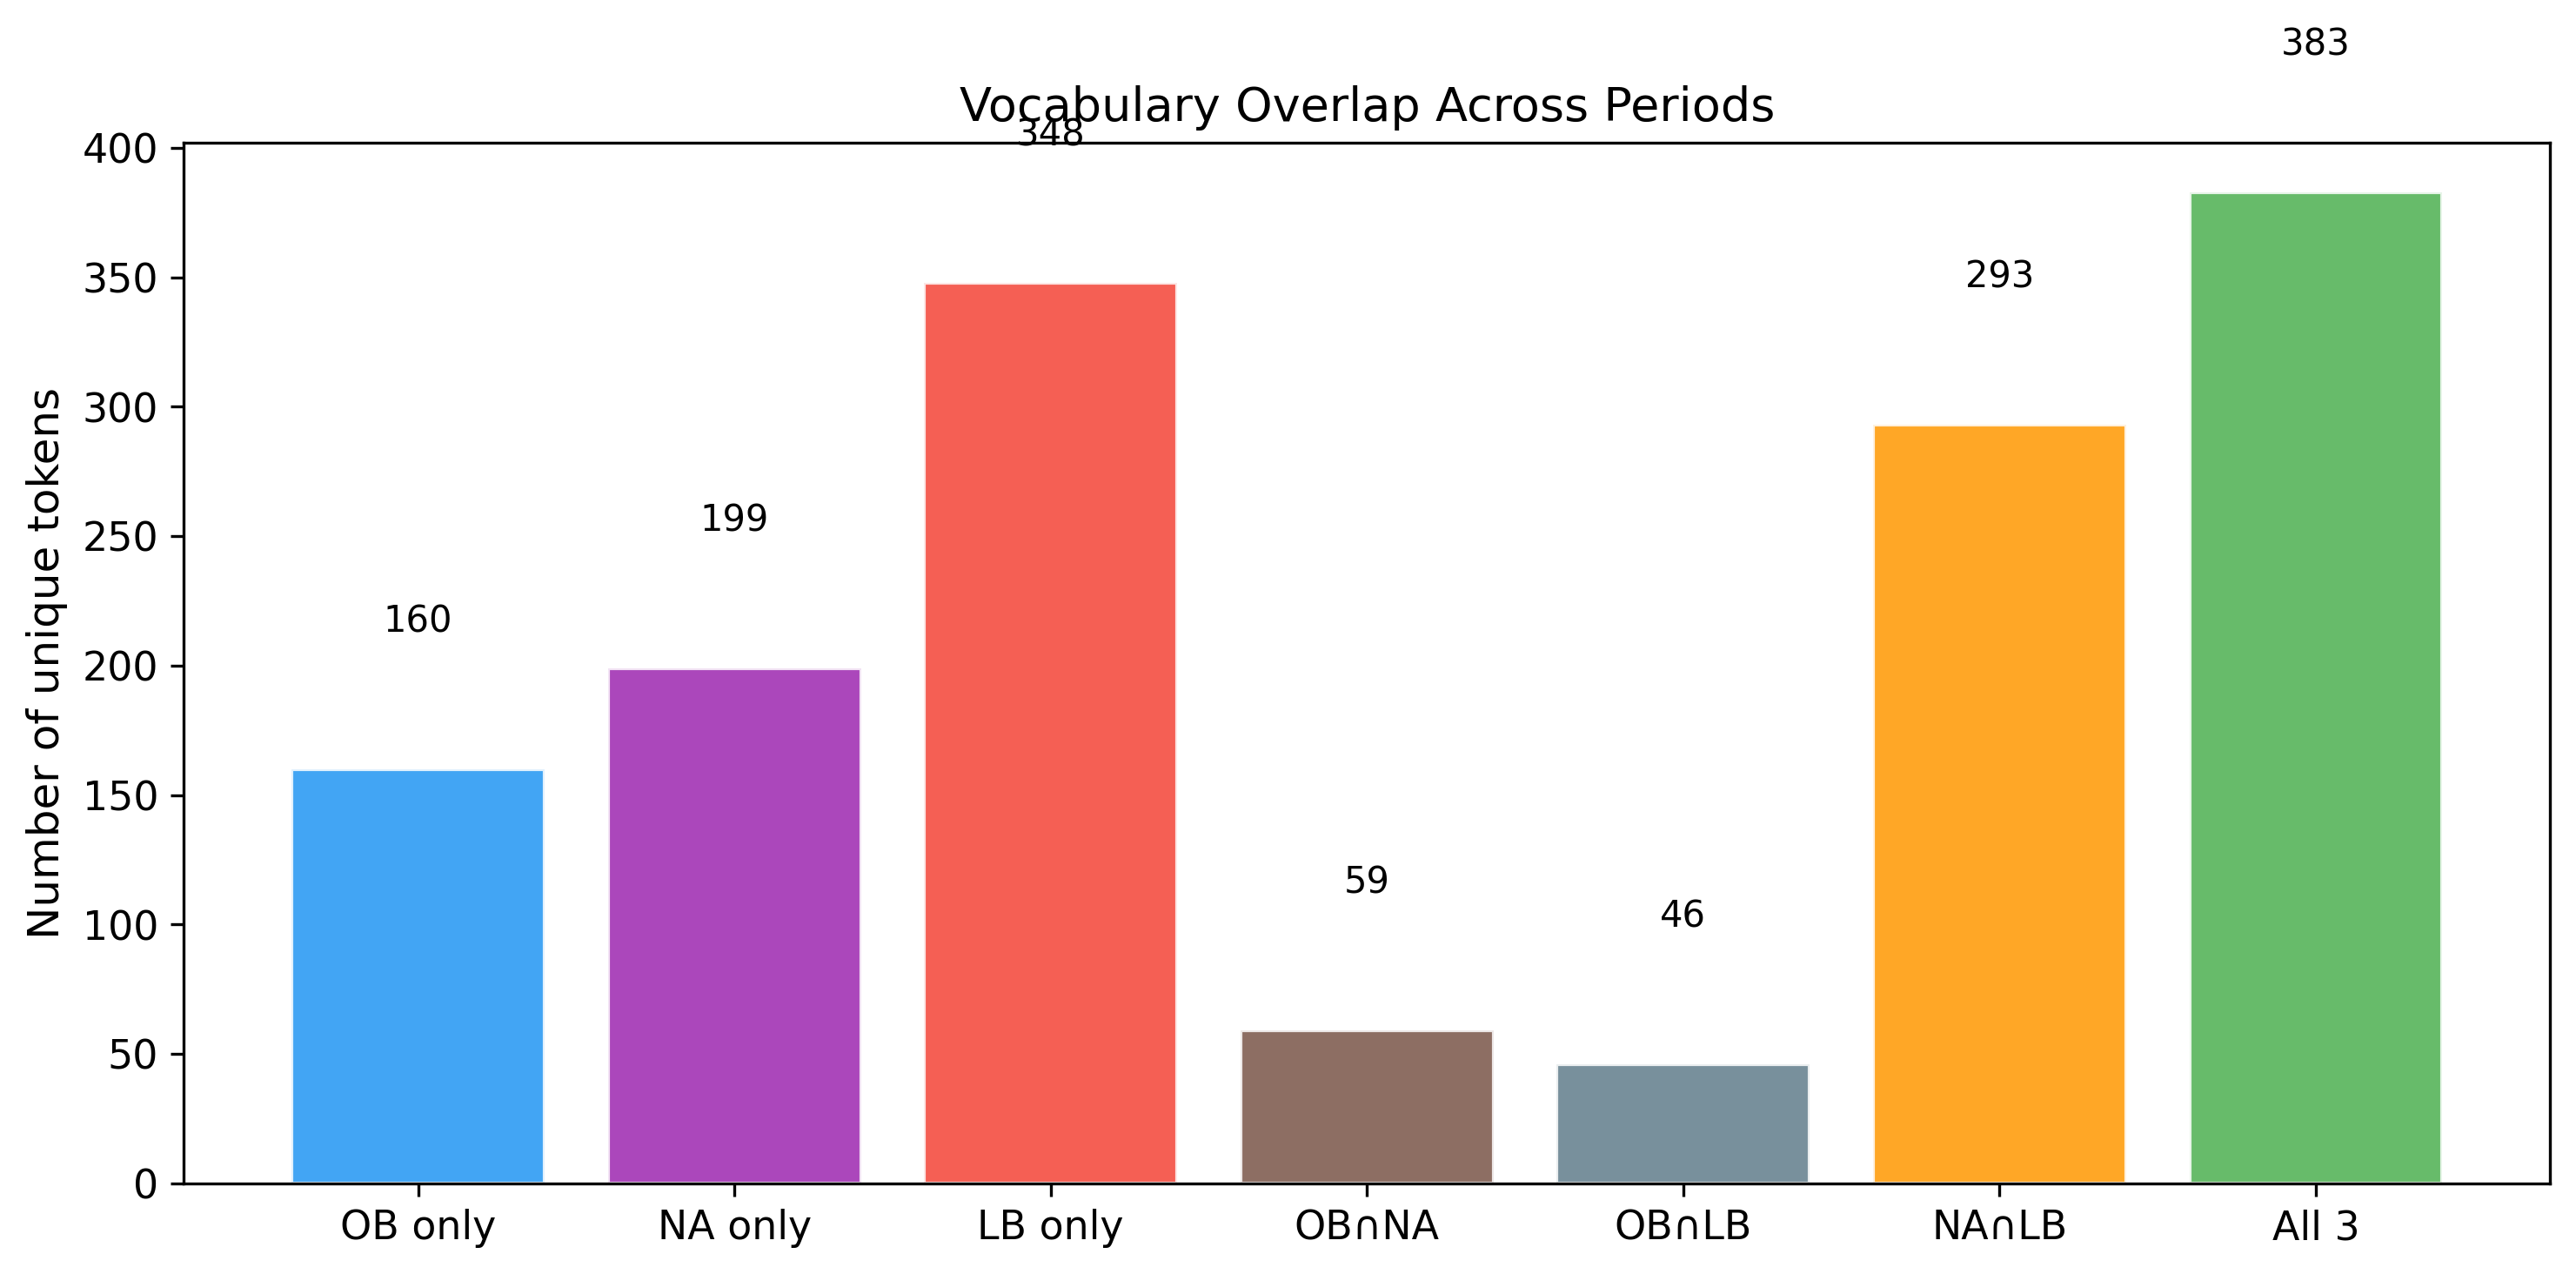

In [21]:
# Venn-like overlap visualization using a bar chart
ob_only  = vocabs["Old Babylonian"]  - vocabs["Neo-Assyrian"] - vocabs["Late Babylonian"]
na_only  = vocabs["Neo-Assyrian"]   - vocabs["Old Babylonian"] - vocabs["Late Babylonian"]
lb_only  = vocabs["Late Babylonian"] - vocabs["Old Babylonian"] - vocabs["Neo-Assyrian"]
ob_na    = (vocabs["Old Babylonian"] & vocabs["Neo-Assyrian"]) - vocabs["Late Babylonian"]
ob_lb    = (vocabs["Old Babylonian"] & vocabs["Late Babylonian"]) - vocabs["Neo-Assyrian"]
na_lb    = (vocabs["Neo-Assyrian"]   & vocabs["Late Babylonian"]) - vocabs["Old Babylonian"]
all_3    = triple

labels = ["OB only", "NA only", "LB only", "OB∩NA", "OB∩LB", "NA∩LB", "All 3"]
counts = [len(ob_only), len(na_only), len(lb_only),
          len(ob_na), len(ob_lb), len(na_lb), len(all_3)]
colors_bar = [PERIOD_COLORS["Old Babylonian"], PERIOD_COLORS["Neo-Assyrian"],
              PERIOD_COLORS["Late Babylonian"], "#795548", "#607D8B", "#FF9800", "#4CAF50"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, counts, color=colors_bar, alpha=0.85, edgecolor="white")
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"{count:,}", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Number of unique tokens")
ax.set_title("Vocabulary Overlap Across Periods")
plt.tight_layout()
plt.savefig(PLOT_DIR / "bias_vocab_overlap.png", bbox_inches="tight", dpi=300)
plt.show()

Exclusive token rate per period (fraction of tokens unique to that period):
                  count   mean    std  min    25%    50%    75%    max
period                                                                
Late Babylonian  1025.0  0.014  0.026  0.0  0.000  0.010  0.019  0.467
Neo-Assyrian     2435.0  0.012  0.019  0.0  0.000  0.007  0.017  0.500
Old Babylonian   1497.0  0.024  0.020  0.0  0.011  0.021  0.034  0.164


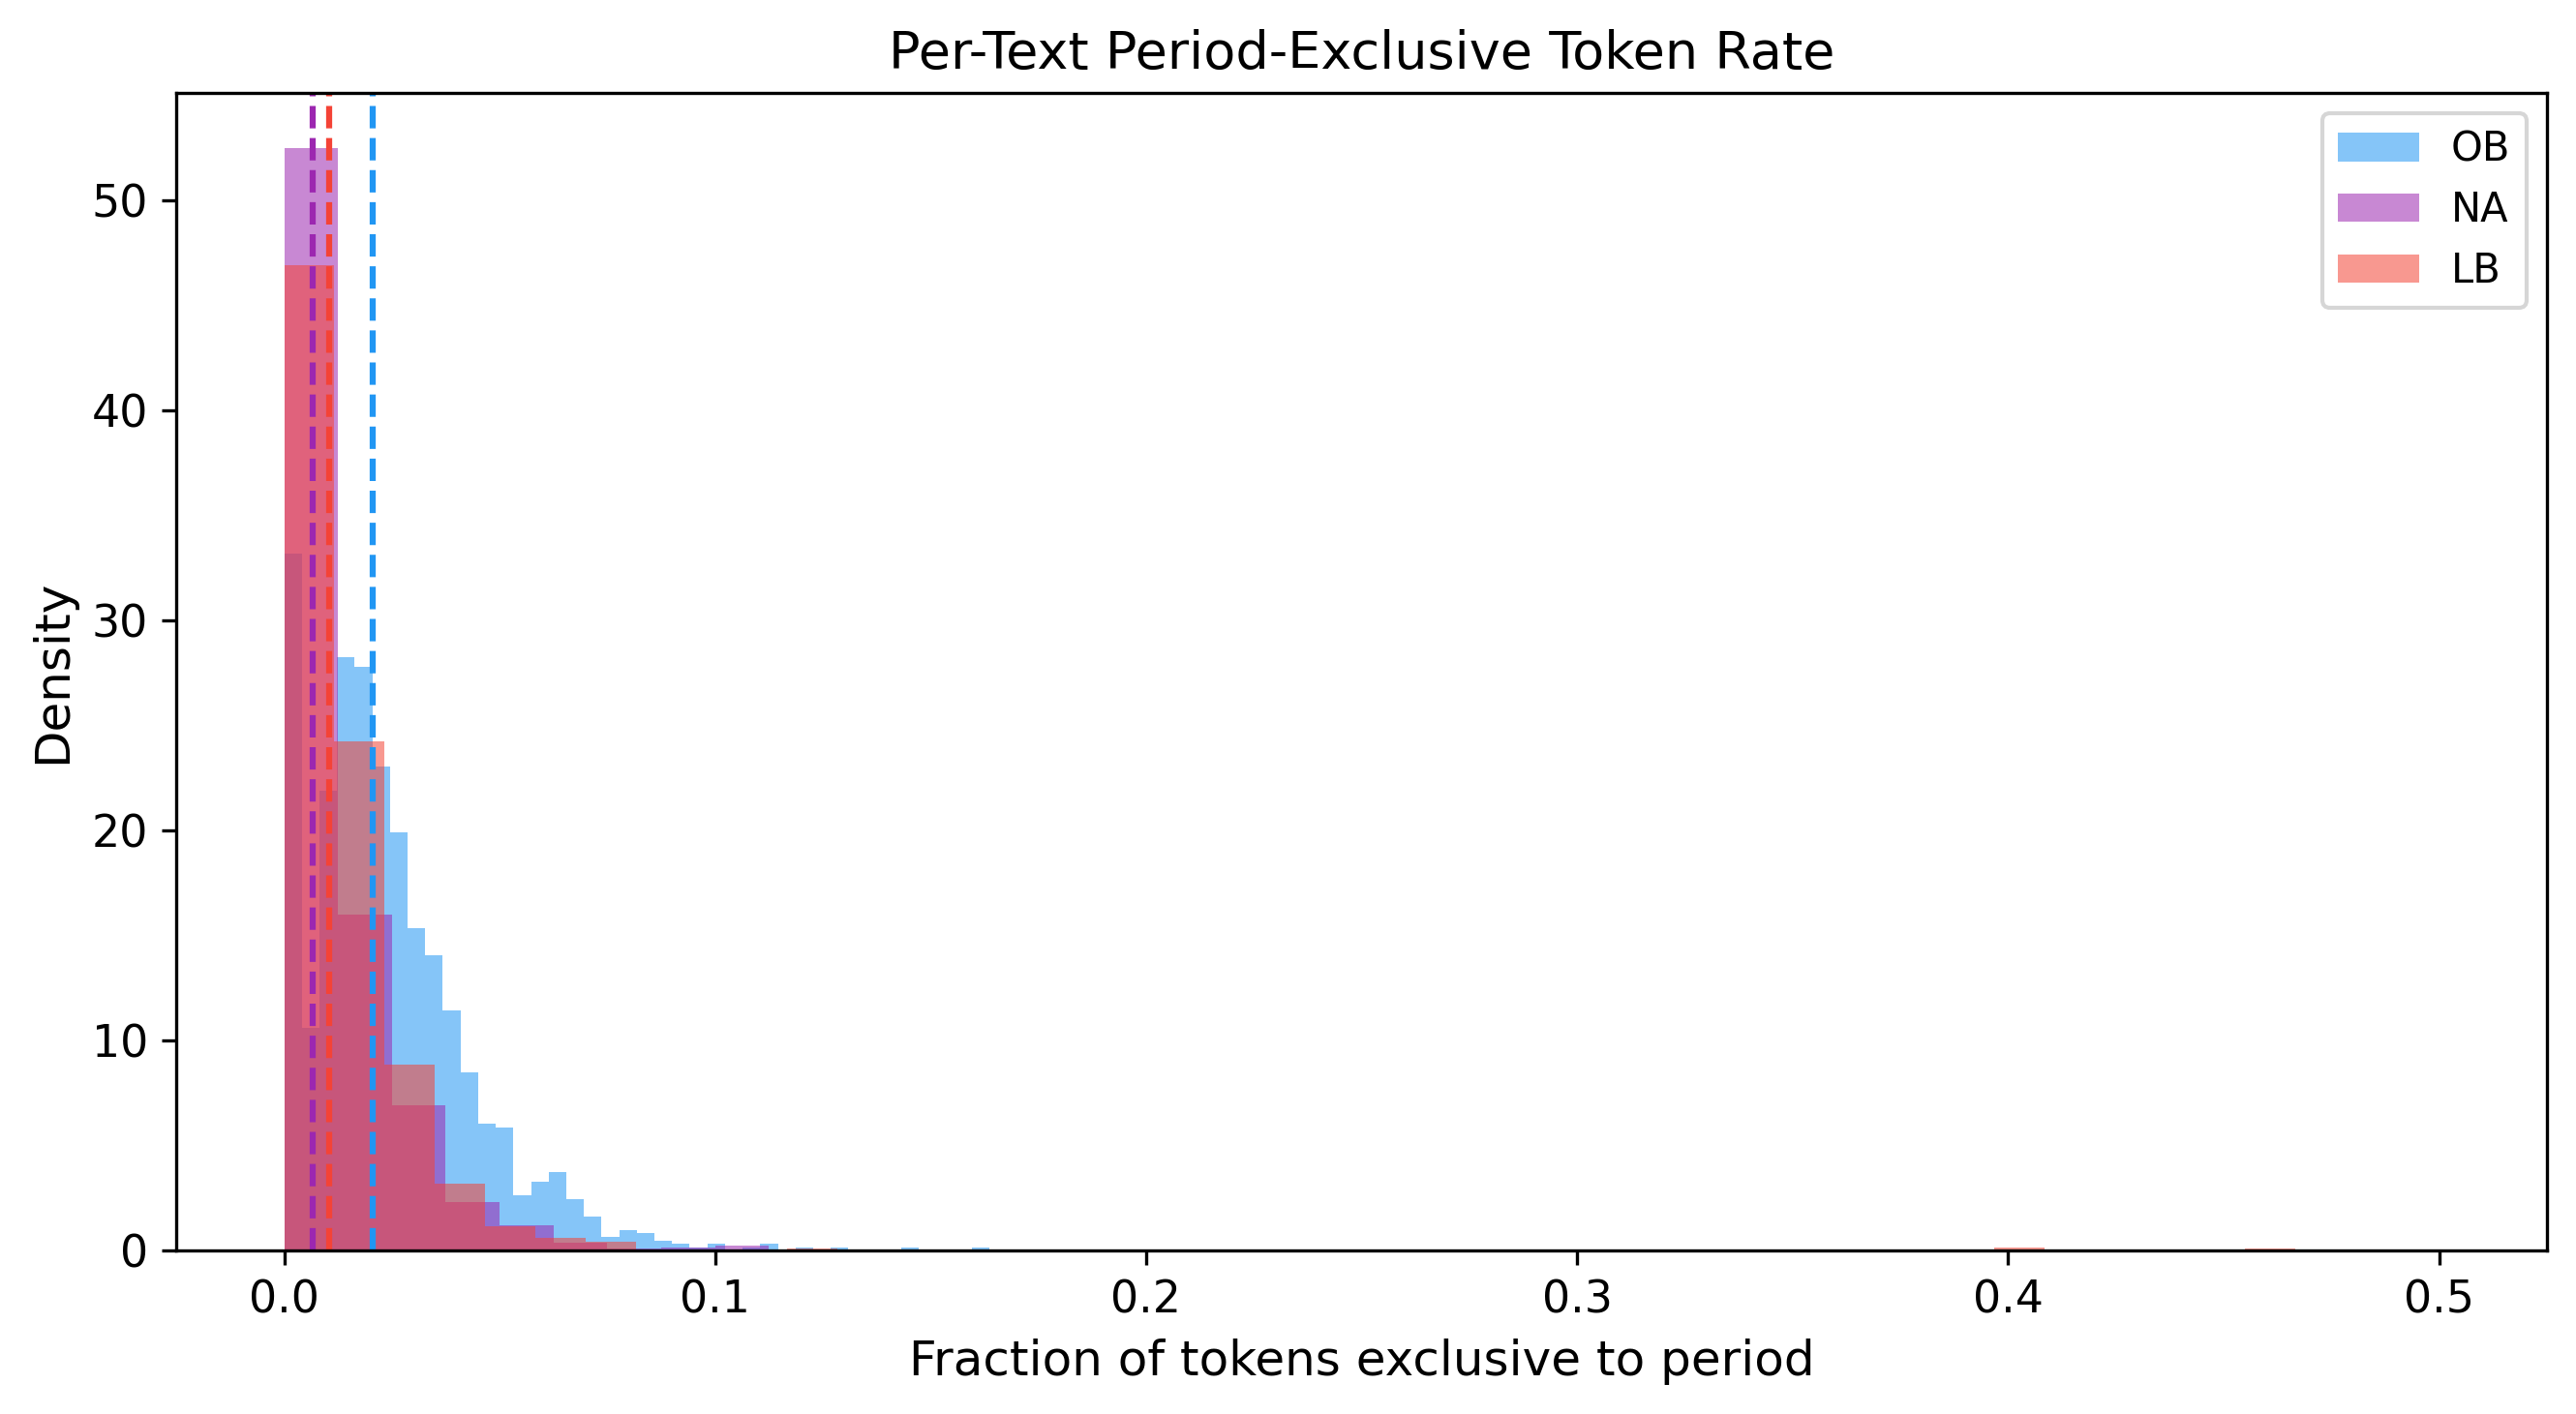

In [22]:
# What fraction of each text's tokens are period-exclusive?
exclusive_vocabs = {
    p: vocabs[p] - set.union(*[vocabs[q] for q in PERIODS if q != p])
    for p in PERIODS
}

def exclusive_token_rate(text, period):
    excl = exclusive_vocabs[period]
    tokens = re.findall(r'[a-zA-ZšṣṭḫāīūēŠṢṬḪĀĪŪĒ0-9]+', text.lower())
    if not tokens:
        return 0
    return sum(1 for t in tokens if t in excl) / len(tokens)

df["exclusive_token_rate"] = df.apply(
    lambda row: exclusive_token_rate(row["full_text"], row["period"]), axis=1
)

print("Exclusive token rate per period (fraction of tokens unique to that period):")
print(df.groupby("period")["exclusive_token_rate"].describe().round(3))

fig, ax = plt.subplots(figsize=(9, 5))
for p in PERIODS:
    vals = df[df.period == p]["exclusive_token_rate"]
    ax.hist(vals, bins=40, alpha=0.55, density=True,
            label=SHORT[p], color=PERIOD_COLORS[p])
    ax.axvline(vals.median(), color=PERIOD_COLORS[p], linestyle="--", lw=1.5)
ax.set_xlabel("Fraction of tokens exclusive to period")
ax.set_ylabel("Density")
ax.set_title("Per-Text Period-Exclusive Token Rate")
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "bias_exclusive_token_rate.png", bbox_inches="tight", dpi=300)
plt.show()

## 8. Logogram / Uppercase Ratio (Sumerian Logograms)

Sumerian logograms are written in UPPERCASE in transliteration (e.g. `LUGAL`, `GEME2`, `EN`). Different corpora and traditions use different proportions of phonetic vs. logographic writing. This is a strong corpus-convention signal.

In [23]:
# Extract uppercase tokens (logograms)
def extract_logograms(text):
    """Tokens that are fully uppercase (with optional digit suffix)."""
    return re.findall(r'\b[A-ZŠṢṬḪĀĪŪĒ][A-ZŠṢṬḪĀĪŪĒ0-9]+\b', text)

df["logograms"] = df["full_text"].apply(extract_logograms)
df["n_logograms"] = df["logograms"].apply(len)
df["logogram_rate"] = df["n_logograms"] / df["n_words"].clip(lower=1)

print("Logogram rate per period:")
print(df.groupby("period")["logogram_rate"].describe().round(3))

# Top logograms per period
for p in PERIODS:
    all_log = []
    for llist in df[df.period == p]["logograms"]:
        all_log.extend(llist)
    top = Counter(all_log).most_common(15)
    print(f"\n{p} — top 15 logograms: {[l for l, c in top]}")

Logogram rate per period:
                  count   mean    std  min    25%    50%   75%    max
period                                                               
Late Babylonian  1025.0  0.520  0.178  0.0  0.400  0.500  0.61  1.524
Neo-Assyrian     2435.0  0.440  0.169  0.0  0.333  0.426  0.53  1.600
Old Babylonian   1497.0  0.257  0.222  0.0  0.111  0.198  0.34  2.130

Old Babylonian — top 15 logograms: ['LU2', 'ŠA3', 'HI', 'IR3', 'UTU', 'DINGIR', 'DUMU', 'EN', 'IŠKUR', 'ZU', 'E2', 'UD', 'KU3', 'LUGAL', 'GAN2']

Neo-Assyrian — top 15 logograms: ['LUGAL', 'EN', 'UGU', 'ŠA3', 'ARAD', 'E2', 'KUR', 'UD', 'DI', 'TA', 'GAL', 'UTU', 'DUMU', 'DINGIR', 'PA']

Late Babylonian — top 15 logograms: ['EN', 'ŠEŠ', 'AG', 'MU', 'UTU', 'IM', 'TIN', 'ŠA3', 'E2', 'KU3', 'BABBAR', 'ŠE', 'II', 'BAR', 'NA']


In [24]:
# Which logograms are period-exclusive?
logogram_vocabs = {}
for p in PERIODS:
    all_log = []
    for llist in df[df.period == p]["logograms"]:
        all_log.extend(llist)
    logogram_vocabs[p] = Counter(all_log)

print("Period-exclusive logograms (top 30 by frequency):")
for p in PERIODS:
    others_logograms = set()
    for q in PERIODS:
        if q != p:
            others_logograms.update(logogram_vocabs[q].keys())
    excl = {k: v for k, v in logogram_vocabs[p].items() if k not in others_logograms}
    top_excl = sorted(excl.items(), key=lambda x: -x[1])[:30]
    print(f"\n{p} ({len(excl)} exclusive): {[l for l, c in top_excl]}")

Period-exclusive logograms (top 30 by frequency):

Old Babylonian (92 exclusive): ['NI3', 'ELAM', 'RE', 'ENSI2', 'ŠUKU', 'DIDLI', 'SA6', 'RA2', 'BANDA3', 'KAK', 'KISLAH', 'WA3', 'TIBIRA', 'TIŠPAK', 'TUL2', 'HA6', 'GIDRI', 'DURU5', 'AKŠAK', 'ŠUKUR', 'PIRIG', 'DU10', 'ŠUBUR', 'KUŠ7', 'TUM', 'LAMMA', 'SE3', 'PEŠ', 'ILLURU', 'BARA3']

Neo-Assyrian (94 exclusive): ['KUG', 'GUD', 'ṢU', 'QAR', 'BARAG', 'ALAD', 'LAMA', 'LUL', 'BALA', 'BUR2', 'DAGAL', 'GISKIM', 'NIGIR2', 'ERIN', 'SA5', 'QAL3', 'DUL', 'KU2', 'MAR2', 'NIGIR', 'MUD2', 'MIN', 'KIŠ', 'UŠ11', 'BIR', 'BIR4', 'ZAH2', 'IZI', 'ŠAB', 'LUH']

Late Babylonian (162 exclusive): ['URU3', 'ŠUK', 'SIK2', 'UMBISAG', 'ZIMBIR', 'LIM', 'KU4', 'EDEN', 'UZ', 'TRACES', 'RIG7', 'SEAL', 'GARIM', 'GISSU', 'IT', 'GIL', 'KAD2', 'PEŠ3', 'ILA2', 'ŠES', 'GEŠTUG', 'ŠA2', 'DANNA', 'ŠIM', 'HAD2', 'TABLET', 'IA', 'ID', 'LAK', 'UBARA']


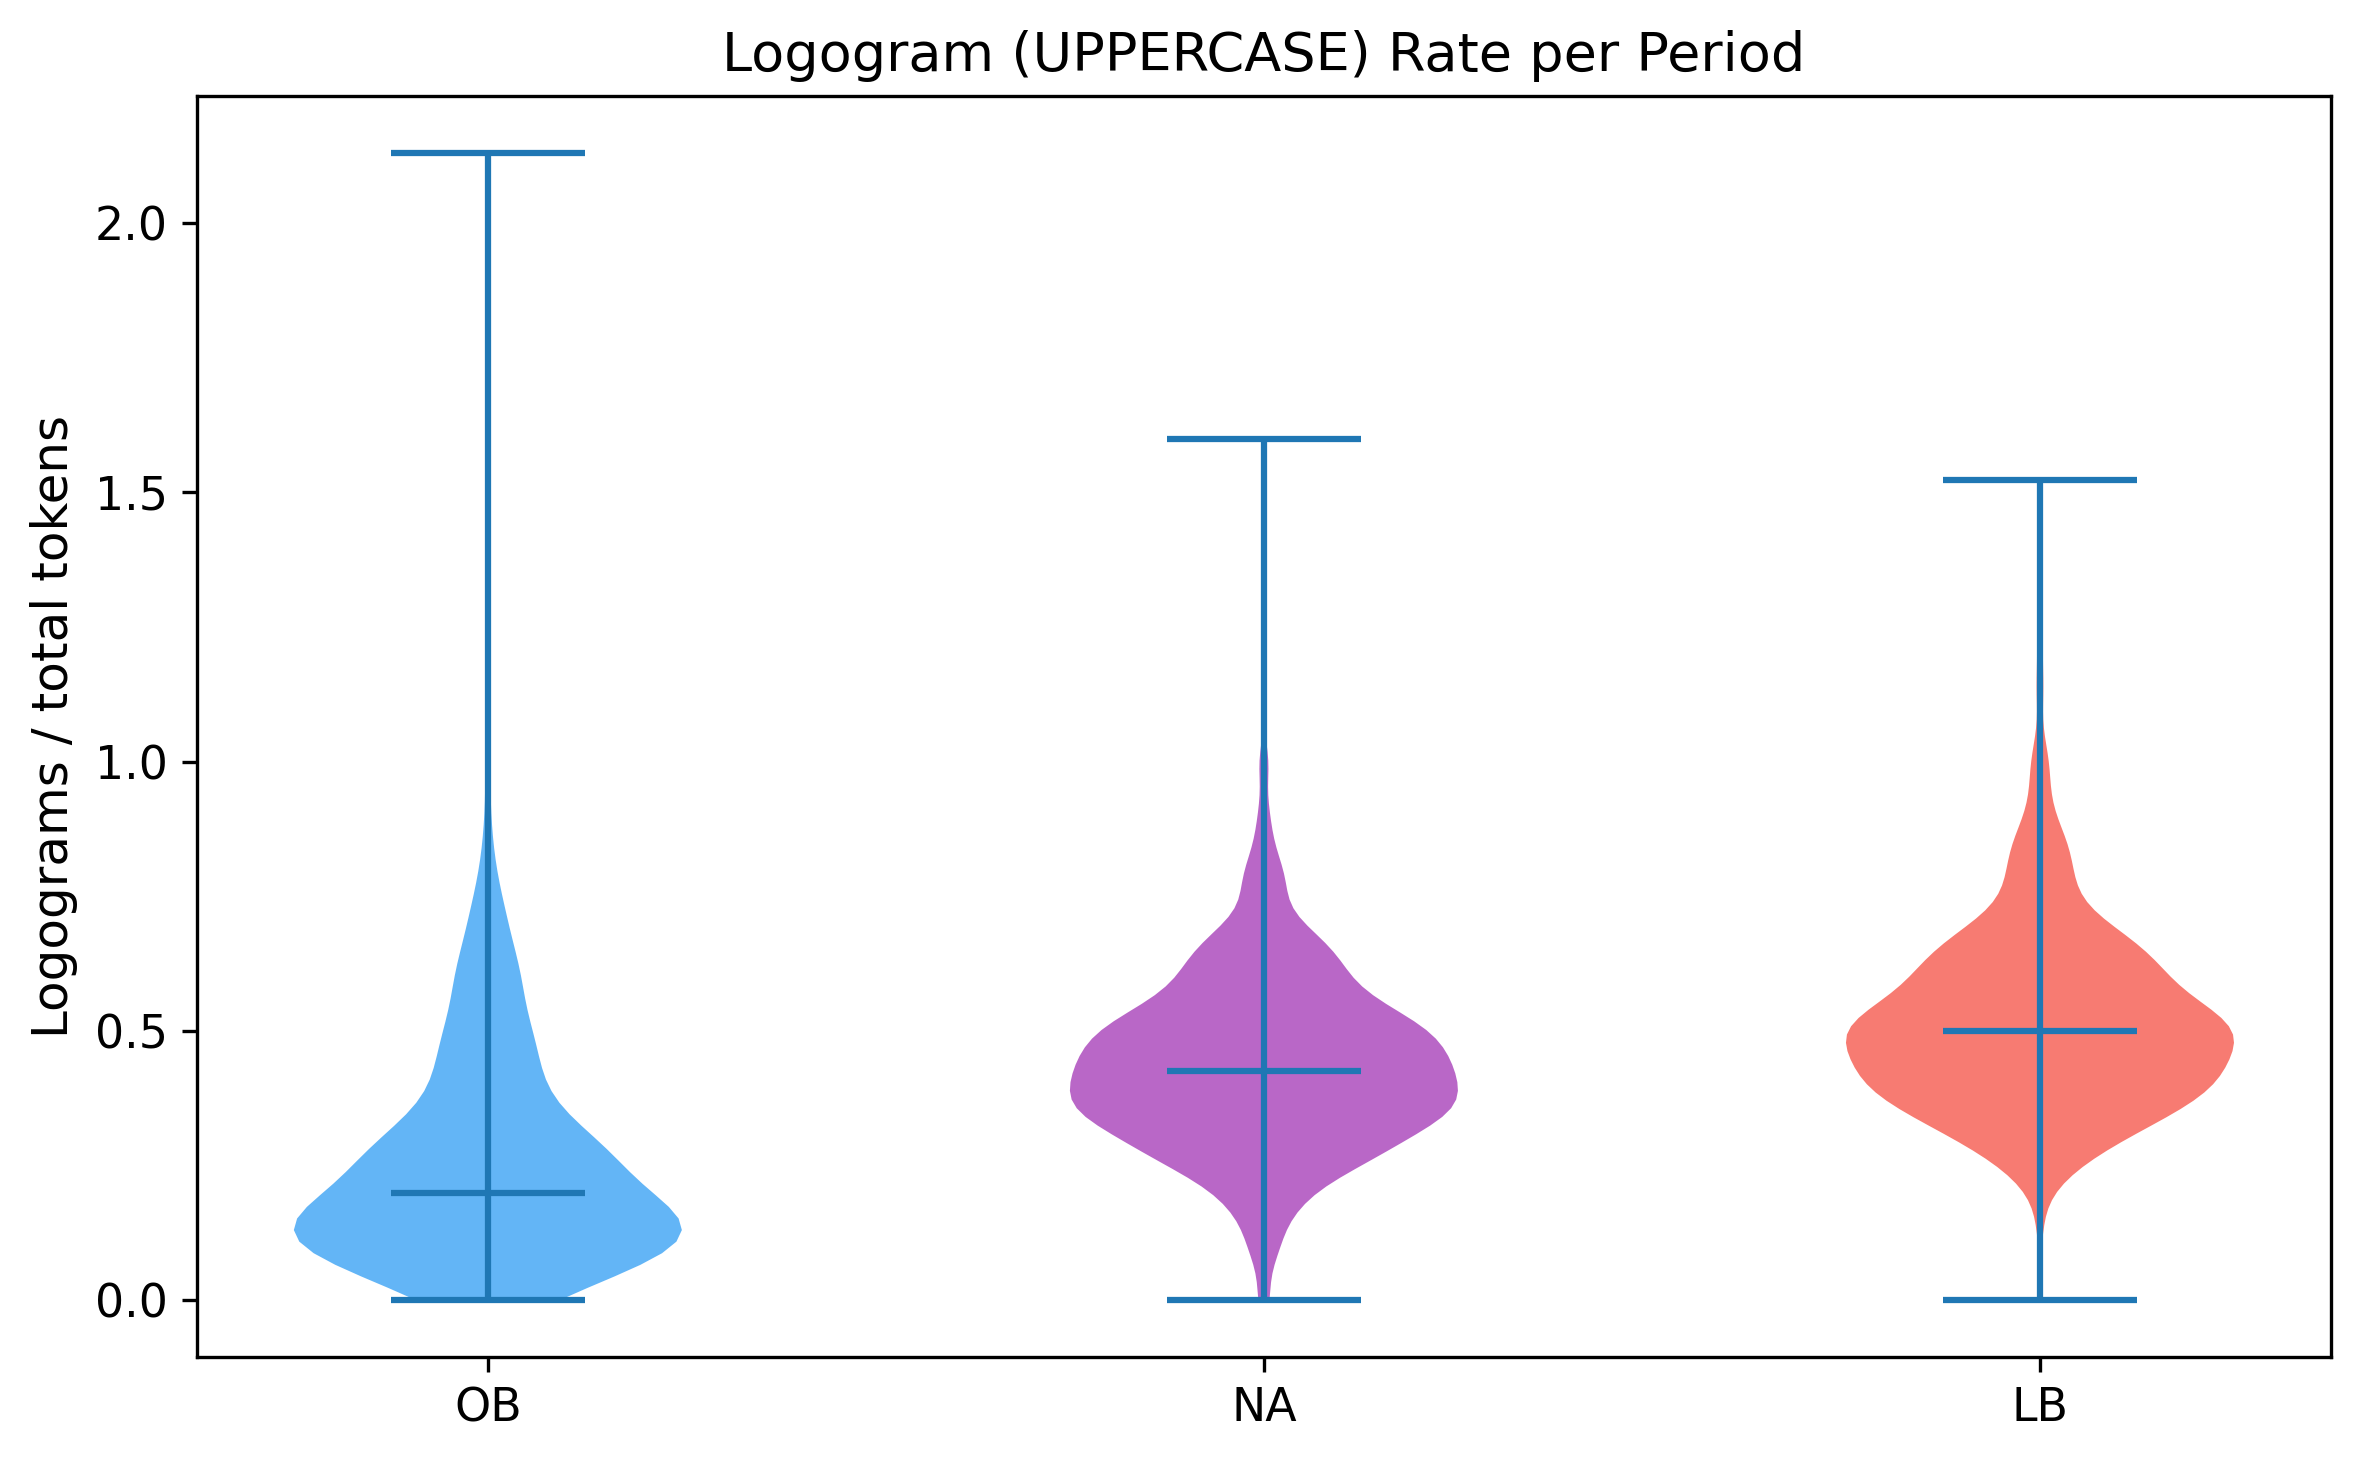

In [25]:
# Logogram rate violin plot
fig, ax = plt.subplots(figsize=(8, 5))
data = [df[df.period == p]["logogram_rate"].values for p in PERIODS]
vp = ax.violinplot(data, positions=[1, 2, 3], showmedians=True)
for pc, p in zip(vp["bodies"], PERIODS):
    pc.set_facecolor(PERIOD_COLORS[p])
    pc.set_alpha(0.7)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels([SHORT[p] for p in PERIODS])
ax.set_ylabel("Logograms / total tokens")
ax.set_title("Logogram (UPPERCASE) Rate per Period")
plt.tight_layout()
plt.savefig(PLOT_DIR / "bias_logogram_rate.png", bbox_inches="tight", dpi=300)
plt.show()

## 9. Summary: Ranked Bias Sources

Consolidate all findings into a ranked table of bias sources.

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

# Build a feature matrix from all the hand-crafted features above
feature_cols = char_cols + ["logogram_rate", "subscript_rate", "exclusive_token_rate",
                            "n_chars", "n_words", "n_lines", "avg_word_len"]

X_hand = df[feature_cols].fillna(0).values
le = LabelEncoder()
y_enc = le.fit_transform(df["period"])

# Simple logistic regression — coefficient magnitude tells us feature importance
lr = LogisticRegression(max_iter=1000, C=1.0, multi_class="multinomial")
lr.fit(X_hand, y_enc)
print(f"Logistic regression accuracy (all hand-crafted features): {lr.score(X_hand, y_enc):.3f}")
print("(In-sample, but shows how separable the hand-crafted features are alone)")

/opt/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic regression accuracy (all hand-crafted features): 0.805
(In-sample, but shows how separable the hand-crafted features are alone)


/opt/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


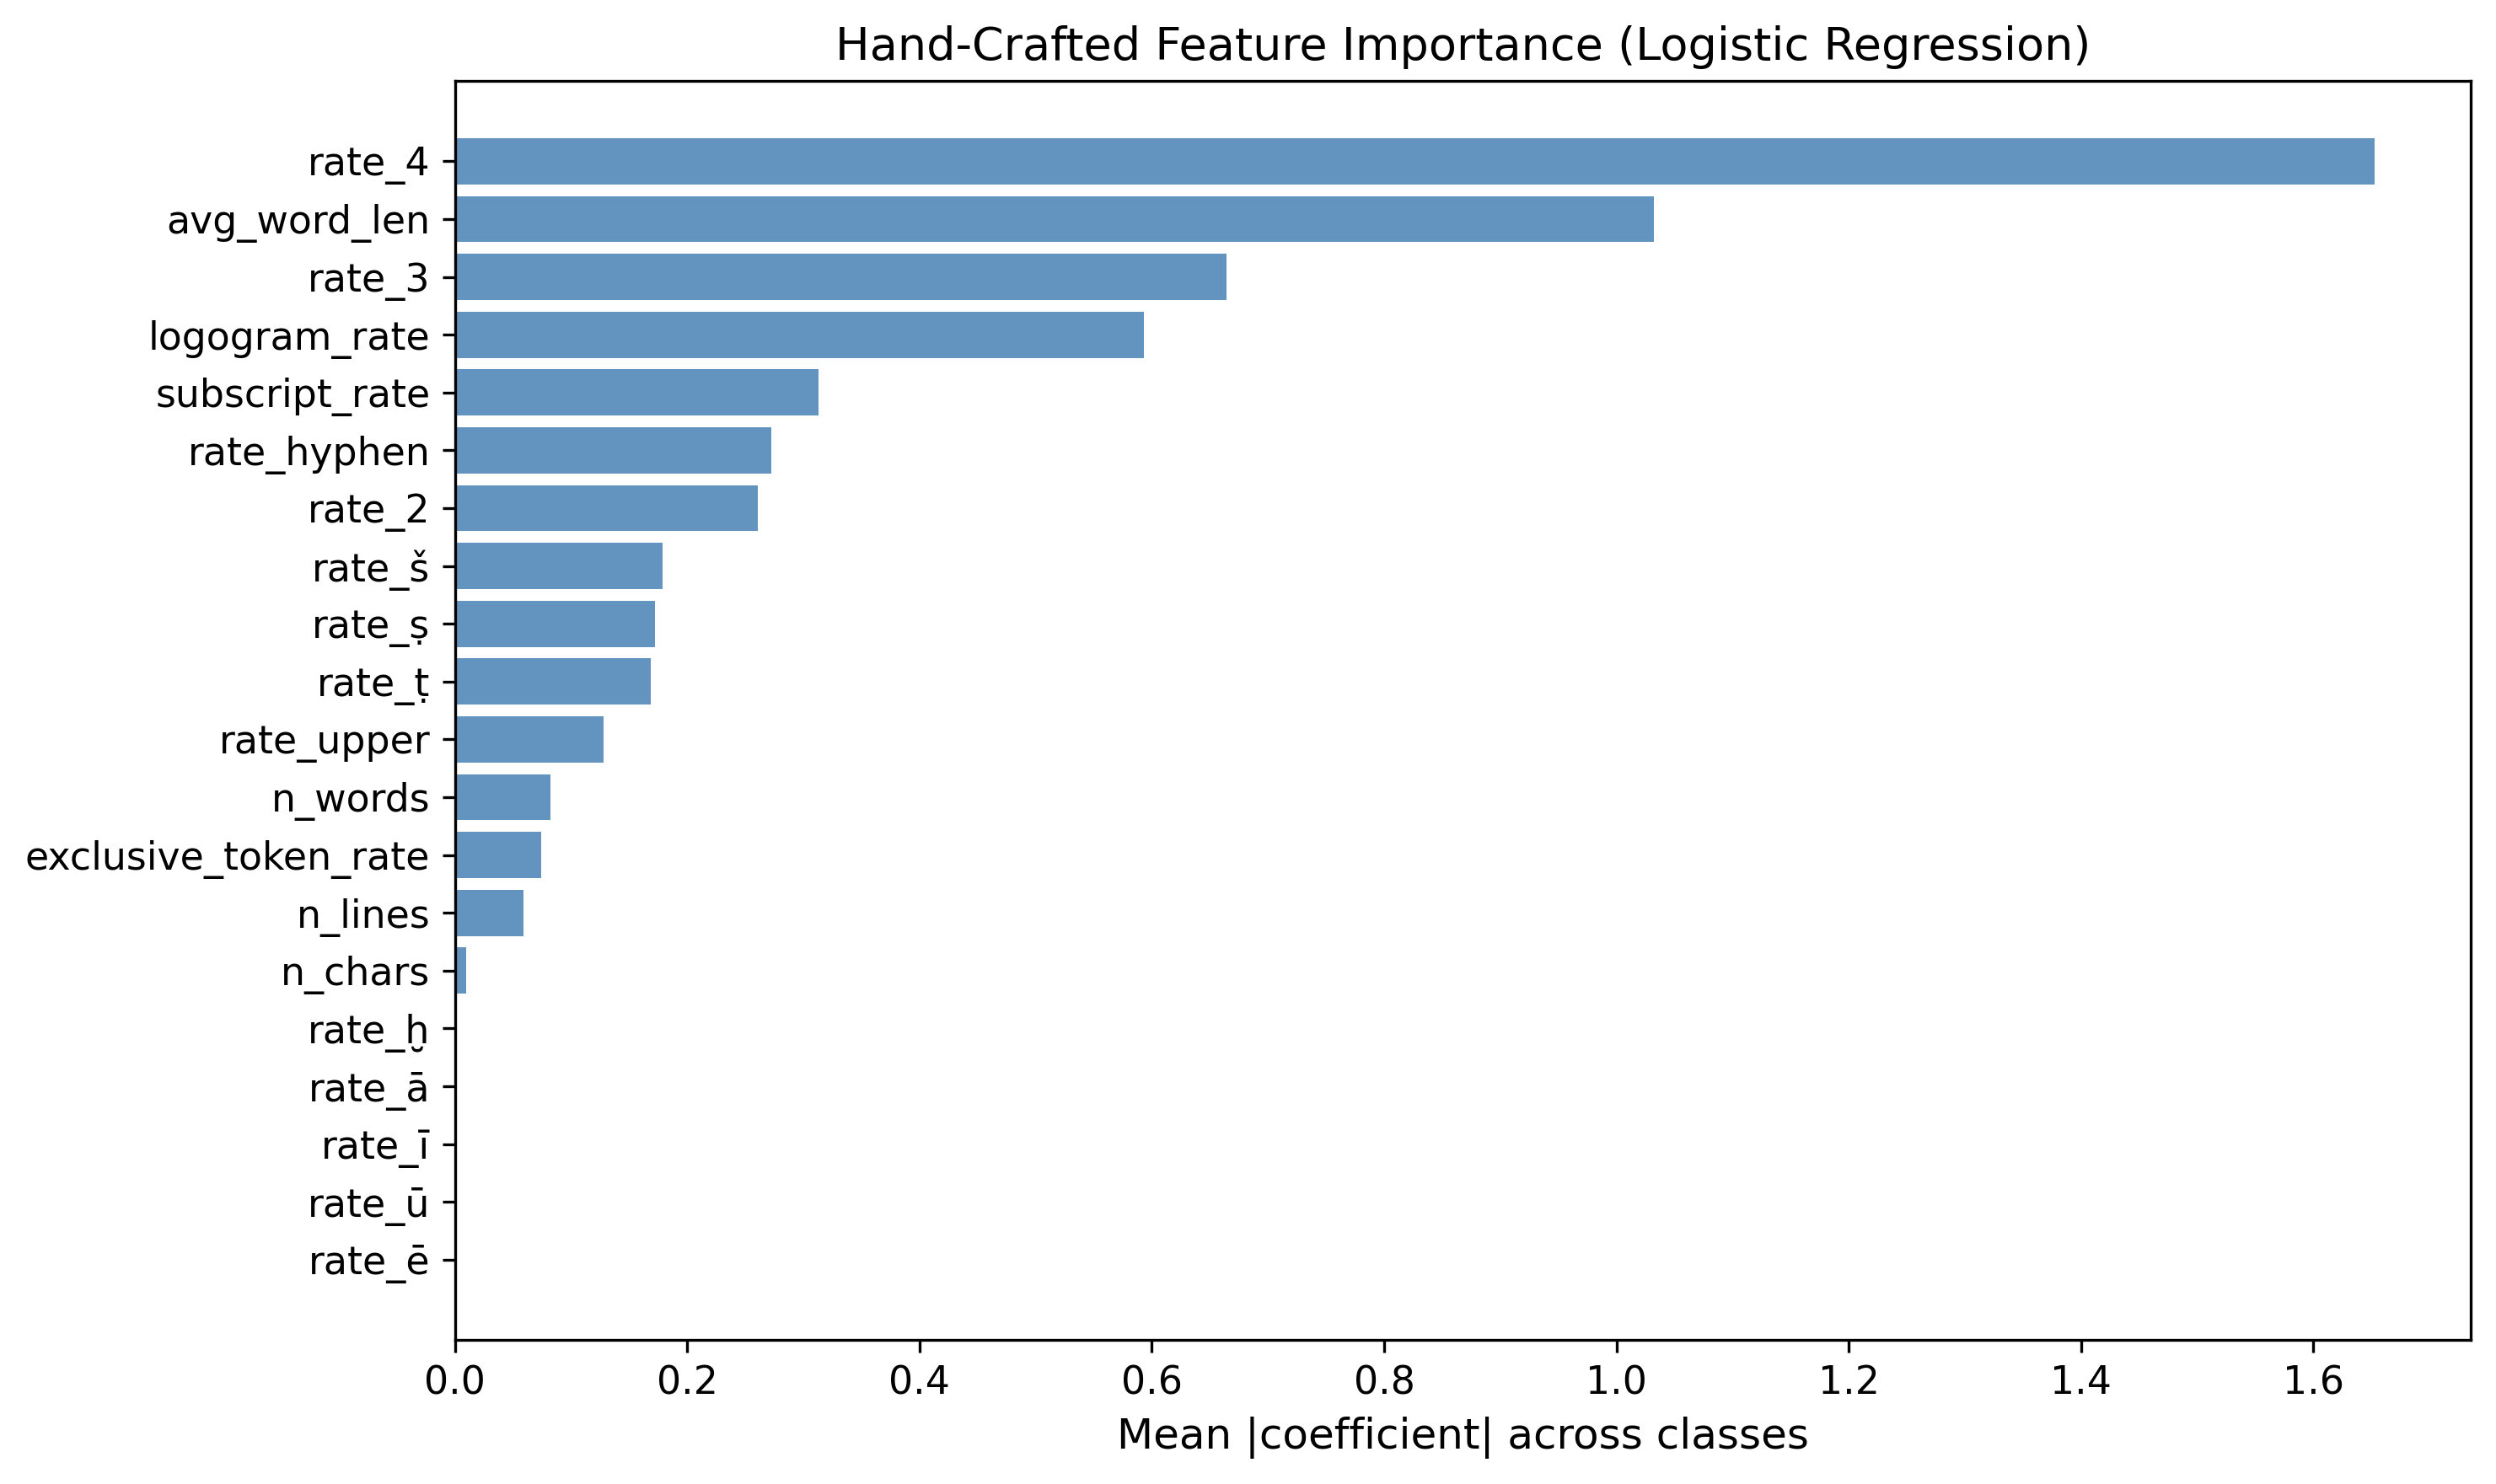


Ranked features:
   1. rate_4                               importance=1.6529
   2. avg_word_len                         importance=1.0323
   3. rate_3                               importance=0.6641
   4. logogram_rate                        importance=0.5929
   5. subscript_rate                       importance=0.3128
   6. rate_hyphen                          importance=0.2728
   7. rate_2                               importance=0.2605
   8. rate_š                               importance=0.1786
   9. rate_ṣ                               importance=0.1720
  10. rate_ṭ                               importance=0.1684
  11. rate_upper                           importance=0.1283
  12. n_words                              importance=0.0824
  13. exclusive_token_rate                 importance=0.0741
  14. n_lines                              importance=0.0587
  15. n_chars                              importance=0.0099
  16. rate_ḫ                               importance=0.0000
  17. 

In [27]:
# Feature importance from LR coefficients
coef_abs = np.abs(lr.coef_).mean(axis=0)  # average absolute coef across classes
importance = sorted(zip(feature_cols, coef_abs), key=lambda x: -x[1])

fig, ax = plt.subplots(figsize=(10, 6))
feat_names = [f for f, _ in importance]
feat_scores = [s for _, s in importance]
ax.barh(feat_names[::-1], feat_scores[::-1], color="steelblue", alpha=0.85)
ax.set_xlabel("Mean |coefficient| across classes")
ax.set_title("Hand-Crafted Feature Importance (Logistic Regression)")
plt.tight_layout()
plt.savefig(PLOT_DIR / "bias_feature_importance.png", bbox_inches="tight", dpi=300)
plt.show()

print("\nRanked features:")
for i, (feat, score) in enumerate(importance):
    print(f"  {i+1:2d}. {feat:<35s}  importance={score:.4f}")

In [28]:
# Final summary table — how well can each single feature type separate periods?
from sklearn.model_selection import cross_val_score

print("Single-feature-group cross-validated accuracy (5-fold, LR):")
print(f"{'Feature group':<40s}  {'CV acc mean':>12s}  {'±std':>8s}")
print("-" * 65)

feature_groups = {
    "Char diacritics (š,ṣ,ṭ,ḫ,ā,ī,ū,ē)": [f"rate_{c}" for c in "šṣṭḫāīūē"],
    "Number subscripts (2,3,4)": [f"rate_{c}" for c in ["2", "3", "4"]],
    "Uppercase (logogram) rate": ["rate_upper"],
    "Logogram rate": ["logogram_rate"],
    "Subscript token rate": ["subscript_rate"],
    "Exclusive token rate": ["exclusive_token_rate"],
    "Text length (chars,words,lines)": ["n_chars", "n_words", "n_lines"],
    "All hand-crafted features": feature_cols,
}

for group_name, cols in feature_groups.items():
    X_g = df[cols].fillna(0).values
    scores = cross_val_score(LogisticRegression(max_iter=500, C=1.0), X_g, y_enc, cv=5, scoring="accuracy")
    print(f"{group_name:<40s}  {scores.mean():>12.3f}  ±{scores.std():>6.3f}")

Single-feature-group cross-validated accuracy (5-fold, LR):
Feature group                              CV acc mean      ±std
-----------------------------------------------------------------
Char diacritics (š,ṣ,ṭ,ḫ,ā,ī,ū,ē)                0.538  ± 0.024
Number subscripts (2,3,4)                        0.604  ± 0.032
Uppercase (logogram) rate                        0.646  ± 0.047
Logogram rate                                    0.622  ± 0.044
Subscript token rate                             0.531  ± 0.022
Exclusive token rate                             0.500  ± 0.012


Text length (chars,words,lines)                  0.597  ± 0.024


/opt/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_i

/opt/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_i

All hand-crafted features                        0.779  ± 0.027


/opt/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [29]:
# ── Final Summary ─────────────────────────────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════════════╗
║               BIAS ANALYSIS SUMMARY                                  ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  PRIMARY CAUSE (structural):                                         ║
║  corpus_source is a PERFECT proxy for period.                        ║
║    archibab → Old Babylonian  (100%)                                 ║
║    oracc    → Neo-Assyrian    (100%)                                 ║
║    lbl      → Late Babylonian (100%)                                 ║
║  Different corpora have different house styles, markup conventions,  ║
║  and transcription traditions. Char n-grams capture these directly.  ║
║                                                                      ║
║  SECONDARY CAUSES (linguistic/orthographic):                         ║
║  1. Diacritic frequencies (š,ṣ,ṭ,ḫ,long vowels) differ by corpus   ║
║  2. Number subscript conventions differ by corpus tradition          ║
║  3. Logogram (UPPERCASE) usage ratio differs by period+corpus        ║
║  4. Text length distributions differ across corpora                  ║
║  5. Period-exclusive vocabulary (even shared content words differ)   ║
║  6. Discovery site & publication series perfectly encode period      ║
║                                                                      ║
║  RECOMMENDATION:                                                     ║
║  For a fair LLM evaluation, either:                                  ║
║  (a) Mix corpora within each period so corpus ≠ period, OR          ║
║  (b) Normalize transliteration conventions before featurizing, OR   ║
║  (c) Report corpus-source bias explicitly as a limitation with       ║
║      controlled within-corpus experiments.                           ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║               BIAS ANALYSIS SUMMARY                                  ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  PRIMARY CAUSE (structural):                                         ║
║  corpus_source is a PERFECT proxy for period.                        ║
║    archibab → Old Babylonian  (100%)                                 ║
║    oracc    → Neo-Assyrian    (100%)                                 ║
║    lbl      → Late Babylonian (100%)                                 ║
║  Different corpora have different house styles, markup conventions,  ║
║  and transcription traditions. Char n-grams capture these directly.  ║
║                                                                      ║
║  SECONDARY CAUSES (linguistic/orthographic):                         ║
║  1. Diacritic frequencies (š,ṣ,ṭ,ḫ,long vowels) 

## 10. Cleaning Ablation Experiments

Can we reduce classifier accuracy by progressively cleaning the text?

Two experiments:
- **2-5 gram** (original TF-IDF setting, 10,000 features) — captures syllable combinations and morphology
- **Unigram** (single characters, ~40 features) — captures only individual character frequencies

Each cleaning filter is applied on top of a minimal baseline (tier0 = strip `@v` markup, non-breaking space, `ₓ`).

**Sample text**: `I-d-AG-NIG2 TA@v lu2-ARAD-meš ša2-al-tim a-wa-rum ṭe4-em-šu ūmī`

In [30]:
# ── 10a. Define cleaning filters with examples ──────────────────────────────

from sklearn.linear_model import LogisticRegression as LR
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder as LE
from sklearn.feature_extraction.text import TfidfVectorizer

le_abl = LE()
y_abl = le_abl.fit_transform(df['period'])

def clean_tier0(t):
    """Minimal: strip ORACC @v markup, non-breaking space, subscript-x."""
    t = re.sub(r'@[a-z0-9]+', '', t)
    t = t.replace('\xa0', ' ')
    t = t.replace('\u2093', '')  # ₓ
    return t

SAMPLE = 'I-d-AG-NIG2 TA@v lu2-ARAD-meš ša2-al-tim a-wa-rum ṭe4-em-šu ūmī'

FILTERS = {
    'strip ALL digits':
        lambda t: re.sub(r'[0-9]', '', t),
    'truncate 30 tokens':
        lambda t: ' '.join(t.split()[:30]),
    'strip case endings (-am,-im,-um,-tam,-tim,-šum)':
        lambda t: re.sub(r'-(am|im|um|tam|tim|šum)\b', '', t),
    'strip w/y':
        lambda t: t.replace('w', '').replace('y', ''),
    'remove logograms (ALL UPPERCASE tokens)':
        lambda t: re.sub(r'\b[A-ZŠṢṬḪ][A-ZŠṢṬḪ0-9]+-?', '', t),
    'strip determinatives (I-,d-,lu2-,uru-,giš-,tug2-)':
        lambda t: re.sub(r'\b(I|d|lu2|uru|giš|tug2)-', '', t),
    'keep only syllabic tokens':
        lambda t: ' '.join(re.findall(r'[a-zšṣṭḫāīūē][a-zšṣṭḫāīūē0-9-]*', t)),
    'normalize long vowels (ā→a etc)':
        lambda t: t.translate(str.maketrans('āīūēĀĪŪĒ', 'aiueAIUE')),
    'strip subscript digits (sign2→sign)':
        lambda t: re.sub(r'([a-zšṣṭḫ])([2-9])', r'\1', t),
    'lowercase':
        lambda t: t.lower(),
    'strip -meš plural':
        lambda t: re.sub(r'-meš\b', '', t),
}

# Show what each filter does to the sample
tier0_sample = clean_tier0(SAMPLE)
print(f'Original:       {SAMPLE}')
print(f'After tier0:    {tier0_sample}')
print()
for name, fn in FILTERS.items():
    print(f'  {name}')
    print(f'    → {fn(tier0_sample)}')
    print()


Original:       I-d-AG-NIG2 TA@v lu2-ARAD-meš ša2-al-tim a-wa-rum ṭe4-em-šu ūmī
After tier0:    I-d-AG-NIG2 TA lu2-ARAD-meš ša2-al-tim a-wa-rum ṭe4-em-šu ūmī

  strip ALL digits
    → I-d-AG-NIG TA lu-ARAD-meš ša-al-tim a-wa-rum ṭe-em-šu ūmī

  truncate 30 tokens
    → I-d-AG-NIG2 TA lu2-ARAD-meš ša2-al-tim a-wa-rum ṭe4-em-šu ūmī

  strip case endings (-am,-im,-um,-tam,-tim,-šum)
    → I-d-AG-NIG2 TA lu2-ARAD-meš ša2-al a-wa-rum ṭe4-em-šu ūmī

  strip w/y
    → I-d-AG-NIG2 TA lu2-ARAD-meš ša2-al-tim a-a-rum ṭe4-em-šu ūmī

  remove logograms (ALL UPPERCASE tokens)
    → I-d-  lu2-meš ša2-al-tim a-wa-rum ṭe4-em-šu ūmī

  strip determinatives (I-,d-,lu2-,uru-,giš-,tug2-)
    → AG-NIG2 TA ARAD-meš ša2-al-tim a-wa-rum ṭe4-em-šu ūmī

  keep only syllabic tokens
    → d- lu2- meš ša2-al-tim a-wa-rum ṭe4-em-šu ūmī

  normalize long vowels (ā→a etc)
    → I-d-AG-NIG2 TA lu2-ARAD-meš ša2-al-tim a-wa-rum ṭe4-em-šu umi

  strip subscript digits (sign2→sign)
    → I-d-AG-NIG2 TA lu-ARAD-meš ša-al-t

In [31]:
# ── 10b. Individual filter ranking (each alone on top of tier0) ─────────────

base_texts = df['full_text'].apply(clean_tier0)

all_filters = {'baseline (tier0 only)': lambda t: t}
all_filters.update(FILTERS)

for ngram_label, ngram_range in [('UNIGRAM (1,1)', (1,1)), ('BIGRAM (2,2)', (2,2)), ('2-5 GRAM (2,5)', (2,5))]:
    print(f'\n{"="*70}')
    print(f'Individual filters — {ngram_label}')
    print(f'{"="*70}')
    results = []
    for name, fn in all_filters.items():
        cleaned = base_texts.apply(fn)
        vec = TfidfVectorizer(analyzer='char_wb', ngram_range=ngram_range,
                              max_features=10000, sublinear_tf=True)
        X = vec.fit_transform(cleaned)
        scores = cross_val_score(LR(max_iter=500), X, y_abl, cv=5)
        results.append((name, scores.mean(), scores.std(), X.shape[1]))
    results.sort(key=lambda x: -x[1])
    baseline_acc = [r[1] for r in results if 'baseline' in r[0]][0]
    print(f'  {"Filter":<55s}  {"Acc":>8s}  {"Drop":>7s}  {"Feats":>5s}')
    print('  ' + '-'*80)
    for name, acc, std, feats in results:
        drop = baseline_acc - acc
        print(f'  {name:<55s}  {acc:.3f}±{std:.3f}  {drop:+.3f}  {feats:>5d}')



Individual filters — UNIGRAM (1,1)


  Filter                                                        Acc     Drop  Feats
  --------------------------------------------------------------------------------
  strip -meš plural                                        0.859±0.019  -0.012     41
  remove logograms (ALL UPPERCASE tokens)                  0.857±0.021  -0.010     41
  keep only syllabic tokens                                0.848±0.022  -0.001     39
  baseline (tier0 only)                                    0.848±0.021  +0.000     41
  normalize long vowels (ā→a etc)                          0.848±0.021  +0.000     41
  lowercase                                                0.848±0.021  +0.000     41
  strip determinatives (I-,d-,lu2-,uru-,giš-,tug2-)        0.844±0.026  +0.004     41
  strip w/y                                                0.837±0.021  +0.011     41
  strip case endings (-am,-im,-um,-tam,-tim,-šum)          0.835±0.024  +0.013     41
  truncate 30 tokens                                       

  Filter                                                        Acc     Drop  Feats
  --------------------------------------------------------------------------------
  strip determinatives (I-,d-,lu2-,uru-,giš-,tug2-)        0.984±0.006  -0.001    533
  strip w/y                                                0.984±0.006  -0.000    523
  baseline (tier0 only)                                    0.983±0.007  +0.000    533
  normalize long vowels (ā→a etc)                          0.983±0.007  +0.000    533
  lowercase                                                0.983±0.007  +0.000    533
  strip -meš plural                                        0.983±0.007  +0.000    533
  strip case endings (-am,-im,-um,-tam,-tim,-šum)          0.982±0.006  +0.001    533
  strip subscript digits (sign2→sign)                      0.977±0.011  +0.007    503
  strip ALL digits                                         0.976±0.011  +0.007    368
  truncate 30 tokens                                       

  Filter                                                        Acc     Drop  Feats
  --------------------------------------------------------------------------------
  baseline (tier0 only)                                    0.992±0.005  +0.000  10000
  strip determinatives (I-,d-,lu2-,uru-,giš-,tug2-)        0.992±0.005  +0.000  10000
  normalize long vowels (ā→a etc)                          0.992±0.005  +0.000  10000
  lowercase                                                0.992±0.005  +0.000  10000
  strip w/y                                                0.992±0.006  +0.000  10000
  strip -meš plural                                        0.992±0.006  +0.000  10000
  strip case endings (-am,-im,-um,-tam,-tim,-šum)          0.991±0.006  +0.001  10000
  strip subscript digits (sign2→sign)                      0.990±0.006  +0.002  10000
  strip ALL digits                                         0.990±0.007  +0.002  10000
  truncate 30 tokens                                       

In [32]:
# ── 10c. Greedy stacking — 2-5 grams ───────────────────────────────────────

def run_greedy_stack(base_texts, y, ngram_range, label):
    print(f'\n{"="*75}')
    print(f'GREEDY STACKING — {label}')
    print(f'{"="*75}')
    remaining = dict(FILTERS)
    current_texts = base_texts.copy()
    vec = TfidfVectorizer(analyzer='char_wb', ngram_range=ngram_range,
                          max_features=10000, sublinear_tf=True)
    X = vec.fit_transform(current_texts)
    scores = cross_val_score(LR(max_iter=500), X, y, cv=5)
    base_acc = scores.mean()
    prev_acc = base_acc
    print(f'\n  {"Step":<3s}  {"Added filter":<50s}  {"Acc":>10s}  {"Δ prev":>8s}  {"Δ base":>8s}  {"feats":>5s}')
    print('  ' + '-'*90)
    print(f'  {0:<3d}  {"(tier0 baseline)":<50s}  {scores.mean():.3f}±{scores.std():.3f}  {"+0.000":>8s}  {"+0.000":>8s}  {X.shape[1]:>5d}')
    history = []
    for step in range(len(remaining)):
        best_name, best_acc, best_texts, best_std, best_feats = None, 1.0, None, 0, 0
        for name, fn in remaining.items():
            trial = current_texts.apply(fn)
            vec = TfidfVectorizer(analyzer='char_wb', ngram_range=ngram_range,
                                  max_features=10000, sublinear_tf=True)
            X = vec.fit_transform(trial)
            sc = cross_val_score(LR(max_iter=500), X, y, cv=5)
            if sc.mean() < best_acc:
                best_name, best_acc, best_texts = name, sc.mean(), trial
                best_std, best_feats = sc.std(), X.shape[1]
        del remaining[best_name]
        current_texts = best_texts
        dp = best_acc - prev_acc
        db = best_acc - base_acc
        print(f'  {step+1:<3d}  {best_name:<50s}  {best_acc:.3f}±{best_std:.3f}  {dp:>+8.3f}  {db:>+8.3f}  {best_feats:>5d}')
        history.append((step+1, best_name, best_acc, best_std, dp, db, best_feats))
        prev_acc = best_acc
    return base_acc, history

base_texts = df['full_text'].apply(clean_tier0)
base_25, hist_25 = run_greedy_stack(base_texts, y_abl, (2,5), '2-5 GRAMS')



GREEDY STACKING — 2-5 GRAMS



  Step  Added filter                                               Acc    Δ prev    Δ base  feats
  ------------------------------------------------------------------------------------------
  0    (tier0 baseline)                                    0.992±0.005    +0.000    +0.000  10000


  1    keep only syllabic tokens                           0.981±0.023    -0.011    -0.011  10000


  2    truncate 30 tokens                                  0.974±0.032    -0.007    -0.018  10000


  3    strip determinatives (I-,d-,lu2-,uru-,giš-,tug2-)   0.972±0.034    -0.002    -0.020  10000


...

  7    normalize long vowels (ā→a etc)                     0.967±0.033    +0.000    -0.025  10000


  8    lowercase                                           0.967±0.033    +0.000    -0.025  10000


  9    strip w/y                                           0.967±0.031    +0.001    -0.024  10000


  10   strip -meš plural                                   0.967±0.031    -0.000    -0.025  10000


  11   strip ALL digits                                    0.968±0.030    +0.001    -0.024  10000


In [33]:
# ── 10d. Greedy stacking — unigrams & bigrams ──────────────────────────────

base_texts = df['full_text'].apply(clean_tier0)
base_11, hist_11 = run_greedy_stack(base_texts, y_abl, (1,1), 'UNIGRAMS (1,1)')

base_texts = df['full_text'].apply(clean_tier0)
base_22, hist_22 = run_greedy_stack(base_texts, y_abl, (2,2), 'BIGRAMS (2,2)')



GREEDY STACKING — UNIGRAMS (1,1)



  Step  Added filter                                               Acc    Δ prev    Δ base  feats
  ------------------------------------------------------------------------------------------
  0    (tier0 baseline)                                    0.848±0.021    +0.000    +0.000     41


  1    strip ALL digits                                    0.796±0.030    -0.051    -0.051     31


  2    truncate 30 tokens                                  0.777±0.016    -0.020    -0.071     31


  3    strip case endings (-am,-im,-um,-tam,-tim,-šum)     0.758±0.017    -0.019    -0.090     31


...

  7    strip -meš plural                                   0.912±0.044    -0.001    -0.072    273


  8    remove logograms (ALL UPPERCASE tokens)             0.912±0.044    +0.000    -0.072    273


  9    normalize long vowels (ā→a etc)                     0.912±0.044    +0.000    -0.072    273


  10   strip subscript digits (sign2→sign)                 0.912±0.044    +0.000    -0.072    273


  11   lowercase                                           0.912±0.044    +0.000    -0.072    273


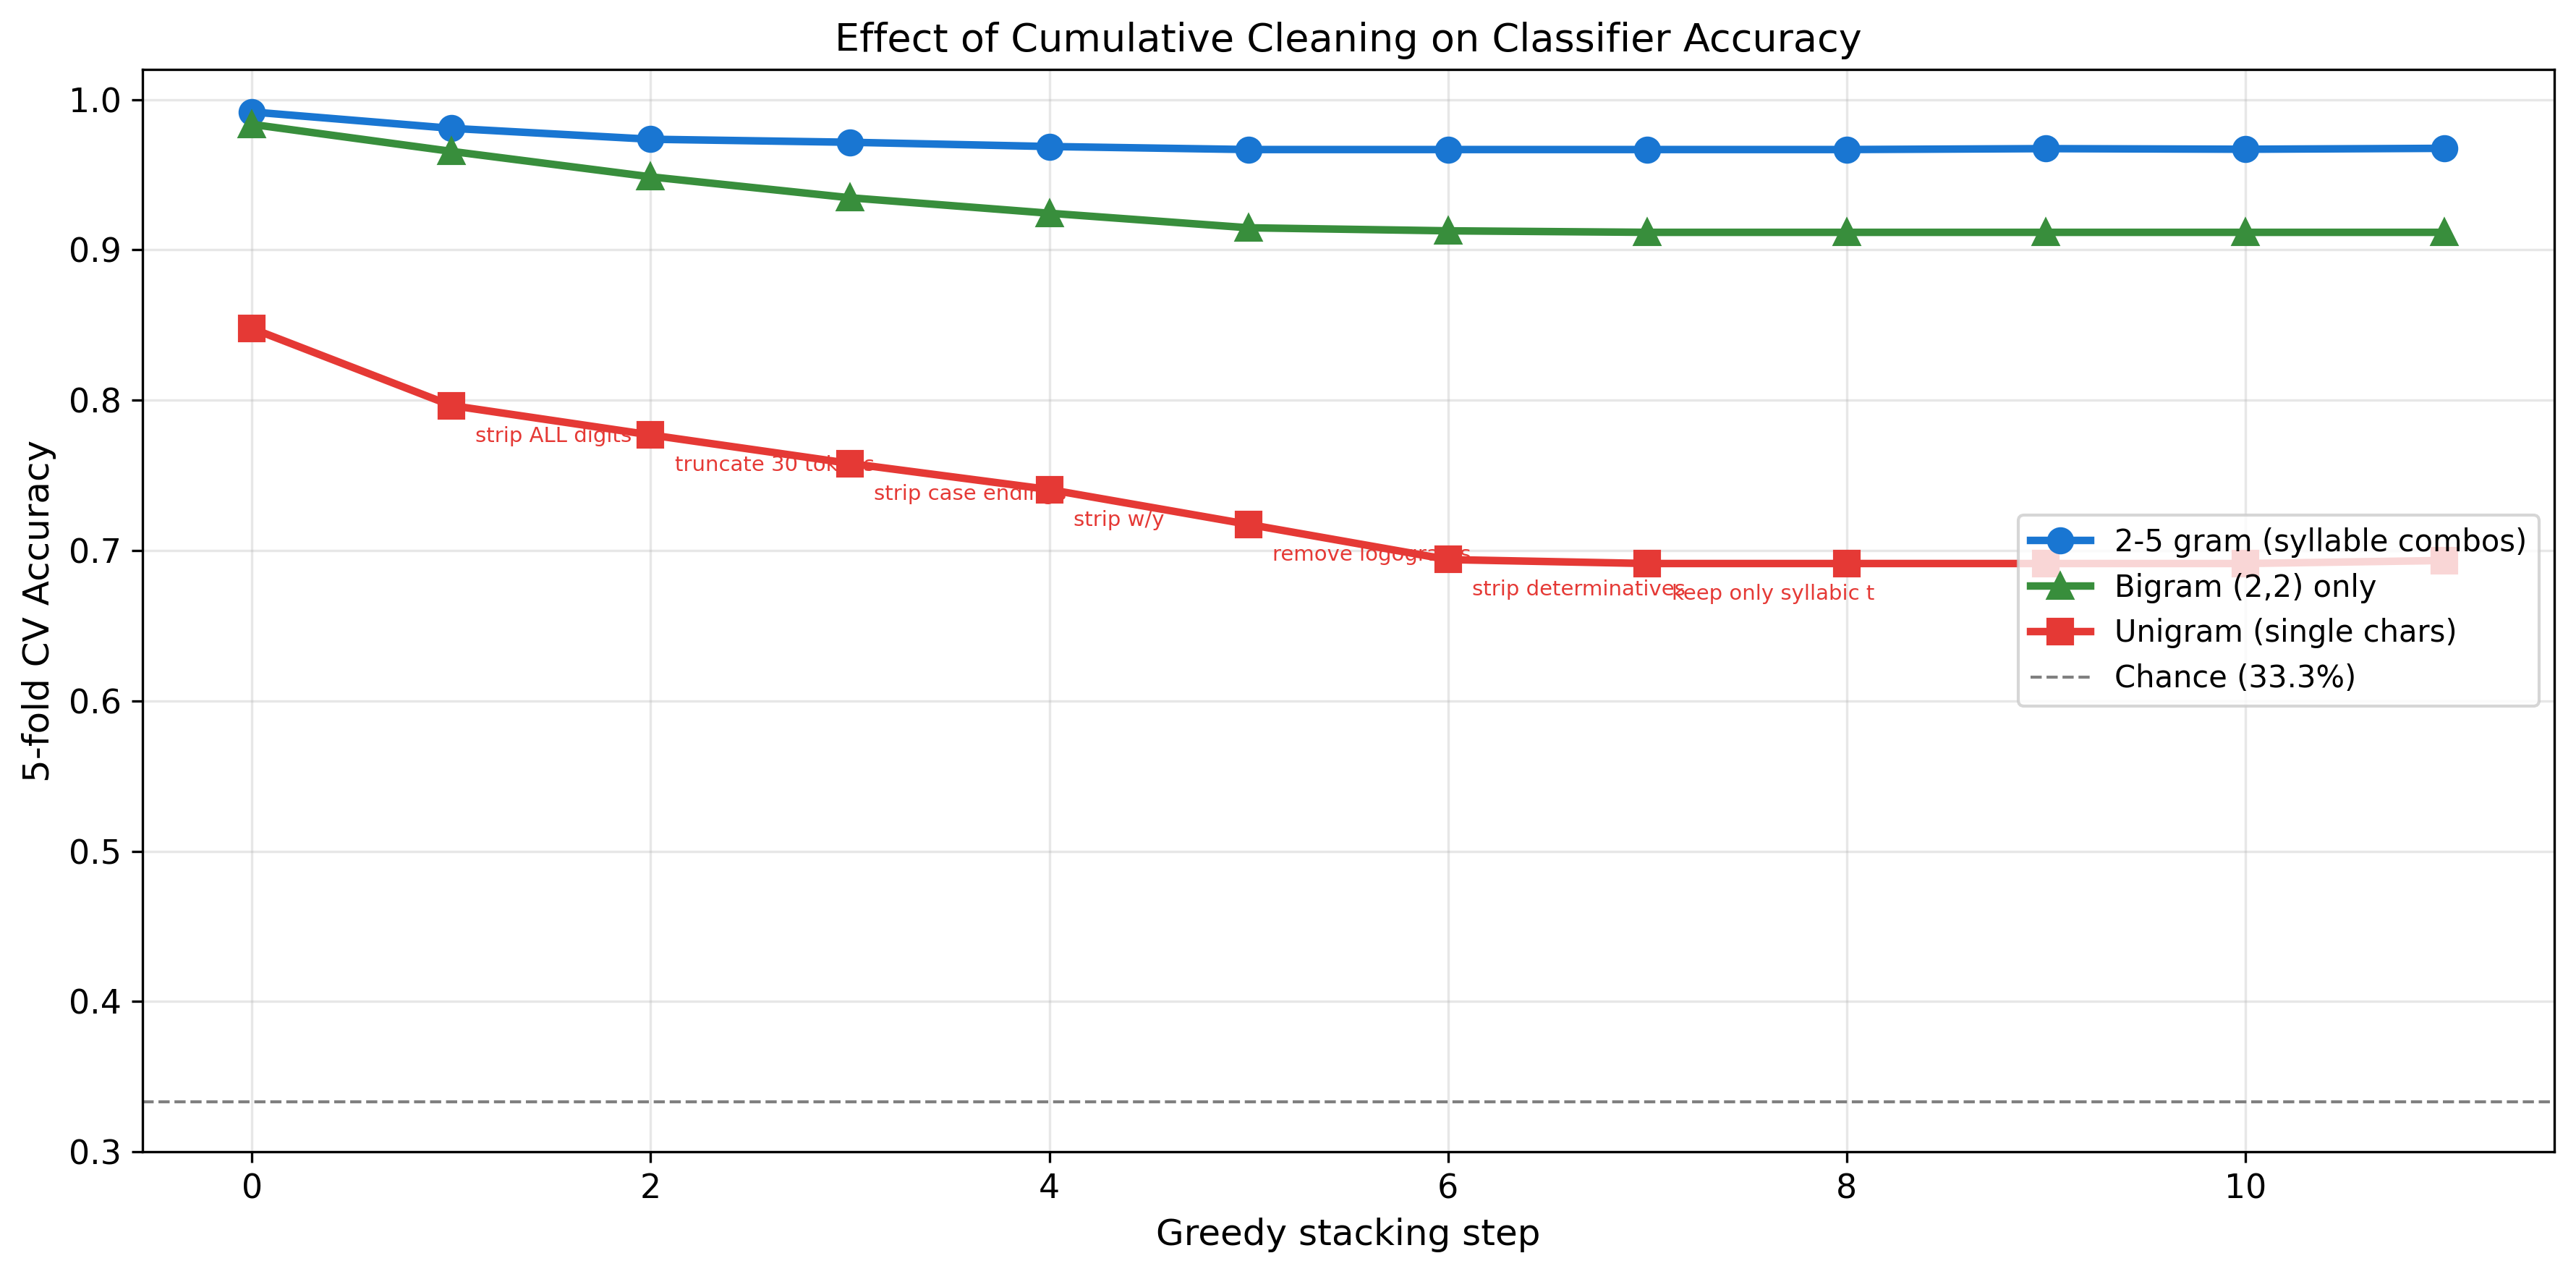

2-5 gram: baseline=0.992 → final=0.968 (Δ=-0.024)
Bigram:   baseline=0.983 → final=0.912 (Δ=-0.072)
Unigram:  baseline=0.848 → final=0.693 (Δ=-0.154)


In [34]:
# ── 10e. Combined comparison plot ───────────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 6))

# 2-5 gram line
steps_25 = [0] + [h[0] for h in hist_25]
accs_25  = [base_25] + [h[2] for h in hist_25]
labels_25 = ['tier0'] + [h[1] for h in hist_25]
ax.plot(steps_25, accs_25, 'o-', color='#1976D2', linewidth=2.5, markersize=8,
        label='2-5 gram (syllable combos)', zorder=3)

# bigram line
steps_22 = [0] + [h[0] for h in hist_22]
accs_22  = [base_22] + [h[2] for h in hist_22]
labels_22 = ['tier0'] + [h[1] for h in hist_22]
ax.plot(steps_22, accs_22, '^-', color='#388E3C', linewidth=2.5, markersize=8,
        label='Bigram (2,2) only', zorder=3)

# unigram line
steps_11 = [0] + [h[0] for h in hist_11]
accs_11  = [base_11] + [h[2] for h in hist_11]
labels_11 = ['tier0'] + [h[1] for h in hist_11]
ax.plot(steps_11, accs_11, 's-', color='#E53935', linewidth=2.5, markersize=8,
        label='Unigram (single chars)', zorder=3)

ax.axhline(y=1/3, color='gray', linestyle='--', linewidth=1, label='Chance (33.3%)')
ax.set_xlabel('Greedy stacking step')
ax.set_ylabel('5-fold CV Accuracy')
ax.set_title('Effect of Cumulative Cleaning on Classifier Accuracy')
ax.set_ylim(0.3, 1.02)
ax.legend(loc='center right')
ax.grid(alpha=0.3)

# Annotate the unigram curve with filter names
for i, (step, acc, lbl) in enumerate(zip(steps_11, accs_11, labels_11)):
    if i > 0 and i <= 7:  # only label meaningful drops
        short = lbl.split('(')[0].strip()[:20]
        ax.annotate(short, (step, acc), textcoords='offset points',
                    xytext=(8, -12), fontsize=7, color='#E53935', rotation=0)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'bias_cleaning_ablation.png', bbox_inches='tight', dpi=300)
plt.show()
print(f'2-5 gram: baseline={base_25:.3f} → final={hist_25[-1][2]:.3f} (Δ={hist_25[-1][2]-base_25:+.3f})')
print(f'Bigram:   baseline={base_22:.3f} → final={hist_22[-1][2]:.3f} (Δ={hist_22[-1][2]-base_22:+.3f})')
print(f'Unigram:  baseline={base_11:.3f} → final={hist_11[-1][2]:.3f} (Δ={hist_11[-1][2]-base_11:+.3f})')


## 11. Dimensionality Reduction: TF-IDF Period Clusters

Reduce char n-gram TF-IDF features to 2D (UMAP if available, t-SNE otherwise) and visualise
whether the three periods form separable clusters — one plot per n-gram range.
All texts use the tier-0 baseline cleaning.

UMAP not found — falling back to t-SNE (with TruncatedSVD pre-reduction)


Unigrams (1,1): 41 features — reducing to 2D with tSNE...


Bigrams (2,2): 533 features — reducing to 2D with tSNE...


2-5 grams (2,5): 10000 features — reducing to 2D with tSNE...


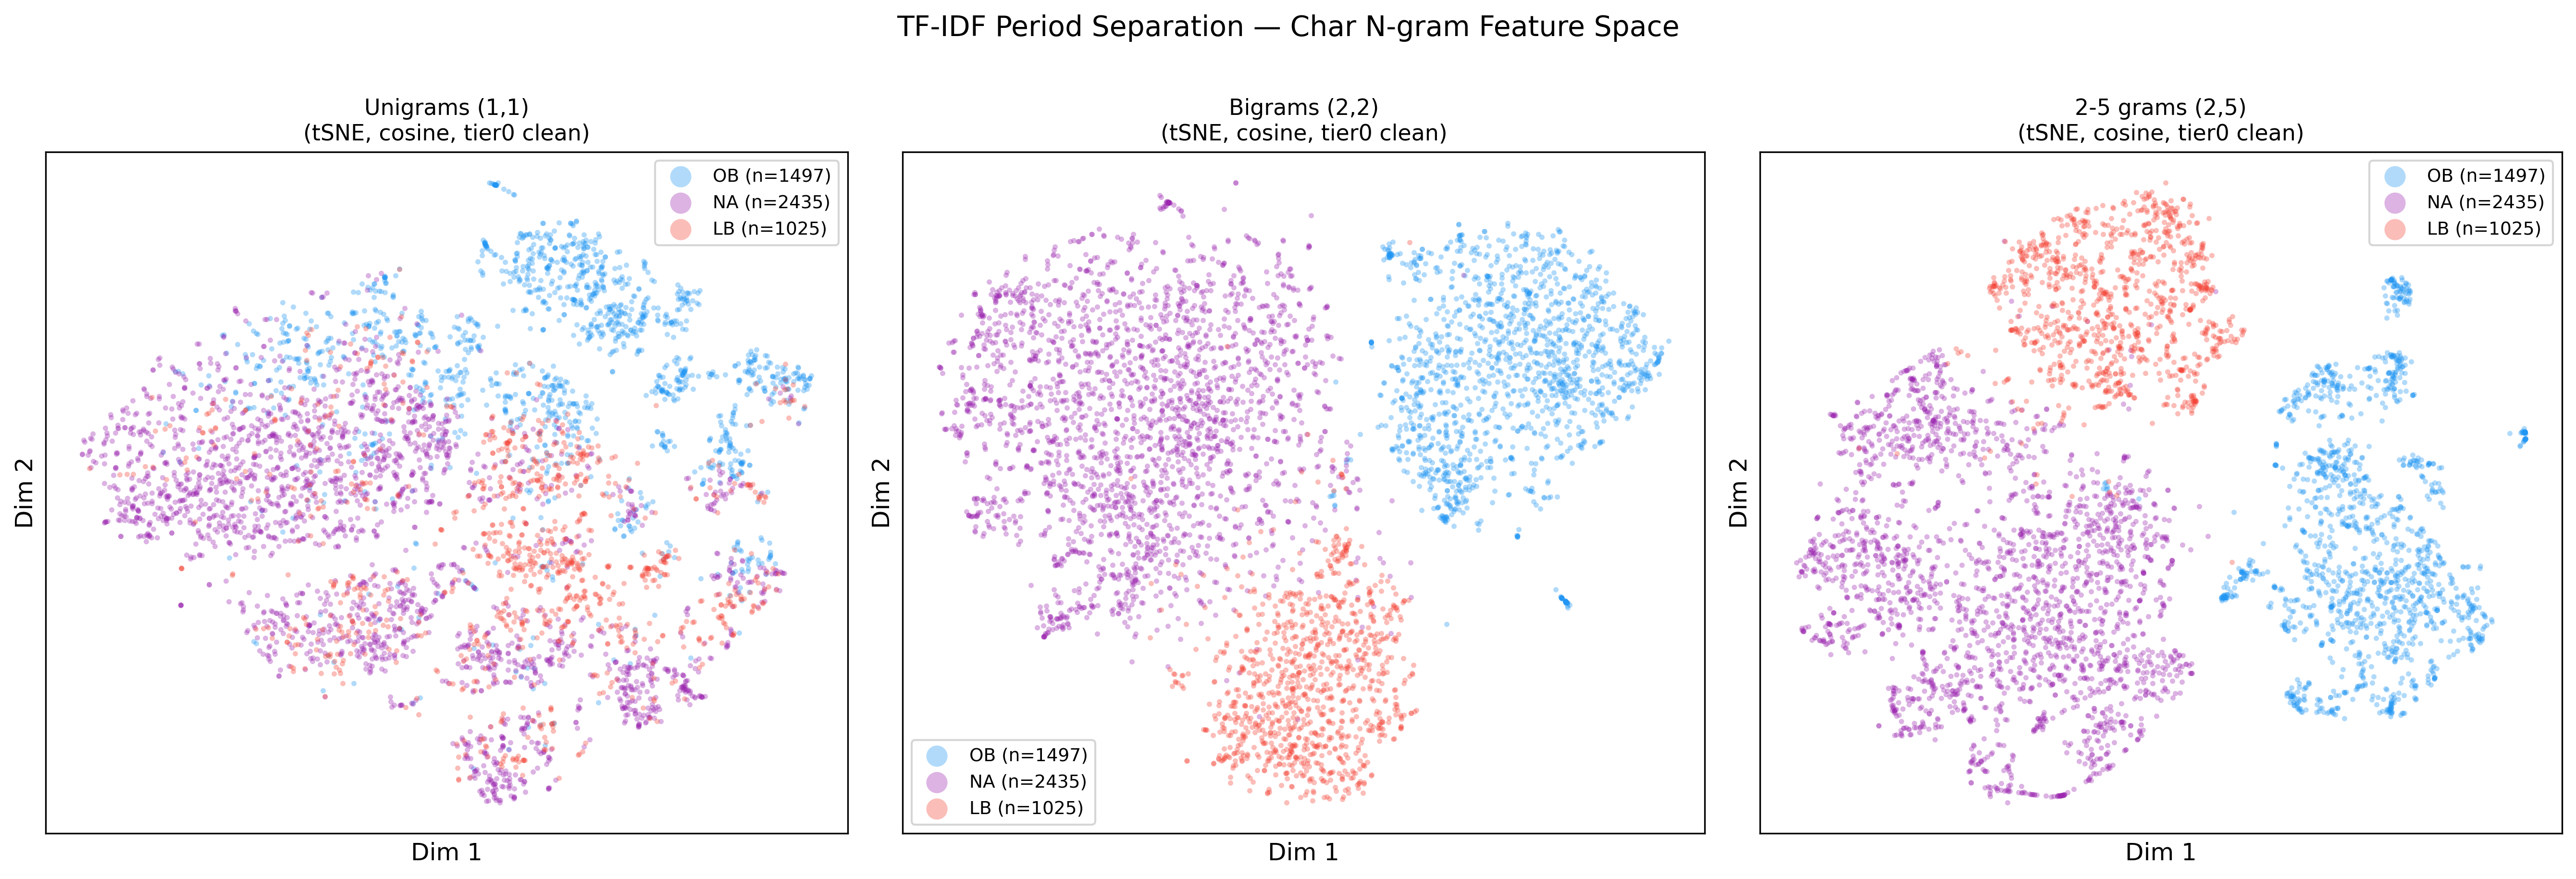

Saved bias_dim_reduction.png


In [35]:
# ── 11. TF-IDF dimensionality reduction: UMAP / t-SNE ───────────────────────
import warnings
warnings.filterwarnings('ignore')

try:
    import umap as umap_lib
    DIM_METHOD = 'UMAP'
    print('UMAP available — using UMAP')
except ImportError:
    DIM_METHOD = 'tSNE'
    print('UMAP not found — falling back to t-SNE (with TruncatedSVD pre-reduction)')

from sklearn.manifold import TSNE
from sklearn.decomposition import TruncatedSVD

configs = [
    ('Unigrams (1,1)',   (1, 1)),
    ('Bigrams (2,2)',    (2, 2)),
    ('2-5 grams (2,5)', (2, 5)),
]

base_texts  = df['full_text'].apply(clean_tier0)
period_col  = df['period'].values

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (label, ngram_range) in zip(axes, configs):
    # ── Build TF-IDF ────────────────────────────────────────────────────────
    vec = TfidfVectorizer(analyzer='char_wb', ngram_range=ngram_range,
                          max_features=10_000, sublinear_tf=True)
    X_sparse = vec.fit_transform(base_texts)
    print(f'{label}: {X_sparse.shape[1]} features — reducing to 2D with {DIM_METHOD}...')

    # ── Dim reduction ───────────────────────────────────────────────────────
    if DIM_METHOD == 'UMAP':
        reducer = umap_lib.UMAP(n_components=2, random_state=42,
                                n_neighbors=15, min_dist=0.1, metric='cosine')
        X_2d = reducer.fit_transform(X_sparse)
    else:
        # TruncatedSVD first (sparse-friendly PCA), then t-SNE
        n_svd = min(50, X_sparse.shape[1] - 1)
        X_svd = TruncatedSVD(n_components=n_svd, random_state=42).fit_transform(X_sparse)
        X_2d  = TSNE(n_components=2, random_state=42, perplexity=40,
                     n_iter=500, metric='euclidean').fit_transform(X_svd)

    # ── Scatter plot ────────────────────────────────────────────────────────
    for period in PERIODS:
        mask = period_col == period
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=PERIOD_COLORS[period], label=f'{SHORT[period]} (n={mask.sum()})',
                   alpha=0.35, s=7, linewidths=0, rasterized=True)

    ax.set_title(f'{label}\n({DIM_METHOD}, cosine, tier0 clean)', fontsize=11)
    ax.set_xlabel('Dim 1')
    ax.set_ylabel('Dim 2')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    ax.legend(markerscale=4, fontsize=9, loc='best', framealpha=0.8)

fig.suptitle('TF-IDF Period Separation — Char N-gram Feature Space', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'bias_dim_reduction.png', bbox_inches='tight', dpi=200)
plt.show()
print('Saved bias_dim_reduction.png')


## 12. In-Text Entity Bias: Deity Names & Geographic Names

**Motivated by Chunrong & Nathan's correspondence (Jan 2026):**
> *'Possible biases: Geographical names, deity name, perhaps sometimes also personal names'* — Chunrong Ni
>
> *'Texts from Babylon/Mari ► 2nd millennium; from Nineveh/Assur ► 9–7 cent.; from Babylon/Uruk ► 6–4 cent.'* — Nathan Wasserman

Unlike section 2 (metadata leaks), this checks whether **in-text mentions** of known Mesopotamian deities and cities
are period-discriminative — i.e., whether the classifier could be learning 'which gods/cities appear' rather than genuine linguistic features.

Entity mention rates (% of texts per period):
period                Old Babylonian  Neo-Assyrian  Late Babylonian
d-EN-ZU                         16.4           0.2              0.0
d-UTU                           19.2           8.7             25.4
d-da-gan                        13.0           0.0              0.0
d-IM                             0.2           4.8              0.6
d-AMAR-UTU                       6.0          25.1             34.5
d-AG                             0.0          20.7             81.7
d-EN                            19.0          13.2             61.0
d-na-na-a                        0.3           1.2             23.4
d-AN-ŠAR2                        0.0           0.0              0.0
d-INNIN                          0.0           0.1              4.1
Babylon (KA2-DINGIR)             6.3           3.6              0.1
Mari                            13.6           1.3              0.3
Sippar                           0.0           0.0              0.0
Ni

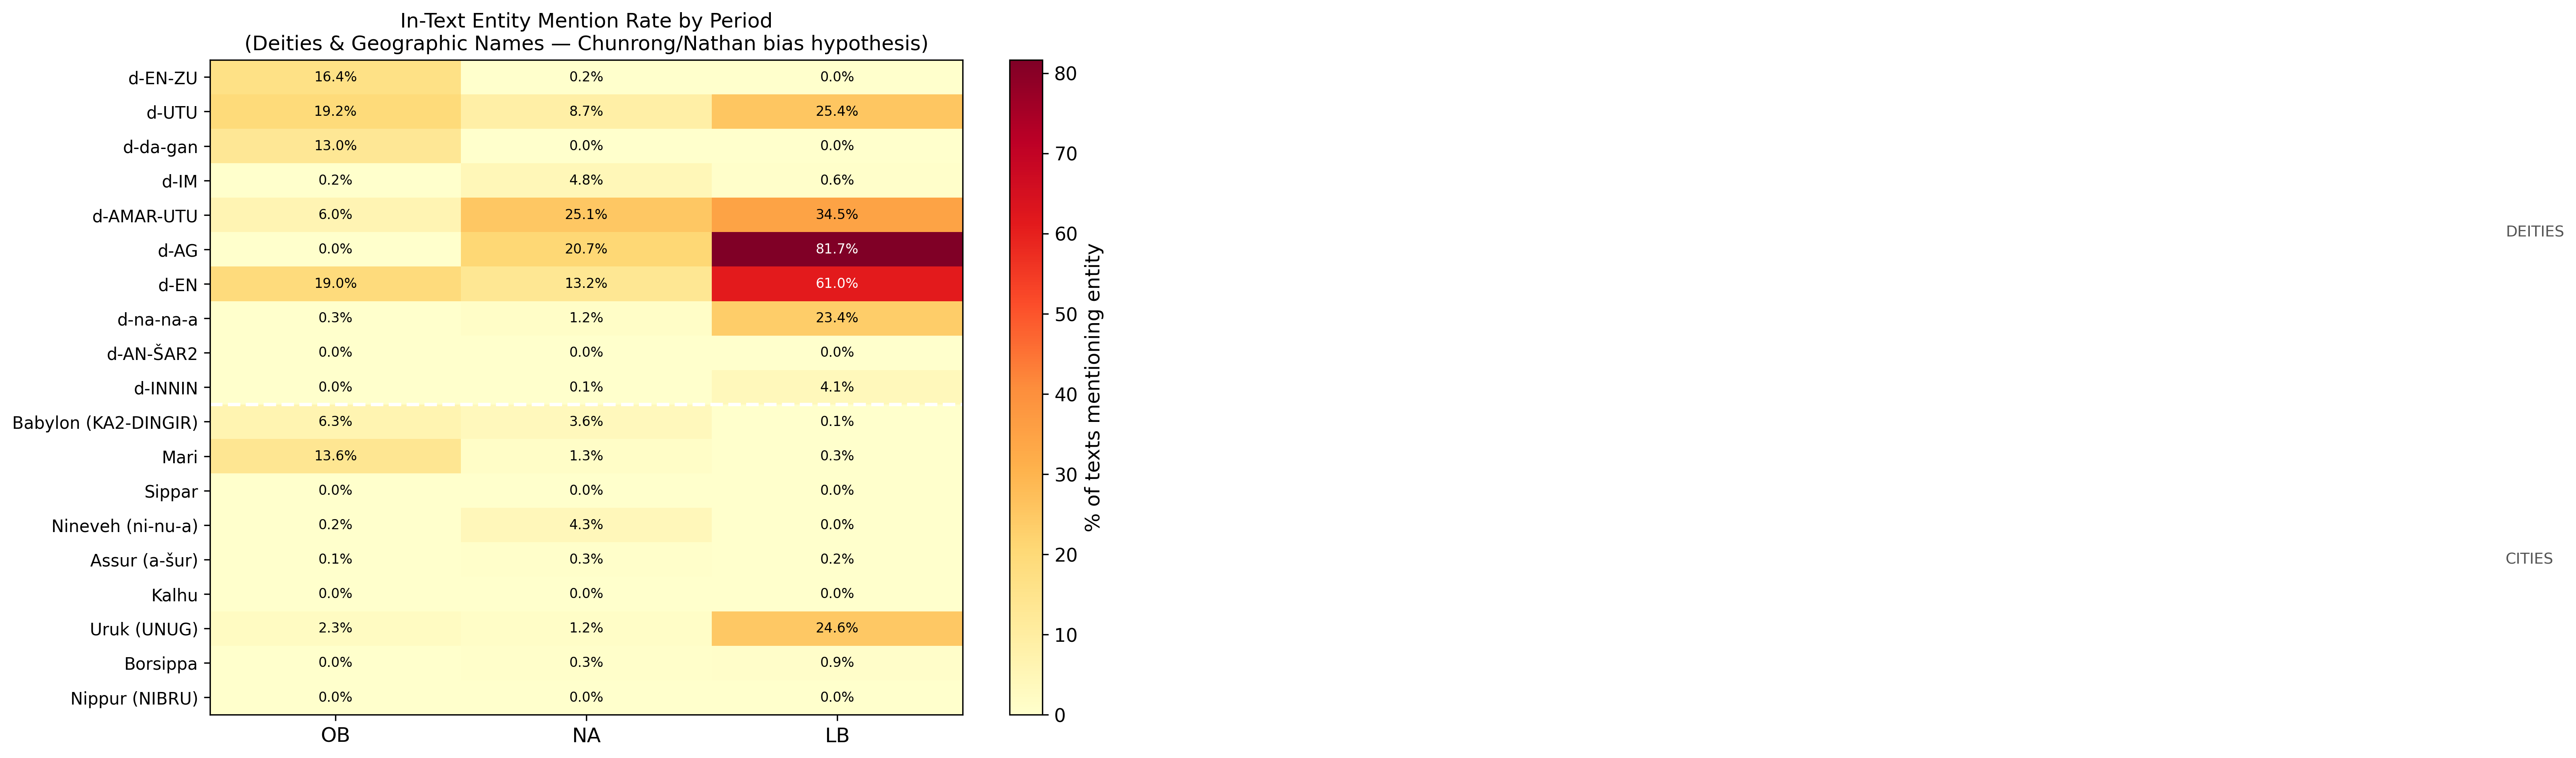


Logistic regression on entity features only: 0.724 ± 0.040
(Chance = 0.333, Full TF-IDF = 0.992)

Conclusion: Entity mentions ARE a meaningful bias source — classifier can exploit them beyond chance.


In [36]:
# ── 12. In-text entity bias: deities & geographic names ─────────────────────
import re

# ── Entity lists (transliteration conventions: hyphens, subscript digits) ───
DEITY_PATTERNS = {
    # OB-associated
    'd-EN-ZU':     r'\bd-EN-ZU\b',          # Nanna/Sin (moon god, OB)
    'd-UTU':       r'\bd-UTU\b',             # Shamash (sun god, OB-heavy)
    'd-da-gan':    r'\bd-da-gan\b',           # Dagan (Mari/OB)
    'd-IM':        r'\bd-IM\b',               # Adad/storm god (OB)
    # LB-associated
    'd-AMAR-UTU':  r'\bd-AMAR-UTU\b',        # Marduk (LB dominant)
    'd-AG':        r'\bd-AG\b',               # Nabu (LB)
    'd-EN':        r'\bd-EN\b',               # Bel/Marduk (LB)
    'd-na-na-a':   r'\bd-na-na-a\b',          # Nanaya (LB)
    # NA-associated
    'd-AN-ŠAR2':   r'\bd-AN-ŠAR2\b',         # Assur (Assyrian national deity)
    'd-INNIN':     r'\bd-INNIN\b',            # Ishtar/Inanna (NA)
}

GEO_PATTERNS = {
    # OB cities
    'Babylon (KA2-DINGIR)': r'KA2-DINGIR',
    'Mari':                 r'\bma-ri\b|\bMA-RI\b',
    'Sippar':               r'\bsi-ip-par\b|\bSIPPAR\b|\bsi-pa-ar\b',
    # NA cities
    'Nineveh (ni-nu-a)':    r'\bni-nu-a\b|\bNINA\b|\bNINUA\b',
    'Assur (a-šur)':        r'\ba-šur\b|\ba-AŠ2\b',
    'Kalhu':                r'\bkal-hu\b|\bKAL-hu\b',
    # LB cities
    'Uruk (UNUG)':          r'\bUNUG\b|\bu2-nu-uq\b',
    'Borsippa':             r'\bbar-sip\b|\bBOR-SIP\b',
    'Nippur (NIBRU)':       r'\bNIBRU\b|\bni-ib-ru\b',
}

ALL_ENTITIES = {**DEITY_PATTERNS, **GEO_PATTERNS}

# ── Compute mention rate (texts that mention entity at least once) ───────────
for name, pat in ALL_ENTITIES.items():
    df[f'ent_{name}'] = df['full_text'].str.contains(pat, regex=True, na=False).astype(float)

ent_cols = [f'ent_{n}' for n in ALL_ENTITIES]
entity_rates = df.groupby('period')[ent_cols].mean() * 100  # → % of texts
entity_rates.columns = list(ALL_ENTITIES.keys())
entity_rates = entity_rates.loc[PERIODS]  # row order

print('Entity mention rates (% of texts per period):')
print(entity_rates.T.round(1).to_string())

# ── Heatmap ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
import numpy as np
data = entity_rates.values.T  # shape (entities, periods)
im = ax.imshow(data, aspect='auto', cmap='YlOrRd')
plt.colorbar(im, ax=ax, label='% of texts mentioning entity')
ax.set_xticks(range(len(PERIODS)))
ax.set_xticklabels([SHORT[p] for p in PERIODS], fontsize=12)
ax.set_yticks(range(len(ALL_ENTITIES)))
ax.set_yticklabels(list(ALL_ENTITIES.keys()), fontsize=10)
ax.axhline(len(DEITY_PATTERNS) - 0.5, color='white', linewidth=2, linestyle='--')
ax.text(len(PERIODS) + 0.05, len(DEITY_PATTERNS)/2 - 0.5, 'DEITIES',
        va='center', fontsize=9, color='#555', transform=ax.get_yaxis_transform())
ax.text(len(PERIODS) + 0.05, len(DEITY_PATTERNS) + len(GEO_PATTERNS)/2 - 0.5, 'CITIES',
        va='center', fontsize=9, color='#555', transform=ax.get_yaxis_transform())
# annotate cells
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        ax.text(j, i, f'{data[i,j]:.1f}%', ha='center', va='center',
                fontsize=8, color='black' if data[i,j] < data.max()*0.6 else 'white')
ax.set_title('In-Text Entity Mention Rate by Period\n(Deities & Geographic Names — Chunrong/Nathan bias hypothesis)',
             fontsize=12)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'bias_entity_mentions.png', bbox_inches='tight', dpi=200)
plt.show()

# ── How well can entity features alone classify period? ──────────────────────
from sklearn.linear_model import LogisticRegression as LR
from sklearn.model_selection import cross_val_score

X_ent = df[ent_cols].values
scores = cross_val_score(LR(max_iter=500), X_ent, y_abl, cv=5)
print(f'\nLogistic regression on entity features only: {scores.mean():.3f} ± {scores.std():.3f}')
print(f'(Chance = {1/3:.3f}, Full TF-IDF = 0.992)')
print('\nConclusion: Entity mentions', 'ARE' if scores.mean() > 0.5 else 'are NOT',
      'a meaningful bias source — classifier can exploit them beyond chance.')


## 13. PLS-DA: Partial Least Squares Discriminant Analysis

PLS-DA projects TF-IDF features into latent components that maximally separate the period classes.
Unlike t-SNE (visualisation only), PLS gives us **loadings** and **VIP scores** (Variable Importance in Projection, Wold 1993) —
the contribution of each character n-gram to period discrimination.

We run this on the same evaluation-set data (4,957 texts) with tier0 cleaning, for:
- **Unigrams (1,1)** — single characters
- **Bigrams (2,2)** — character pairs

This mirrors the analysis done on the finetune dataset in `bias_analysis_finetune.ipynb`.

In [37]:
# ── 13a. PLS-DA fit + VIP scores ────────────────────────────────────────────

from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import label_binarize
from sklearn.feature_extraction.text import TfidfVectorizer

# Use tier0-cleaned texts (same as ablation experiments)
base_texts_pls = df['full_text'].apply(clean_tier0)

n_components = 2  # 2 latent components for 3-class problem (max useful = n_classes - 1)

pls_results = {}

for label, ngram_range in [('Unigrams (1,1)', (1, 1)), ('Bigrams (2,2)', (2, 2))]:
    print(f'\n{"="*70}')
    print(f'PLS-DA — {label}')
    print(f'{"="*70}')

    vec = TfidfVectorizer(analyzer='char_wb', ngram_range=ngram_range,
                          max_features=10_000, sublinear_tf=True)
    X = vec.fit_transform(base_texts_pls).toarray()
    feature_names = vec.get_feature_names_out()

    # One-hot encode y for PLS regression (PLS-DA approach)
    Y_onehot = label_binarize(df['period'], classes=['Old Babylonian', 'Neo-Assyrian', 'Late Babylonian']).astype(float)

    pls = PLSRegression(n_components=n_components, scale=True)
    pls.fit(X, Y_onehot)

    # Scores (sample projections onto latent components)
    X_scores = pls.transform(X)

    # ── VIP scores ──────────────────────────────────────────────────────────
    # VIP = Variable Importance in Projection (Wold 1993)
    W = pls.x_weights_                    # (p, n_components)
    T = pls.x_scores_                     # (n, n_components)
    Q = pls.y_loadings_                   # (q, n_components)
    p_feat = X.shape[1]

    # Fraction of Y-variance explained by each component
    SS = np.array([np.sum((T[:, a:a+1] @ Q[:, a:a+1].T)**2) for a in range(n_components)])
    SS_total = np.sum(SS)

    vip = np.sqrt(p_feat * np.sum(SS[np.newaxis, :] * (W ** 2), axis=1) / SS_total)

    pls_results[label] = {
        'pls': pls, 'X_scores': X_scores, 'vip': vip,
        'feature_names': feature_names, 'W': W,
    }

    # Print top VIP features
    top_idx = np.argsort(vip)[::-1][:25]
    print(f'\nTop 25 features by VIP score:')
    print(f'  {"Rank":<5s}  {"Feature":<20s}  {"VIP":>6s}')
    print(f'  {"-"*35}')
    for rank, idx in enumerate(top_idx, 1):
        print(f'  {rank:<5d}  {repr(feature_names[idx]):<20s}  {vip[idx]:>6.3f}')

    print(f'\nFeatures with VIP > 1.0: {np.sum(vip > 1.0)} / {len(vip)}')



PLS-DA — Unigrams (1,1)



Top 25 features by VIP score:
  Rank   Feature                  VIP
  -----------------------------------
  1      'g'                    2.195
  2      'w'                    2.142
  3      'm'                    1.969
  4      '4'                    1.619
  5      'l'                    1.512
  6      'n'                    1.391
  7      ' '                    1.333
  8      "'"                    1.331
  9      'a'                    1.305
  10     'u'                    1.264
  11     '3'                    1.166
  12     'q'                    1.150
  13     '-'                    1.148
  14     'h'                    1.044
  15     'd'                    0.919
  16     't'                    0.908
  17     'ṭ'                    0.844
  18     '1'                    0.828
  19     'e'                    0.824
  20     'i'                    0.759
  21     '7'                    0.746
  22     'z'                    0.740
  23     'ṣ'                    0.684
  24     'š'       


Top 25 features by VIP score:
  Rank   Feature                  VIP
  -----------------------------------
  1      'm '                   4.283
  2      'ug'                   3.719
  3      'im'                   3.448
  4      'i2'                   3.378
  5      'a2'                   3.244
  6      'l '                   3.235
  7      'ga'                   3.220
  8      'al'                   3.151
  9      ' q'                   3.102
  10     'ag'                   3.048
  11     'um'                   3.007
  12     '4 '                   2.937
  13     'u4'                   2.873
  14     'lu'                   2.828
  15     'am'                   2.743
  16     'še'                   2.697
  17     'in'                   2.693
  18     'm-'                   2.625
  19     ' l'                   2.611
  20     'qi'                   2.559
  21     'wa'                   2.505
  22     'n '                   2.504
  23     'g-'                   2.450
  24     'uh'      

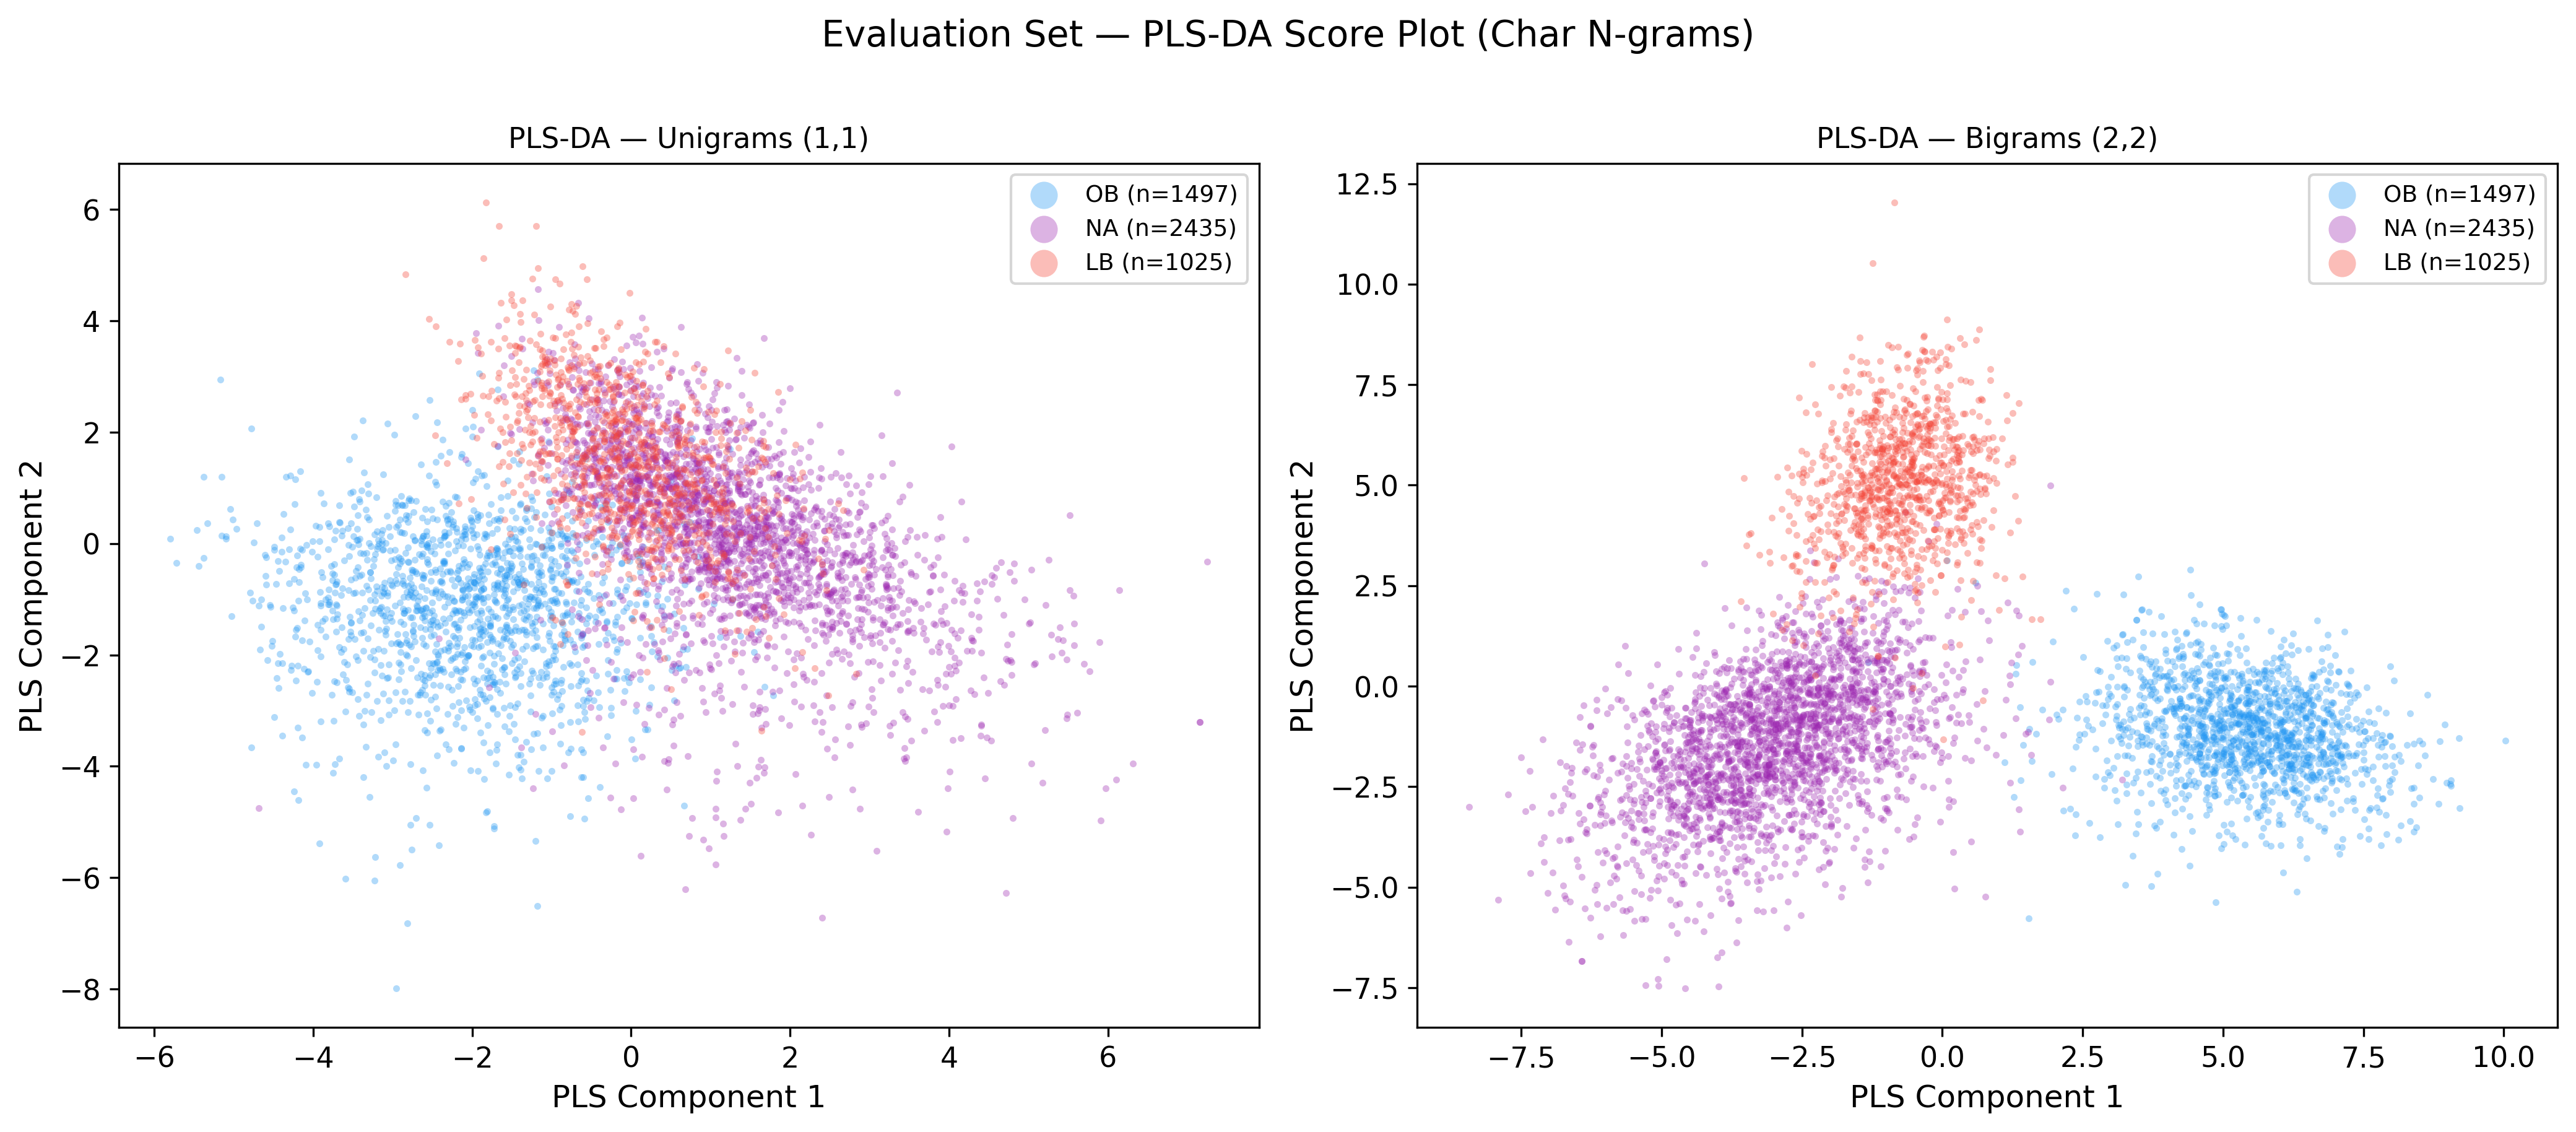

Saved eval_pls_scores.png


In [38]:
# ── 13b. PLS-DA score plots (samples in latent space) ───────────────────────

configs = [('Unigrams (1,1)', (1, 1)), ('Bigrams (2,2)', (2, 2))]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (label, _) in zip(axes, configs):
    r = pls_results[label]
    X_sc = r['X_scores']

    for period in PERIODS:
        mask = df['period'].values == period
        if mask.sum() == 0:
            continue
        ax.scatter(X_sc[mask, 0], X_sc[mask, 1],
                   c=PERIOD_COLORS[period], label=f'{SHORT[period]} (n={mask.sum()})',
                   alpha=0.35, s=7, linewidths=0, rasterized=True)

    ax.set_title(f'PLS-DA — {label}', fontsize=11)
    ax.set_xlabel('PLS Component 1')
    ax.set_ylabel('PLS Component 2')
    ax.legend(markerscale=4, fontsize=9, loc='best', framealpha=0.8)

fig.suptitle('Evaluation Set — PLS-DA Score Plot (Char N-grams)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'eval_pls_scores.png', bbox_inches='tight', dpi=200)
plt.show()
print('Saved eval_pls_scores.png')


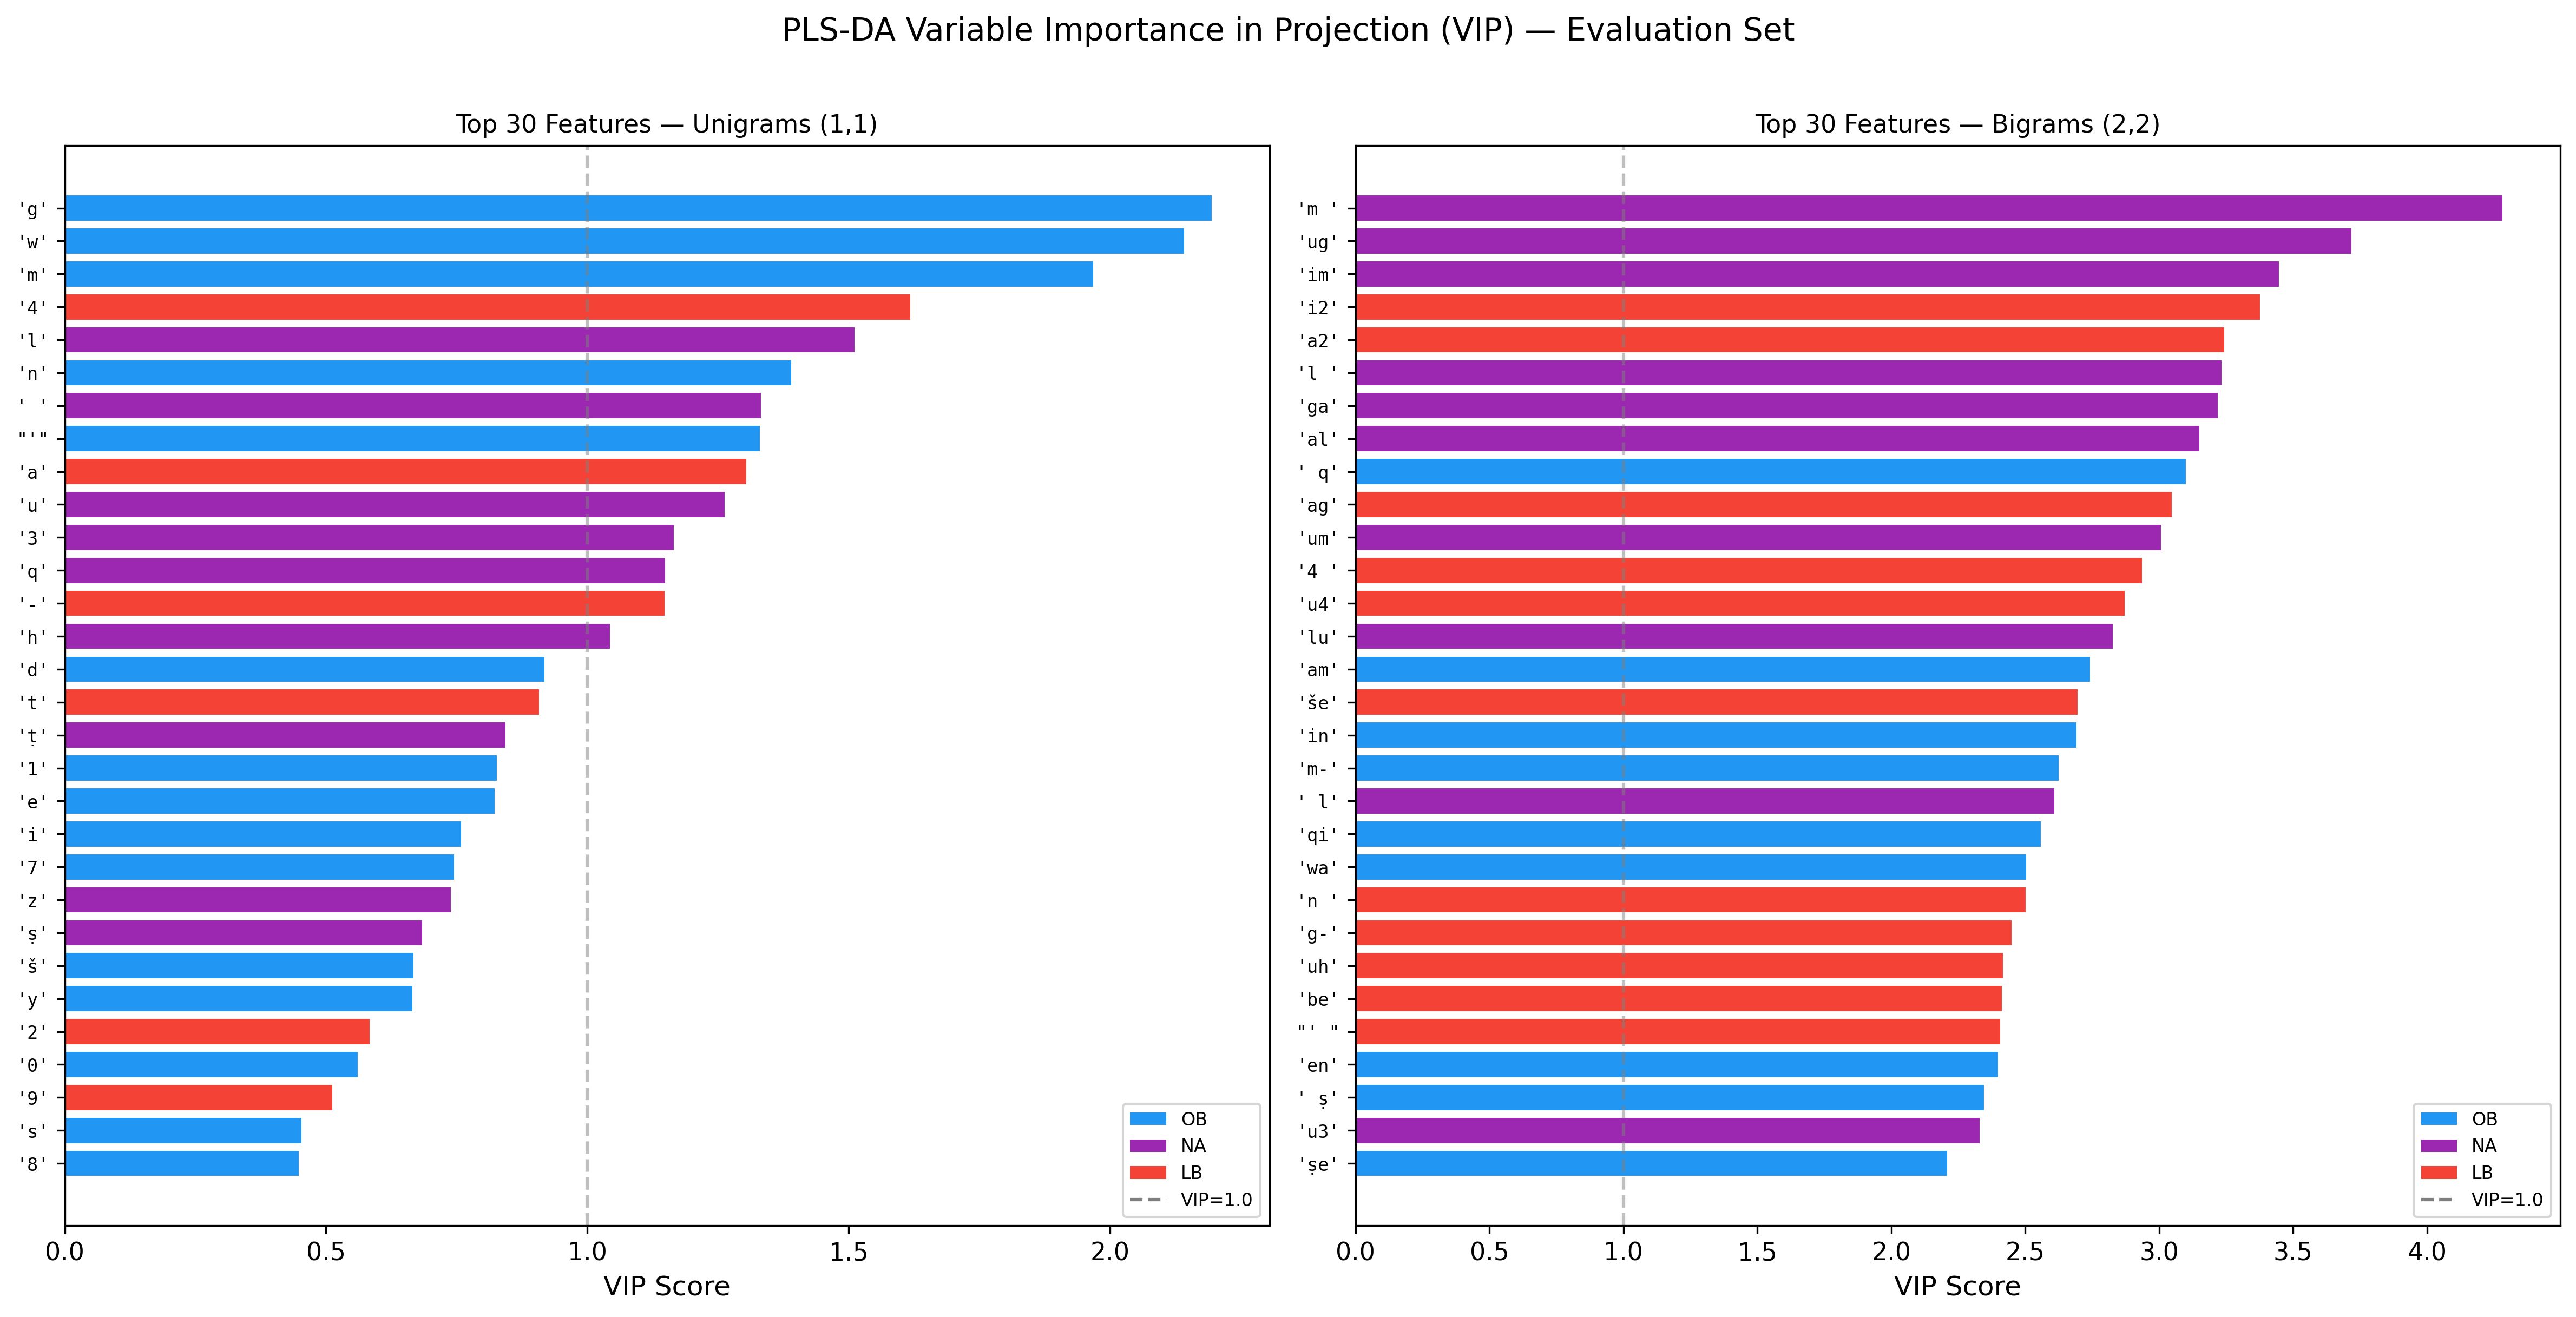

Saved eval_pls_vip.png


In [39]:
# ── 13c. VIP bar charts — top features per n-gram mode ──────────────────────

import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, (label, _) in zip(axes, configs):
    r = pls_results[label]
    vip = r['vip']
    fnames = r['feature_names']
    W = r['W']
    pls_obj = r['pls']
    Q = pls_obj.y_loadings_  # (3, 2) = classes × components

    top_n = 30
    top_idx = np.argsort(vip)[::-1][:top_n]

    # Color each bar by the period it most discriminates
    CLASS_ORDER = ['Old Babylonian', 'Neo-Assyrian', 'Late Babylonian']
    bar_colors = []
    for idx in top_idx:
        class_scores = np.abs(W[idx, :] @ Q.T)  # (3,) contribution to each class
        best_class = CLASS_ORDER[np.argmax(class_scores)]
        bar_colors.append(PERIOD_COLORS[best_class])

    y_pos = np.arange(top_n)
    ax.barh(y_pos, vip[top_idx][::-1],
            color=[bar_colors[i] for i in range(top_n)][::-1],
            edgecolor='white', linewidth=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([repr(fnames[i]) for i in top_idx][::-1], fontsize=8, fontfamily='monospace')
    ax.set_xlabel('VIP Score')
    ax.set_title(f'Top {top_n} Features — {label}', fontsize=11)
    ax.axvline(x=1.0, color='gray', linestyle='--', alpha=0.5)

    legend_elements = (
        [mpatches.Patch(facecolor=PERIOD_COLORS[p], label=SHORT[p]) for p in PERIODS]
        + [plt.Line2D([0], [0], color='gray', linestyle='--', label='VIP=1.0')]
    )
    ax.legend(handles=legend_elements, fontsize=8, loc='lower right')

fig.suptitle('PLS-DA Variable Importance in Projection (VIP) — Evaluation Set', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'eval_pls_vip.png', bbox_inches='tight', dpi=200)
plt.show()
print('Saved eval_pls_vip.png')


In [40]:
# ── 13d. Cross-dataset VIP comparison: eval set vs finetune ─────────────────

# Finetune top VIP features (from bias_analysis_finetune.ipynb, printed for reference)
# Unigrams: '6' (LB), 'í' (OB), '(' ')' (OB), 'ú' (OB), 'w' (OB), 'q' (LB)
# Bigrams:  '60'/' 6' (LB), 'qa'/'qí' (LB), 'un' (OB), 'bí'/'lí' (OB), '(d'/'d)' (NA)

print('='*80)
print('CROSS-DATASET VIP COMPARISON: Evaluation Set vs Finetune')
print('='*80)

for label in ['Unigrams (1,1)', 'Bigrams (2,2)']:
    r = pls_results[label]
    vip = r['vip']
    fnames = r['feature_names']
    top_idx = np.argsort(vip)[::-1][:15]
    CLASS_ORDER = ['Old Babylonian', 'Neo-Assyrian', 'Late Babylonian']
    W = r['W']
    Q = r['pls'].y_loadings_

    print(f'\n{label}')
    print(f'  {"Rank":<5s}  {"Feature":<20s}  {"VIP":>6s}  {"Period"}')
    print(f'  {"-"*50}')
    for rank, idx in enumerate(top_idx, 1):
        class_scores = np.abs(W[idx, :] @ Q.T)
        best_class = CLASS_ORDER[np.argmax(class_scores)]
        best_short = SHORT[best_class]
        print(f'  {rank:<5d}  {repr(fnames[idx]):<20s}  {vip[idx]:>6.3f}  {best_short}')

print()
print('Finetune top features (reference):')
print('  Unigrams: 6 (LB, VIP=3.13), í (OB, 2.04), ( ) (OB, 2.01), ú (OB, 1.93), w (OB, 1.41), q (LB, 1.51)')
print('  Bigrams:  60/ 6 (LB, VIP=7.3), qa/qí (LB, 4.9/3.9), un (OB, 4.7), bí/lí (OB, 4.0/3.3)')


CROSS-DATASET VIP COMPARISON: Evaluation Set vs Finetune

Unigrams (1,1)
  Rank   Feature                  VIP  Period
  --------------------------------------------------
  1      'g'                    2.195  OB
  2      'w'                    2.142  OB
  3      'm'                    1.969  OB
  4      '4'                    1.619  LB
  5      'l'                    1.512  NA
  6      'n'                    1.391  OB
  7      ' '                    1.333  NA
  8      "'"                    1.331  OB
  9      'a'                    1.305  LB
  10     'u'                    1.264  NA
  11     '3'                    1.166  NA
  12     'q'                    1.150  NA
  13     '-'                    1.148  LB
  14     'h'                    1.044  NA
  15     'd'                    0.919  OB

Bigrams (2,2)
  Rank   Feature                  VIP  Period
  --------------------------------------------------
  1      'm '                   4.283  NA
  2      'ug'                   3.719  NA
